# Multilingual IT Ticket Routing — Master Project

**Team:**

- Aditi Jha
- Beakal Zekaryas
- Saman Tavasoli

We combined our nine project notebooks here so the team can follow each stage in one place. The sections include our code, charts, and saved results. We have edited the explanations and comments for readability. The results are from earlier runs; we have not rerun the project in this combined notebook.

## Contents

1. [Project goal and dataset](#section-1)
2. [AWS setup and data splits](#section-2)
3. [Original data archive](#section-3)
4. [EDA and charts](#section-4)
5. [Feature engineering and Feature Store](#section-5)
6. [Benchmark, model training, and evaluation](#section-6)
7. [Batch predictions](#section-7)
8. [Monitoring and CloudWatch](#section-8)
9. [Model Registry](#section-9)
10. [Automated pipeline and GitHub tests](#section-10)
11. [Results and limitations](#section-11)


## How to use this notebook

Read the sections in order to follow our work from data preparation to monitoring and automation. The results come from separate notebook sessions, so the cell numbers may restart between sections.

**Please do not click Run All.** Some cells upload files or start AWS jobs. The first code cell stops Run All, but individual cells can still run.

We have not run this combined notebook from beginning to end. Some setup steps and variable names repeat.

To run a specific stage, use the original notebook linked in that section. Keep the scripts, tests, settings, data, and reports in the project folder. They are still needed.

The embedded scripts and file templates keep their original contents so they match the saved versions used in our runs.

We updated three setup cells after reviewing the project and cleared their old outputs. The other saved results are from our earlier runs.


In [ ]:
raise RuntimeError("Review notebook: use the original notebooks to run each stage.")


<a id="section-1"></a>
## 1. Project goal and dataset

We built a model to help an IT service desk sort tickets into the right support queue. It reads each ticket's subject and body and predicts one of 10 queues. Our goal is to help support staff sort tickets, although we have not measured time or cost savings in a real service desk.

We used the cleaned master dataset prepared by Beakal. It contains **44,278 tickets**, **10 queues**, and **five languages**: English, German, Spanish, French, and Portuguese. We kept all 10 queues and all five languages.

| Split | Approximate share | Tickets | Purpose |
|---|---:|---:|---|
| Training | 40% | 17,710 | Train the model and build the text vocabulary |
| Validation | 10% | 4,428 | Compare features and choose model settings |
| Test | 10% | 4,428 | Evaluate the selected model |
| Simulated production | 40% | 17,712 | Run batch predictions and monitoring |

We selected the model using macro F1, which gives each queue equal weight in the final score. We also reported accuracy and weighted F1. We left answers and tags out of the model inputs to reduce the risk of giving the model information it would not have when a new ticket arrives. We kept the correct production queue labels separate until after prediction.


<a id="section-2"></a>
## 2. AWS setup and data splits

We set up our S3 bucket, recorded the dataset version, and divided the tickets into training, validation, test, and simulated production sets. We saved the production queue labels separately and checked that no ticket appeared in more than one split.

We also created an Athena table to query the data and checked the bucket's versioning, encryption, and public-access settings.

We used a SHA-256 hash to check that a dataset file matched its saved version. A hash is a value calculated from the file's contents.

**Original notebook:** [project_setup.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/000e8509e26d2f02b5cef266c83192be5cbc0023/project_setup.ipynb)

The cells below show our setup code and saved results.


In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import sys

PROJECT_ROOT = Path.cwd()
DATA_PATH = (
    PROJECT_ROOT
    / "Cleaned- Master Data set"
    / "multilingual_ticket_master_cleaned.csv"
)

print("Python:", sys.version.split()[0])
print("Project folder:", PROJECT_ROOT)
print("Master dataset found:", DATA_PATH.is_file())

for package in ["pandas", "numpy", "scikit-learn", "boto3", "sagemaker"]:
    try:
        print(f"{package}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package}: not installed")


Python: 3.12.14
Project folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops
Master dataset found: True
pandas: 2.3.3
numpy: 1.26.4
scikit-learn: 1.7.2
boto3: 1.43.56
sagemaker: not installed


In [2]:
import pandas as pd

master_df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset shape:", master_df.shape)

print("\nTickets per queue:")
print(master_df["queue"].value_counts())

print("\nTickets per language:")
print(master_df["language"].value_counts())

print("\nMissing queue labels:", master_df["queue"].isna().sum())

empty_text = (
    master_df["subject"].fillna("").str.strip().eq("")
    & master_df["body"].fillna("").str.strip().eq("")
)
print("Tickets with both subject and body empty:", empty_text.sum())


Dataset shape: (44278, 21)

Tickets per queue:
queue
Technical Support                  13095
Product Support                     8113
Customer Service                    6741
IT Support                          5237
Billing and Payments                4368
Returns and Exchanges               2204
Service Outages and Maintenance     1710
Sales and Pre-Sales                 1393
Human Resources                      802
General Inquiry                      615
Name: count, dtype: int64

Tickets per language:
language
en    25138
de    17379
es      812
fr      476
pt      473
Name: count, dtype: int64

Missing queue labels: 0
Tickets with both subject and body empty: 0


In [4]:
import boto3

aws_session = boto3.Session()
AWS_REGION = aws_session.region_name or "us-east-1"

sts_client = aws_session.client("sts", region_name=AWS_REGION)
identity = sts_client.get_caller_identity()

AWS_ACCOUNT_ID = identity["Account"]

print("Region:", AWS_REGION)
print("Current identity:", identity["Arn"])


Region: us-east-1
Current identity: arn:aws:sts::390568313988:assumed-role/LabRole/SageMaker


In [5]:
s3_client = aws_session.client("s3", region_name=AWS_REGION)

response = s3_client.list_buckets()
bucket_names = [bucket["Name"] for bucket in response["Buckets"]]

print("Existing S3 buckets:")
for name in bucket_names:
    print("-", name)

if not bucket_names:
    print("No buckets found.")


Existing S3 buckets:
- aws-athena-query-results-390568313988-us-east-1
- sagemaker-studio-h0k5mlt9jf
- sagemaker-us-east-1-390568313988


In [6]:
PROJECT_BUCKET = f"aai540-group3-tickets-{AWS_ACCOUNT_ID}-{AWS_REGION}"

# Create the bucket only if it does not exist.
existing_buckets = {
    bucket["Name"]
    for bucket in s3_client.list_buckets()["Buckets"]
}

if PROJECT_BUCKET not in existing_buckets:
    create_options = {"Bucket": PROJECT_BUCKET}

    if AWS_REGION != "us-east-1":
        create_options["CreateBucketConfiguration"] = {
            "LocationConstraint": AWS_REGION
        }

    s3_client.create_bucket(**create_options)
    s3_client.get_waiter("bucket_exists").wait(Bucket=PROJECT_BUCKET)
    print("Created project bucket.")
else:
    print("Project bucket already exists.")

# Keep earlier versions of uploaded files.
s3_client.put_bucket_versioning(
    Bucket=PROJECT_BUCKET,
    VersioningConfiguration={"Status": "Enabled"}
)

versioning = s3_client.get_bucket_versioning(Bucket=PROJECT_BUCKET)

print("Bucket:", PROJECT_BUCKET)
print("Versioning:", versioning.get("Status"))


Created project bucket.
Bucket: aai540-group3-tickets-390568313988-us-east-1
Versioning: Enabled


In [ ]:
import hashlib
import json
import subprocess

with DATA_PATH.open("rb") as file:
    dataset_sha256 = hashlib.file_digest(file, "sha256").hexdigest()

setup_settings = {
    "aws_region": AWS_REGION,
    "s3_bucket": PROJECT_BUCKET,
    "master_dataset": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "dataset_sha256": dataset_sha256,
    "rows": len(master_df),
    "target": "queue",
    "split_fractions": {
        "train": 0.40,
        "validation": 0.10,
        "test": 0.10,
        "production": 0.40
    }
}

config_path = PROJECT_ROOT / "project_config.json"

if config_path.exists():
    # Keep the settings and job details already saved.
    project_config = json.loads(config_path.read_text(encoding="utf-8"))

    if not isinstance(project_config, dict):
        raise ValueError("The configuration must be a JSON object.")

    for key, value in setup_settings.items():
        if project_config.get(key) != value:
            raise ValueError(
                f"Saved setting does not match: {key}. Check the project settings."
            )

    print("Configuration loaded:", config_path.name)

else:
    project_config = setup_settings.copy()
    project_config["source_commit"] = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        text=True
    ).strip()

    with config_path.open("x", encoding="utf-8") as file:
        json.dump(project_config, file, indent=2)

    print("Configuration created:", config_path.name)

source_commit = project_config["source_commit"]
print("Source commit:", source_commit[:12])
print("Dataset SHA-256:", dataset_sha256)

In [8]:
# Ignore spacing and case when checking for duplicate text.
ticket_text_check = (
    master_df["subject"].fillna("").astype(str)
    + " "
    + master_df["body"].fillna("").astype(str)
).str.replace(r"\s+", " ", regex=True).str.strip().str.casefold()

duplicate_check = pd.DataFrame({
    "text": ticket_text_check,
    "queue": master_df["queue"]
})

repeated_rows = duplicate_check["text"].duplicated().sum()

conflicting_groups = (
    duplicate_check.groupby("text")["queue"].nunique().gt(1).sum()
)

queue_language_counts = master_df.groupby(
    ["queue", "language"]
).size()

print("Repeated ticket rows beyond the first copy:", repeated_rows)
print("Text groups assigned to multiple queues:", conflicting_groups)

print("\nTicket counts by queue and language:")
print(queue_language_counts.unstack(fill_value=0))


Repeated ticket rows beyond the first copy: 0
Text groups assigned to multiple queues: 0

Ticket counts by queue and language:
language                           de    en   es   fr   pt
queue                                                     
Billing and Payments             1662  2540   83   37   46
Customer Service                 2693  3783  114   79   72
General Inquiry                   230   357    9    7   12
Human Resources                   303   476   11    7    5
IT Support                       2062  3000   81   48   46
Product Support                  3144  4664  136   96   73
Returns and Exchanges             871  1238   42   22   31
Sales and Pre-Sales               560   766   32   21   14
Service Outages and Maintenance   663   988   26   12   21
Technical Support                5191  7326  278  147  153


In [9]:
from sklearn.model_selection import train_test_split

split_df = master_df.copy()

# Use the text hash as a repeatable ticket ID.
split_df["ticket_id"] = ticket_text_check.map(
    lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest()
)

# Reserve 40% for simulated production.
development_df, production_df = train_test_split(
    split_df,
    test_size=0.40,
    stratify=split_df["queue"],
    random_state=42
)

# Training gets two-thirds of the remaining 60% = 40% overall.
train_df, evaluation_df = train_test_split(
    development_df,
    test_size=1 / 3,
    stratify=development_df["queue"],
    random_state=42
)

# Divide the remaining 20% into validation and test.
validation_df, test_df = train_test_split(
    evaluation_df,
    test_size=0.50,
    stratify=evaluation_df["queue"],
    random_state=42
)

splits = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
    "production": production_df
}

for name, frame in splits.items():
    print(f"{name}: {len(frame):,} tickets ({len(frame) / len(split_df):.2%})")

# Check that each ticket appears in one split only.
all_ids = pd.concat([frame["ticket_id"] for frame in splits.values()])
assert len(all_ids) == len(master_df)
assert all_ids.is_unique


train: 17,710 tickets (40.00%)
validation: 4,428 tickets (10.00%)
test: 4,428 tickets (10.00%)
production: 17,712 tickets (40.00%)



In [10]:
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
LABEL_DIR = PROJECT_ROOT / "data" / "ground_truth"

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)

# Keep the fields needed for feature comparison.
input_columns = [
    "ticket_id", "subject", "body", "language", "priority", "type"
]

for name, frame in splits.items():
    columns = input_columns if name == "production" else input_columns + ["queue"]
    frame[columns].to_csv(SPLIT_DIR / f"{name}.csv", index=False)

production_df[["ticket_id", "queue"]].to_csv(
    LABEL_DIR / "production_labels.csv",
    index=False
)

# Store generated datasets in S3 instead of Git.
gitignore_path = PROJECT_ROOT / ".gitignore"
ignore_text = gitignore_path.read_text(encoding="utf-8")
if "/data/" not in ignore_text.splitlines():
    with gitignore_path.open("a", encoding="utf-8") as file:
        file.write("\n# Generated project datasets stored in S3\n/data/\n")

language_summary = pd.DataFrame({
    name: frame["language"].value_counts()
    for name, frame in splits.items()
}).fillna(0).astype(int)

print("Tickets by language and split:")
print(language_summary)
print("\nSaved four split files in:", SPLIT_DIR)
print("Saved production labels separately in:", LABEL_DIR)


Tickets by language and split:
          train  validation  test  production
language                                     
de         6989        1720  1720        6950
en         9994        2523  2555       10066
es          335          89    82         306
fr          200          42    39         195
pt          192          54    32         195

Saved four split files in: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/data/splits
Saved production labels separately in: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/data/ground_truth


In [11]:
S3_DATA_PREFIX = f"datasets/{dataset_sha256[:12]}/split-v1-seed42"

upload_files = {
    "master": (
        DATA_PATH,
        f"{S3_DATA_PREFIX}/cleaned/master.csv"
    ),
    **{
        name: (
            SPLIT_DIR / f"{name}.csv",
            f"{S3_DATA_PREFIX}/splits/{name}/{name}.csv"
        )
        for name in splits
    },
    "production_labels": (
        LABEL_DIR / "production_labels.csv",
        f"{S3_DATA_PREFIX}/ground_truth/production_labels.csv"
    )
}

s3_data = {}

for name, (local_path, s3_key) in upload_files.items():
    s3_client.upload_file(str(local_path), PROJECT_BUCKET, s3_key)

    uploaded = s3_client.head_object(
        Bucket=PROJECT_BUCKET,
        Key=s3_key
    )

    assert uploaded["ContentLength"] == local_path.stat().st_size
    assert uploaded.get("VersionId") not in (None, "null")

    s3_data[name] = {
        "uri": f"s3://{PROJECT_BUCKET}/{s3_key}",
        "version_id": uploaded["VersionId"]
    }

    print(f"Uploaded and checked: {name}")

project_config["s3_data"] = s3_data
project_config["split_seed"] = 42

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("\nS3 file locations and version IDs saved in project_config.json")


Uploaded and checked: master
Uploaded and checked: train
Uploaded and checked: validation
Uploaded and checked: test
Uploaded and checked: production
Uploaded and checked: production_labels

S3 file locations and version IDs saved in project_config.json


In [12]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import json
import boto3
import pandas as pd

PROJECT_ROOT = Path.cwd()
config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

aws_session = boto3.Session(region_name=AWS_REGION)
s3_client = aws_session.client("s3")
athena_client = aws_session.client("athena")

print("Region:", AWS_REGION)
print("Project bucket:", PROJECT_BUCKET)

try:
    print("PyArrow:", version("pyarrow"))
except PackageNotFoundError:
    print("PyArrow: not installed")


Region: us-east-1
Project bucket: aai540-group3-tickets-390568313988-us-east-1
PyArrow: 21.0.0


In [13]:
from io import BytesIO
from urllib.parse import urlparse
import hashlib

# Read the saved S3 version of the master dataset.
master_info = project_config["s3_data"]["master"]
master_uri = urlparse(master_info["uri"])

response = s3_client.get_object(
    Bucket=master_uri.netloc,
    Key=master_uri.path.lstrip("/"),
    VersionId=master_info["version_id"]
)

master_bytes = response["Body"].read()
response["Body"].close()

assert (
    hashlib.sha256(master_bytes).hexdigest()
    == project_config["dataset_sha256"]
), "Dataset SHA-256 does not match the saved value."

catalog_df = pd.read_csv(BytesIO(master_bytes), low_memory=False)

# Use the string type for text columns before saving Parquet.
for column in catalog_df.select_dtypes(include="object").columns:
    catalog_df[column] = catalog_df[column].astype("string")

PARQUET_DIR = PROJECT_ROOT / "data" / "catalog"
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
parquet_path = PARQUET_DIR / "master.parquet"

catalog_df.to_parquet(
    parquet_path, engine="pyarrow", compression="snappy", index=False
)

dataset_id = project_config["dataset_sha256"][:12]
PARQUET_PREFIX = f"catalog/{dataset_id}/master/"
parquet_key = PARQUET_PREFIX + "master.parquet"

s3_client.upload_file(str(parquet_path), PROJECT_BUCKET, parquet_key)

parquet_metadata = s3_client.head_object(
    Bucket=PROJECT_BUCKET, Key=parquet_key
)

assert parquet_metadata["ContentLength"] == parquet_path.stat().st_size

project_config["s3_data"]["master_parquet"] = {
    "uri": f"s3://{PROJECT_BUCKET}/{parquet_key}",
    "version_id": parquet_metadata["VersionId"]
}

config_path.write_text(
    json.dumps(project_config, indent=2), encoding="utf-8"
)

print("Rows and columns:", catalog_df.shape)
print("Parquet uploaded:", project_config["s3_data"]["master_parquet"]["uri"])


Rows and columns: (44278, 21)
Parquet uploaded: s3://aai540-group3-tickets-390568313988-us-east-1/catalog/c142eef90e9f/master/master.parquet


In [14]:
import time

ATHENA_DATABASE = "aai540_group3"
ATHENA_OUTPUT = f"s3://{PROJECT_BUCKET}/athena-results/"

def run_athena(sql, database=None):
    """Submit a SQL statement and wait up to 60 seconds."""
    options = {
        "QueryString": sql,
        "ResultConfiguration": {"OutputLocation": ATHENA_OUTPUT},
        "WorkGroup": "primary"
    }

    if database:
        options["QueryExecutionContext"] = {
            "Database": database,
            "Catalog": "AwsDataCatalog"
        }

    query_id = athena_client.start_query_execution(
        **options
    )["QueryExecutionId"]

    print("Query ID:", query_id)

    for _ in range(30):
        execution = athena_client.get_query_execution(
            QueryExecutionId=query_id
        )["QueryExecution"]

        status = execution["Status"]
        state = status["State"]

        if state == "SUCCEEDED":
            print("Status: SUCCEEDED")
            return query_id

        if state in ("FAILED", "CANCELLED"):
            raise RuntimeError(status.get("StateChangeReason", state))

        time.sleep(2)

    raise TimeoutError(
        f"Query is still pending. Check this ID before rerunning: {query_id}"
    )

database_query_id = run_athena(
    f"CREATE DATABASE IF NOT EXISTS {ATHENA_DATABASE}"
)

print("Database ready:", ATHENA_DATABASE)


Query ID: 4b37dcc1-e7da-4938-a30f-3d7772f1074c
Status: SUCCEEDED
Database ready: aai540_group3


In [15]:
import pyarrow as pa
import pyarrow.parquet as pq

ATHENA_TABLE = "tickets_master"
PARQUET_LOCATION = f"s3://{PROJECT_BUCKET}/{PARQUET_PREFIX}"

parquet_schema = pq.read_schema(parquet_path)

def athena_column_type(arrow_type):
    if pa.types.is_string(arrow_type) or pa.types.is_large_string(arrow_type):
        return "string"
    if pa.types.is_boolean(arrow_type):
        return "boolean"
    if pa.types.is_integer(arrow_type):
        return "bigint"
    if pa.types.is_floating(arrow_type):
        return "double"
    raise ValueError(f"Unsupported column type: {arrow_type}")

column_definitions = ",\n    ".join(
    f"`{field.name}` {athena_column_type(field.type)}"
    for field in parquet_schema
)

create_table_sql = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS {ATHENA_DATABASE}.{ATHENA_TABLE} (
    {column_definitions}
)
STORED AS PARQUET
LOCATION '{PARQUET_LOCATION}'
"""

table_query_id = run_athena(
    create_table_sql,
    database=ATHENA_DATABASE
)

project_config["athena"] = {
    "database": ATHENA_DATABASE,
    "master_table": ATHENA_TABLE,
    "master_location": PARQUET_LOCATION,
    "query_output": ATHENA_OUTPUT,
    "workgroup": "primary"
}

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Table ready:", f"{ATHENA_DATABASE}.{ATHENA_TABLE}")
print("Registered columns:", len(parquet_schema))


Query ID: d65658b6-9044-4bba-aa78-581122d16a45
Status: SUCCEEDED
Table ready: aai540_group3.tickets_master
Registered columns: 21


In [16]:
summary_sql = f"""
SELECT
    COUNT(*) AS total_tickets,
    COUNT(DISTINCT queue) AS total_queues,
    COUNT(DISTINCT language) AS total_languages
FROM {ATHENA_DATABASE}.{ATHENA_TABLE}
"""

summary_query_id = run_athena(
    summary_sql,
    database=ATHENA_DATABASE
)

result = athena_client.get_query_results(
    QueryExecutionId=summary_query_id
)

rows = result["ResultSet"]["Rows"]
headers = [item["VarCharValue"] for item in rows[0]["Data"]]
values = [int(item["VarCharValue"]) for item in rows[1]["Data"]]

summary_df = pd.DataFrame([values], columns=headers)
display(summary_df)

assert values == [project_config["rows"], 10, 5], (
    "Athena counts do not match the expected dataset."
)


Query ID: a356b184-f37e-4318-8ff0-93ec35c33395
Status: SUCCEEDED


,total_tickets,total_queues,total_languages
0,44278,10,5


In [1]:
import json
from pathlib import Path
from datetime import datetime, timezone

import boto3
from botocore.exceptions import ClientError

PROJECT_ROOT = Path(
    "/home/sagemaker-user/AAI-540-Project/"
    "multilingual-it-ticket-routing-mlops"
)

config = json.loads(
    (PROJECT_ROOT / "project_config.json").read_text()
)

s3 = boto3.client("s3", region_name=config["aws_region"])
bucket = config["s3_bucket"]

security_checks = {
    "checked_at": datetime.now(timezone.utc).isoformat(),
    "bucket": bucket,
    "checks": {},
}

operations = {
    "versioning": s3.get_bucket_versioning,
    "default_encryption": s3.get_bucket_encryption,
    "bucket_public_access_block": s3.get_public_access_block,
}

for name, operation in operations.items():
    try:
        response = operation(Bucket=bucket)
        response.pop("ResponseMetadata", None)

        security_checks["checks"][name] = {
            "read_status": "Retrieved",
            "settings": response,
        }
    except ClientError as error:
        security_checks["checks"][name] = {
            "read_status": "Not verified",
            "error_code": error.response["Error"]["Code"],
            "message": error.response["Error"]["Message"],
        }

print(json.dumps(security_checks, indent=2))


{
  "checked_at": "2026-10-05T05:22:51.889267+00:00",
  "bucket": "aai540-group3-tickets-390568313988-us-east-1",
  "checks": {
    "versioning": {
      "read_status": "Retrieved",
      "settings": {
        "Status": "Enabled"
      }
    },
    "default_encryption": {
      "read_status": "Retrieved",
      "settings": {
        "ServerSideEncryptionConfiguration": {
          "Rules": [
            {
              "ApplyServerSideEncryptionByDefault": {
                "SSEAlgorithm": "AES256"
              },
              "BucketKeyEnabled": false,
              "BlockedEncryptionTypes": {
                "EncryptionType": [
                  "SSE-C"
                ]
              }
            }
          ]
        }
      }
    },
    "bucket_public_access_block": {
      "read_status": "Retrieved",
      "settings": {
        "PublicAccessBlockConfiguration": {
          "BlockPublicAcls": true,
          "IgnorePublicAcls": true,
          "BlockPublicPolicy": true,
       

In [2]:
security_report_dir = PROJECT_ROOT / "reports" / "security"
security_report_dir.mkdir(parents=True, exist_ok=True)

security_report_path = security_report_dir / "s3_security_checks.json"

security_report_path.write_text(
    json.dumps(security_checks, indent=2) + "\n",
    encoding="utf-8",
)

print("Security evidence saved:", security_report_path)


Security evidence saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/security/s3_security_checks.json


<a id="section-3"></a>
## 3. Original data archive

We checked the five original CSV files, compared them with our cleaned master dataset, and saved them in S3.

For the comparison, we made capitalization, spaces, and line breaks consistent. We then found matching original text for all 44,278 tickets, with matching queue labels. This helped us check where the tickets came from, but we did not repeat the full cleaning process.

Based on Beakal’s notes, we used three multilingual files to create the master dataset. We also saved the two German-only files for reference.

**Original notebook:** [raw_data_setup.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/000e8509e26d2f02b5cef266c83192be5cbc0023/raw_data_setup.ipynb)

The cells below show the code and saved results from that notebook.


In [1]:
from pathlib import Path
from io import BytesIO
import csv
import hashlib
import json
import pandas as pd

PROJECT_ROOT = Path(
    "/home/sagemaker-user/AAI-540-Project/"
    "multilingual-it-ticket-routing-mlops"
)
RAW_DIR = PROJECT_ROOT / "data" / "raw"

project_config = json.loads(
    (PROJECT_ROOT / "project_config.json").read_text(encoding="utf-8")
)

raw_files = sorted(RAW_DIR.glob("*.csv"))
assert len(raw_files) == 5, f"Expected 5 CSV files; found {len(raw_files)}."

raw_inventory = []
raw_frames = {}

for path in raw_files:
    content = path.read_bytes()

    # Detect the separator used in each CSV file.
    sample = content[:65536].decode("utf-8-sig")
    separator = csv.Sniffer().sniff(
        sample, delimiters=",;\t|"
    ).delimiter

    frame = pd.read_csv(
        BytesIO(content),
        sep=separator,
        encoding="utf-8-sig",
        dtype=str,
        keep_default_na=False,
        low_memory=False,
    )

    required_columns = {"subject", "body", "queue", "language"}
    missing_columns = required_columns - set(frame.columns)

    if missing_columns:
        raise ValueError(
            f"{path.name}: missing expected columns {sorted(missing_columns)}"
        )

    language_counts = (
        frame["language"].str.strip().str.lower().value_counts().to_dict()
    )

    raw_frames[path.name] = frame
    raw_inventory.append({
        "filename": path.name,
        "bytes": len(content),
        "sha256": hashlib.sha256(content).hexdigest(),
        "separator": separator,
        "rows": len(frame),
        "columns": frame.columns.tolist(),
        "language_counts": language_counts,
        "queue_count": int(frame["queue"].str.strip().nunique()),
    })

    print(f"\nFile: {path.name}")
    print(f"Rows: {len(frame):,} | Columns: {len(frame.columns)}")
    print("Column names:", frame.columns.tolist())
    print("Languages:", language_counts)
    print("Queues:", raw_inventory[-1]["queue_count"])



File: aa_dataset-tickets-multi-lang-5-2-50-version.csv
Rows: 28,587 | Columns: 16
Column names: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
Languages: {'en': 16338, 'de': 12249}
Queues: 10

File: dataset-tickets-german_normalized.csv
Rows: 2,125 | Columns: 5
Column names: ['subject', 'body', 'queue', 'priority', 'language']
Languages: {'de': 2125}
Queues: 10

File: dataset-tickets-german_normalized_50_5_2.csv
Rows: 13,178 | Columns: 5
Column names: ['subject', 'body', 'queue', 'priority', 'language']
Languages: {'de': 13178}
Queues: 42

File: dataset-tickets-multi-lang-4-20k.csv
Rows: 20,000 | Columns: 15
Column names: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
Languages: {'en': 11923, 'de': 8077}
Queues: 10

File: dataset-tickets-multi-lang3-4k.csv
Rows: 4,000 | Columns: 17
Col

In [2]:
import re
from collections import defaultdict

master_path = (
    PROJECT_ROOT
    / "Cleaned- Master Data set"
    / "multilingual_ticket_master_cleaned.csv"
)

master_bytes = master_path.read_bytes()
assert (
    hashlib.sha256(master_bytes).hexdigest()
    == project_config["dataset_sha256"]
), "Master dataset SHA-256 does not match the saved value."

master = pd.read_csv(
    BytesIO(master_bytes),
    dtype=str,
    keep_default_na=False,
    low_memory=False,
)

def normalize_text(value):
    # Normalize text for comparison only.
    return re.sub(r"\s+", " ", str(value)).strip().casefold()

def ticket_key(subject, body):
    return (normalize_text(subject), normalize_text(body))

# Find the source files for each subject and body pair.
raw_sources_by_ticket = defaultdict(set)
raw_labels_by_ticket = defaultdict(set)

for filename, frame in raw_frames.items():
    for subject, body, queue in frame[
        ["subject", "body", "queue"]
    ].itertuples(index=False, name=None):
        key = ticket_key(subject, body)
        if key == ("", ""):
            continue
        raw_sources_by_ticket[key].add(filename)
        raw_labels_by_ticket[key].add(normalize_text(queue))

master_keys = [
    ticket_key(subject, body)
    for subject, body in master[
        ["subject", "body"]
    ].itertuples(index=False, name=None)
]

matched_mask = [key in raw_sources_by_ticket for key in master_keys]
unmatched_master = master.loc[
    [not matched for matched in matched_mask]
].copy()

source_matches = []
for filename in raw_frames:
    count = sum(
        filename in raw_sources_by_ticket.get(key, set())
        for key in master_keys
    )
    source_matches.append({
        "raw_file": filename,
        "master_tickets_with_matching_text": count,
    })

label_mismatches = sum(
    matched
    and normalize_text(queue) not in raw_labels_by_ticket[key]
    for key, queue, matched in zip(
        master_keys, master["queue"], matched_mask
    )
)

print(f"Master tickets: {len(master):,}")
print(f"Text matched to at least one raw file: {sum(matched_mask):,}")
print(f"Text not matched with this comparison: {len(unmatched_master):,}")
print(f"Matched tickets with no matching raw queue label: {label_mismatches:,}")

display(pd.DataFrame(source_matches))

print("\nSource information recorded in the master:")
display(master["source_dataset"].value_counts())

print(
    "\nSource-match counts can overlap because a ticket may occur "
    "in more than one raw file."
)
print("This comparison checks text and labels; it does not reproduce cleaning.")


Master tickets: 44,278
Text matched to at least one raw file: 42,629
Text not matched with this comparison: 1,649
Matched tickets with no matching raw queue label: 0


,raw_file,master_tickets_with_matching_text
0,aa_dataset-tickets-multi-lang-5-2-50-version.csv,27353
1,dataset-tickets-german_normalized.csv,0
2,dataset-tickets-german_normalized_50_5_2.csv,0
3,dataset-tickets-multi-lang-4-20k.csv,19512
4,dataset-tickets-multi-lang3-4k.csv,3994



Source information recorded in the master:


source_dataset
multi-lang-5-2-50-version                     20278
multi-lang-4-20k                              11692
multi-lang-4-20k;multi-lang-5-2-50-version     8308
multi-lang3-4k                                 4000
Name: count, dtype: int64


Source-match counts can overlap because a ticket may occur in more than one raw file.
This comparison checks text and labels; it does not reproduce cleaning.


In [3]:
# Look for raw tickets sharing either the subject or the body
# with an unmatched master ticket.
raw_by_body = defaultdict(list)
raw_by_subject = defaultdict(list)

for filename, frame in raw_frames.items():
    for subject, body in frame[
        ["subject", "body"]
    ].itertuples(index=False, name=None):
        record = (filename, subject, body)

        normalized_subject = normalize_text(subject)
        normalized_body = normalize_text(body)

        if normalized_body:
            raw_by_body[normalized_body].append(record)
        if normalized_subject:
            raw_by_subject[normalized_subject].append(record)

examples_shown = 0

for _, row in unmatched_master.iterrows():
    candidates = raw_by_body.get(normalize_text(row["body"]), [])
    matching_field = "body"

    if not candidates:
        candidates = raw_by_subject.get(
            normalize_text(row["subject"]), []
        )
        matching_field = "subject"

    if not candidates:
        continue

    filename, raw_subject, raw_body = candidates[0]

    print(f"\nExample {examples_shown + 1}")
    print("Possible raw source:", filename)
    print("Matching field:", matching_field)

    if matching_field == "body":
        print("Raw subject:", repr(raw_subject[:300]))
        print("Master subject:", repr(row["subject"][:300]))
    else:
        print("Raw body:", repr(raw_body[:300]))
        print("Master body:", repr(row["body"][:300]))

    examples_shown += 1
    if examples_shown == 5:
        break

print(f"\nExamples displayed: {examples_shown}")
print("Possible matches for review; these are not confirmed matches.")



Example 1
Possible raw source: dataset-tickets-multi-lang3-4k.csv
Matching field: subject
Raw body: 'Dear Customer Support, I am experiencing a compatibility issue with Google Chrome version 102.0, affecting its performance and security settings. This issue began after installing an extension from your store. Could you assist in resolving this problem? Your prompt help will be greatly appreciated.\\'
Master body: 'Dear Customer Support, I am experiencing a compatibility issue with Google Chrome version 102.0, affecting its performance and security settings. This issue began after installing an extension from your store. Could you assist in resolving this problem? Your prompt help will be greatly appreciated. '

Example 2
Possible raw source: dataset-tickets-multi-lang3-4k.csv
Matching field: subject
Raw body: 'Sehr geehrter Kunde des Tech Online Stores,\\n\\nich schreibe, um technische Unterstützung für meinen Dell XPS 13 9310 anzufordern, der während der Ausführung von Aufgaben unerw

In [4]:
def normalize_linebreaks(value):
    text = str(value)
    text = re.sub(r"\\[nrt]", " ", text)
    return normalize_text(text)

def normalize_trailing_backslash(value):
    text = normalize_linebreaks(value)
    return re.sub(r"\\+$", "", text).strip()

comparison_results = []

for comparison_name, normalizer in [
    ("Whitespace and case", normalize_text),
    ("Also normalize literal line breaks", normalize_linebreaks),
    ("Also remove trailing backslashes", normalize_trailing_backslash),
]:
    source_lookup = defaultdict(set)
    label_lookup = defaultdict(set)

    for filename, frame in raw_frames.items():
        for subject, body, queue in frame[
            ["subject", "body", "queue"]
        ].itertuples(index=False, name=None):
            key = (normalizer(subject), normalizer(body))
            if key == ("", ""):
                continue
            source_lookup[key].add(filename)
            label_lookup[key].add(normalize_text(queue))

    comparison_keys = [
        (normalizer(subject), normalizer(body))
        for subject, body in master[
            ["subject", "body"]
        ].itertuples(index=False, name=None)
    ]

    matched = [key in source_lookup for key in comparison_keys]

    queue_mismatches = sum(
        is_matched
        and normalize_text(queue) not in label_lookup[key]
        for key, queue, is_matched in zip(
            comparison_keys, master["queue"], matched
        )
    )

    comparison_results.append({
        "comparison": comparison_name,
        "matched_master_tickets": sum(matched),
        "unmatched_master_tickets": len(master) - sum(matched),
        "queue_mismatches_among_matches": queue_mismatches,
        "duplicate_master_keys_after_normalization": (
            len(comparison_keys) - len(set(comparison_keys))
        ),
    })

display(pd.DataFrame(comparison_results))

# Keep unmatched tickets for review.
remaining_unmatched = master.loc[
    [not value for value in matched]
].copy()

print("Text matches after normalization; the full cleaning process was not rerun.")


,comparison,matched_master_tickets,unmatched_master_tickets,queue_mismatches_among_matches,duplicate_master_keys_after_normalization
0,Whitespace and case,42629,1649,0,0
1,Also normalize literal line breaks,44278,0,0,0
2,Also remove trailing backslashes,44278,0,0,0


Text matches after normalization; the full cleaning process was not rerun.


In [5]:
import boto3
from datetime import datetime, timezone

config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

bucket = project_config["s3_bucket"]
region = project_config["aws_region"]
s3_client = boto3.client("s3", region_name=region)

# Check that S3 versioning is enabled.
versioning = s3_client.get_bucket_versioning(Bucket=bucket)
assert versioning.get("Status") == "Enabled", "S3 versioning is not enabled."

# Check that the raw files have not changed.
for item in raw_inventory:
    content = (RAW_DIR / item["filename"]).read_bytes()
    assert hashlib.sha256(content).hexdigest() == item["sha256"], (
        f"File changed since inspection: {item['filename']}"
    )

master_sha = hashlib.sha256(master_path.read_bytes()).hexdigest()
assert master_sha == project_config["dataset_sha256"]

report_dir = PROJECT_ROOT / "reports" / "raw_data"
report_dir.mkdir(parents=True, exist_ok=True)
manifest_path = report_dir / "raw_data_manifest.json"

master_source_files = {
    "aa_dataset-tickets-multi-lang-5-2-50-version.csv",
    "dataset-tickets-multi-lang-4-20k.csv",
    "dataset-tickets-multi-lang3-4k.csv",
}

manifest = {
    "archived_at": datetime.now(timezone.utc).isoformat(),
    "source_url": (
        "https://www.kaggle.com/datasets/"
        "tobiasbueck/multilingual-customer-support-tickets/data"
    ),
    "kaggle_version": None,
    "source_note": (
        "Original files supplied by the team. "
        "The Kaggle release/version number has not been verified."
    ),
    "master_dataset_sha256": master_sha,
    "master_rows": len(master),
    "comparison_results": comparison_results,
    "comparison_limit": (
        "Normalized subject/body matches and queue-label agreement were "
        "checked. This does not reproduce the complete cleaning process "
        "or verify every metadata field."
    ),
    "archive_complete": False,
    "files": [],
}

for item in raw_inventory:
    filename = item["filename"]
    content = (RAW_DIR / filename).read_bytes()
    assert hashlib.sha256(content).hexdigest() == item["sha256"]

    key = f"raw/kaggle/{item['sha256']}/{filename}"

    response = s3_client.put_object(
        Bucket=bucket,
        Key=key,
        Body=content,
        ContentType="text/csv",
        Metadata={"sha256": item["sha256"]},
    )

    version_id = response.get("VersionId")
    assert version_id and version_id != "null", "Missing S3 version ID."

    stored = s3_client.get_object(
        Bucket=bucket,
        Key=key,
        VersionId=version_id,
    )
    try:
        stored_bytes = stored["Body"].read()
    finally:
        stored["Body"].close()

    assert len(stored_bytes) == item["bytes"]
    assert hashlib.sha256(stored_bytes).hexdigest() == item["sha256"], (
        f"Uploaded file verification failed: {filename}"
    )

    manifest["files"].append({
        **item,
        "uri": f"s3://{bucket}/{key}",
        "version_id": version_id,
        "download_verified": True,
        "included_in_master_per_cleaning_notes": filename in master_source_files,
    })

    # Save progress after each verified upload.
    manifest_path.write_text(
        json.dumps(manifest, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    print(f"Uploaded and verified: {filename}")

manifest["archive_complete"] = True
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)

print(f"\nVerified raw files: {len(manifest['files'])}")
print(f"Manifest saved: {manifest_path.relative_to(PROJECT_ROOT)}")


Uploaded and verified: aa_dataset-tickets-multi-lang-5-2-50-version.csv
Uploaded and verified: dataset-tickets-german_normalized.csv
Uploaded and verified: dataset-tickets-german_normalized_50_5_2.csv
Uploaded and verified: dataset-tickets-multi-lang-4-20k.csv
Uploaded and verified: dataset-tickets-multi-lang3-4k.csv

Verified raw files: 5
Manifest saved: reports/raw_data/raw_data_manifest.json


In [ ]:
# Read the completed archive manifest.
manifest_bytes = manifest_path.read_bytes()
saved_manifest = json.loads(manifest_bytes)

assert saved_manifest["archive_complete"]
assert len(saved_manifest["files"]) == 5
assert all(item["download_verified"] for item in saved_manifest["files"])

manifest_sha = hashlib.sha256(manifest_bytes).hexdigest()
manifest_key = f"raw/manifests/{manifest_sha}.json"

# Save the manifest in S3.
response = s3_client.put_object(
    Bucket=bucket,
    Key=manifest_key,
    Body=manifest_bytes,
    ContentType="application/json",
    Metadata={"sha256": manifest_sha},
)

manifest_version = response.get("VersionId")
assert manifest_version and manifest_version != "null"

stored = s3_client.get_object(
    Bucket=bucket,
    Key=manifest_key,
    VersionId=manifest_version,
)
try:
    downloaded_manifest = stored["Body"].read()
finally:
    stored["Body"].close()

assert hashlib.sha256(downloaded_manifest).hexdigest() == manifest_sha

# Keep the other saved project settings.
project_config = json.loads(config_path.read_text(encoding="utf-8"))
assert (
    project_config["dataset_sha256"]
    == saved_manifest["master_dataset_sha256"]
)

project_config["raw_data_archive"] = {
    "file_count": 5,
    "raw_prefix_uri": f"s3://{bucket}/raw/kaggle/",
    "local_manifest": "reports/raw_data/raw_data_manifest.json",
    "manifest": {
        "uri": f"s3://{bucket}/{manifest_key}",
        "version_id": manifest_version,
        "sha256": manifest_sha,
    },
    "notebook": "raw_data_setup.ipynb",
}

config_path.write_text(
    json.dumps(project_config, indent=2) + "\n",
    encoding="utf-8",
)

print("Raw-data manifest saved and verified in S3.")
print("Updated: project_config.json")

<a id="section-4"></a>
## 4. EDA and charts

We explored the dataset to understand the tickets before building our model. We checked for missing values, repeated tickets, and tickets that appeared in more than one source file. We also looked at ticket lengths and the number of tickets in each queue and language.

Our dataset has 10 queues and five languages. Most tickets are in English or German, with fewer in Spanish, French, and Portuguese. Some queues also have many more tickets than others.

**Original notebook:** [EDA/multilingual-it-ticket-routing-Data- Analysis.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/9480386/EDA/multilingual-it-ticket-routing-Data-%20Analysis.ipynb)

The cells below show our analysis, charts, and saved results.


In [1]:
# Imports and display settings

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 150)


In [4]:
# Load the cleaned master dataset

from pathlib import Path
import hashlib
import json

# Find the repository from either its root or the EDA folder.
current_folder = Path.cwd().resolve()
project_root = next(
    (
        folder
        for folder in [current_folder, *current_folder.parents]
        if (folder / "project_config.json").is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not find project_config.json.")

config = json.loads(
    (project_root / "project_config.json").read_text(encoding="utf-8")
)

data_path = (
    project_root
    / "Cleaned- Master Data set"
    / "multilingual_ticket_master_cleaned.csv"
)

actual_sha256 = hashlib.sha256(data_path.read_bytes()).hexdigest()

if actual_sha256 != config["dataset_sha256"]:
    raise ValueError("The master dataset SHA-256 does not match the saved value.")

df = pd.read_csv(data_path, low_memory=False)

print("Original dataset shape:", df.shape)

# Combine subject and body for text analysis.
subject = df["subject"].fillna("").astype(str).str.strip()
body = df["body"].fillna("").astype(str).str.strip()
df["ticket_text"] = (subject + " " + body).str.strip()

print("Tickets with empty combined text:", int(df["ticket_text"].eq("").sum()))


Original dataset shape: (44278, 21)
Tickets with empty combined text: 0


In [5]:
# Dataset overview

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())


DATASET OVERVIEW

Shape:
(44278, 22)

Columns:
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'business_type', 'version', 'source_dataset', 'source_count', 'duplicate_record_count', 'label_conflict', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'ticket_text']

Data types:
subject                    object
body                       object
answer                     object
type                       object
queue                      object
priority                   object
language                   object
business_type              object
version                   float64
source_dataset             object
source_count                int64
duplicate_record_count      int64
label_conflict               bool
tag_1                      object
tag_2                      object
tag_3                      object
tag_4                      object
tag_5                      object
tag_6                      object
tag_7                      obj

,subject,body,answer,type,queue,priority,language,business_type,version,source_dataset,source_count,duplicate_record_count,label_conflict,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,ticket_text
0,Problema crítico del servidor requiere atención inmediata,Es necesaria una investigación inmediata sobre la interrupción en el servicio de gestión de AWS que está impactando funciones comerciales esenciales.,Estamos investigando urgentemente el problema con el servicio de gestión de AWS. Proporcionaremos actualizaciones sobre nuestro progreso.,Incident,Technical Support,high,es,IT Services,NaN,multi-lang3-4k,1,1,False,Urgent Issue,Service Disruption,Incident Report,Service Recovery,System Maintenance,NaN,NaN,NaN,Problema crítico del servidor requiere atención inmediata Es necesaria una investigación inmediata sobre la interrupción en el servicio de gestión...
1,Anfrage zur Verfügbarkeit des Dell XPS 13 9310,"Sehr geehrter Kundenservice, ich hoffe, diese E-Mail erreicht Sie wohl. Ich schreibe, um mich nach der Verfügbarkeit und den Lieferoptionen für da...","Sehr geehrter <name>, vielen Dank, dass Sie uns kontaktiert haben. Das Dell XPS 13 9310 Ultrabook ist derzeit verfügbar. Die geschätzte Lieferzeit...",Request,Customer Service,low,de,Tech Online Store,NaN,multi-lang3-4k,1,1,False,Sales Inquiry,Product Support,Customer Service,Order Issue,Returns and Exchanges,NaN,NaN,NaN,"Anfrage zur Verfügbarkeit des Dell XPS 13 9310 Sehr geehrter Kundenservice, ich hoffe, diese E-Mail erreicht Sie wohl. Ich schreibe, um mich nach ..."
2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>, Estou escrevendo para trazer à sua atenção um problema recorrente com o recurso de autocompletação de código no...","Prezado <name>, Obrigado por entrar em contato e nos informar sobre o problema com o recurso de autocompletação de código no IntelliJ IDEA 2024.1....",Incident,Technical Support,high,pt,IT Services,NaN,multi-lang3-4k,1,1,False,Technical Support,Software Bug,Problem Resolution,Urgent Issue,IT Support,NaN,NaN,NaN,"Erro na Autocompletação de Código do IntelliJ IDEA Prezado Suporte ao Cliente <name>, Estou escrevendo para trazer à sua atenção um problema recor..."
3,Urgent Assistance Required: AWS Service,"Dear IT Services Support Team, I am reaching out regarding a high-priority ticket related to our AWS Management Service. We are experiencing signi...","Dear <name>, Thank you for reaching out regarding your AWS Management Service issues. I understand the urgency and the impact on your operational ...",Request,IT Support,high,en,IT Services,NaN,multi-lang3-4k,1,1,False,IT Support,Urgent Issue,Service Notification,Cloud Services,Problem Resolution,Technical Guidance,Performance Tuning,NaN,"Urgent Assistance Required: AWS Service Dear IT Services Support Team, I am reaching out regarding a high-priority ticket related to our AWS Manag..."
4,Problème d'affichage de MacBook Air,"Cher équipe de support du magasin en ligne Tech, Je vous écris pour attirer votre attention sur un problème que j'ai rencontré avec mon MacBook Ai...","Cher <name>, Merci de nous avoir contactés concernant le problème avec l'affichage de votre MacBook Air M1. Nous sommes désolés d'apprendre le pro...",Incident,Product Support,low,fr,Tech Online Store,NaN,multi-lang3-4k,1,1,False,Technical Support,Product Support,Hardware Failure,Service Recovery,Routine Request,NaN,NaN,NaN,"Problème d'affichage de MacBook Air Cher équipe de support du magasin en ligne Tech, Je vous écris pour attirer votre attention sur un problème qu..."


In [6]:
# Column types and nonmissing values

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44278 entries, 0 to 44277
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   subject                 39689 non-null  object 
 1   body                    44275 non-null  object 
 2   answer                  44269 non-null  object 
 3   type                    44278 non-null  object 
 4   queue                   44278 non-null  object 
 5   priority                44278 non-null  object 
 6   language                44278 non-null  object 
 7   business_type           4000 non-null   object 
 8   version                 28586 non-null  float64
 9   source_dataset          44278 non-null  object 
 10  source_count            44278 non-null  int64  
 11  duplicate_record_count  44278 non-null  int64  
 12  label_conflict          44278 non-null  bool   
 13  tag_1                   44278 non-null  object 
 14  tag_2                   44219 non-null

In [7]:
# Missing values

missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

display(missing_report)


,missing_count,missing_percent
tag_8,41553,93.845702
business_type,40278,90.966168
tag_7,37404,84.475360
tag_6,29806,67.315597
tag_5,16754,37.838204
version,15692,35.439722
subject,4589,10.364063
tag_4,3515,7.938480
tag_3,196,0.442658
tag_2,59,0.133249


In [8]:
# Duplicate rows and ticket text

print("Exact duplicate rows:")
print(df.duplicated().sum())

if "ticket_text" in df.columns:
    print("\nDuplicate ticket_text values:")
    print(df.duplicated(subset=["ticket_text"]).sum())


Exact duplicate rows:
0

Duplicate ticket_text values:
0


In [9]:
# Unique values in text columns

for col in df.columns:
    if df[col].dtype == "object":
        unique_count = df[col].nunique(dropna=False)

        print(f"{col}: {unique_count:,} unique values")


subject: 36,969 unique values
body: 44,181 unique values
answer: 44,079 unique values
type: 4 unique values
queue: 10 unique values
priority: 3 unique values
language: 5 unique values
business_type: 10 unique values
source_dataset: 4 unique values
tag_1: 251 unique values
tag_2: 406 unique values
tag_3: 659 unique values
tag_4: 928 unique values
tag_5: 1,039 unique values
tag_6: 1,002 unique values
tag_7: 821 unique values
tag_8: 562 unique values
ticket_text: 44,278 unique values


In [10]:
# Tickets per queue

if "queue" in df.columns:
    queue_counts = df["queue"].value_counts()

    print("Queue counts:")
    display(queue_counts)

    print("\nQueue percentages:")
    display(
        (queue_counts / len(df) * 100)
        .round(2)
    )


Queue counts:


queue
Technical Support                  13095
Product Support                     8113
Customer Service                    6741
IT Support                          5237
Billing and Payments                4368
Returns and Exchanges               2204
Service Outages and Maintenance     1710
Sales and Pre-Sales                 1393
Human Resources                      802
General Inquiry                      615
Name: count, dtype: int64


Queue percentages:


queue
Technical Support                  29.57
Product Support                    18.32
Customer Service                   15.22
IT Support                         11.83
Billing and Payments                9.86
Returns and Exchanges               4.98
Service Outages and Maintenance     3.86
Sales and Pre-Sales                 3.15
Human Resources                     1.81
General Inquiry                     1.39
Name: count, dtype: float64

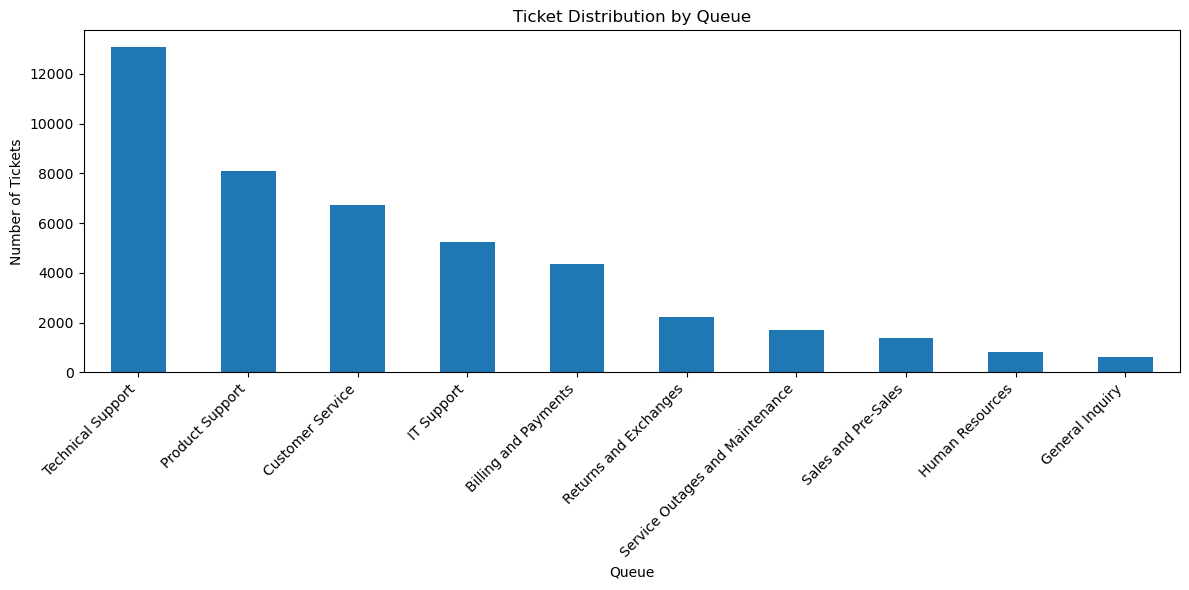

In [11]:
# Queue counts chart

if "queue" in df.columns:
    queue_counts = df["queue"].value_counts()

    plt.figure(figsize=(12, 6))
    queue_counts.plot(kind="bar")

    plt.title("Ticket Distribution by Queue")
    plt.xlabel("Queue")
    plt.ylabel("Number of Tickets")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()


In [12]:
# Tickets per priority

if "priority" in df.columns:
    priority_counts = df["priority"].value_counts(dropna=False)

    print("Priority counts:")
    display(priority_counts)

    print("\nPriority percentages:")
    display(
        (priority_counts / len(df) * 100)
        .round(2)
    )


Priority counts:


priority
medium    17961
high      17355
low        8962
Name: count, dtype: int64


Priority percentages:


priority
medium    40.56
high      39.20
low       20.24
Name: count, dtype: float64

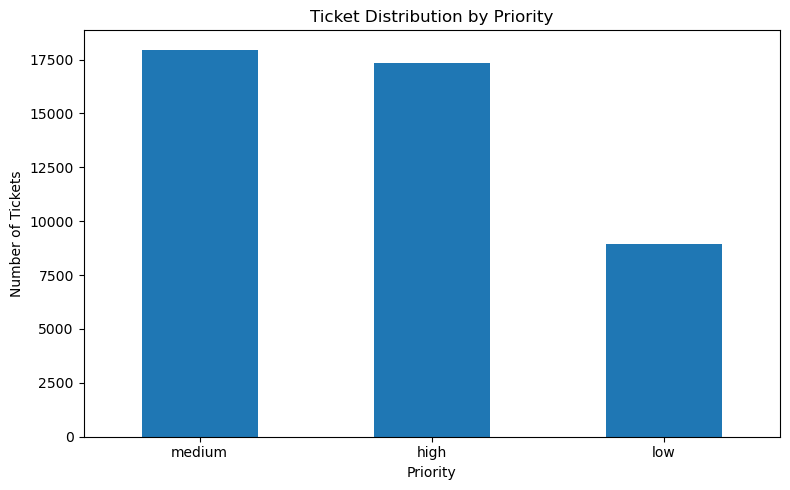

In [13]:
# Priority counts chart

if "priority" in df.columns:
    df["priority"].value_counts().plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title("Ticket Distribution by Priority")
    plt.xlabel("Priority")
    plt.ylabel("Number of Tickets")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


In [14]:
# Tickets per type

if "type" in df.columns:
    type_counts = df["type"].value_counts(dropna=False)

    print("Ticket type counts:")
    display(type_counts)

    print("\nTicket type percentages:")
    display(
        (type_counts / len(df) * 100)
        .round(2)
    )


Ticket type counts:


type
Incident    17758
Request     12714
Problem      9271
Change       4535
Name: count, dtype: int64


Ticket type percentages:


type
Incident    40.11
Request     28.71
Problem     20.94
Change      10.24
Name: count, dtype: float64

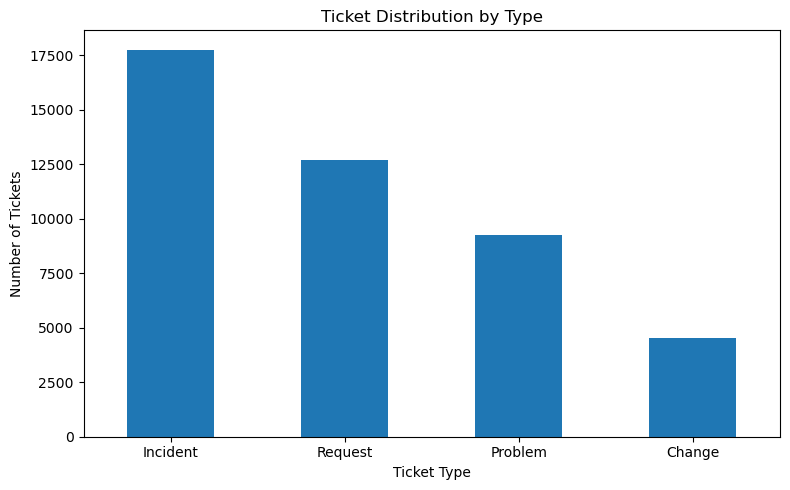

In [15]:
# Ticket type chart

if "type" in df.columns:
    df["type"].value_counts().plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title("Ticket Distribution by Type")
    plt.xlabel("Ticket Type")
    plt.ylabel("Number of Tickets")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


In [16]:
# Tickets per language

if "language" in df.columns:
    language_counts = df["language"].value_counts(dropna=False)

    print("Language counts:")
    display(language_counts)

    print("\nLanguage percentages:")
    display(
        (language_counts / len(df) * 100)
        .round(2)
    )


Language counts:


language
en    25138
de    17379
es      812
fr      476
pt      473
Name: count, dtype: int64


Language percentages:


language
en    56.77
de    39.25
es     1.83
fr     1.08
pt     1.07
Name: count, dtype: float64

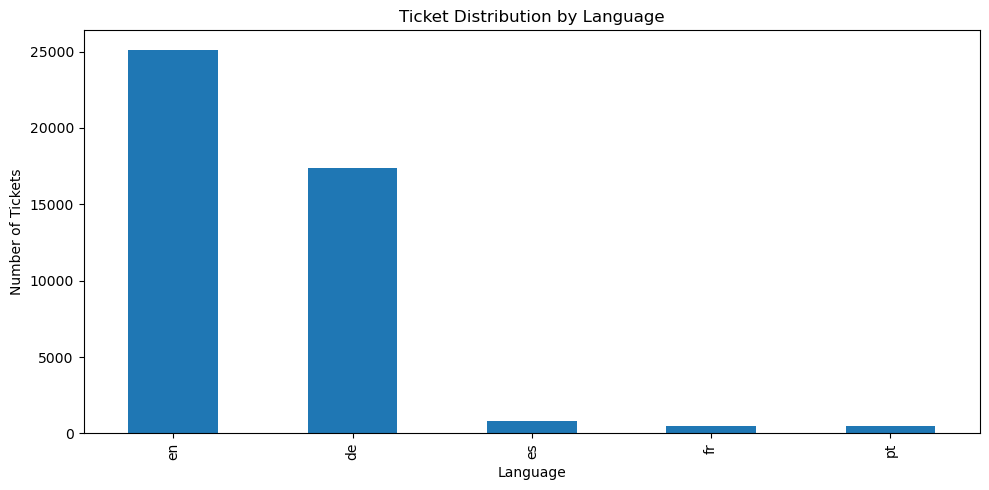

In [17]:
# Language counts chart

if "language" in df.columns:
    df["language"].value_counts().plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title("Ticket Distribution by Language")
    plt.xlabel("Language")
    plt.ylabel("Number of Tickets")

    plt.tight_layout()
    plt.show()


Source dataset counts:


source_dataset
multi-lang-5-2-50-version                     20278
multi-lang-4-20k                              11692
multi-lang-4-20k;multi-lang-5-2-50-version     8308
multi-lang3-4k                                 4000
Name: count, dtype: int64

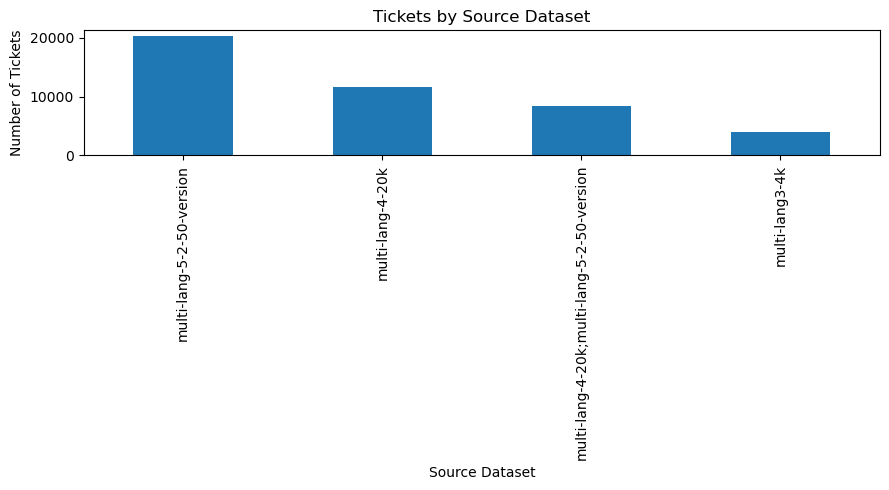

In [18]:
# Tickets per source file

if "source_dataset" in df.columns:
    source_counts = df["source_dataset"].value_counts()

    print("Source dataset counts:")
    display(source_counts)

    source_counts.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title("Tickets by Source Dataset")
    plt.xlabel("Source Dataset")
    plt.ylabel("Number of Tickets")

    plt.tight_layout()
    plt.show()


In [19]:
# Ticket lengths

if "ticket_text" in df.columns:
    df["ticket_length_chars"] = (
        df["ticket_text"]
        .fillna("")
        .str.len()
    )

    df["ticket_length_words"] = (
        df["ticket_text"]
        .fillna("")
        .str.split()
        .str.len()
    )

    print("Character length statistics:")
    display(df["ticket_length_chars"].describe())

    print("\nWord length statistics:")
    display(df["ticket_length_words"].describe())


Character length statistics:


count    44278.000000
mean       469.457699
std        282.476585
min          4.000000
25%        264.000000
50%        438.000000
75%        613.000000
max       2911.000000
Name: ticket_length_chars, dtype: float64


Word length statistics:


count    44278.000000
mean        65.845409
std         40.991100
min          1.000000
25%         36.000000
50%         61.000000
75%         87.000000
max        394.000000
Name: ticket_length_words, dtype: float64

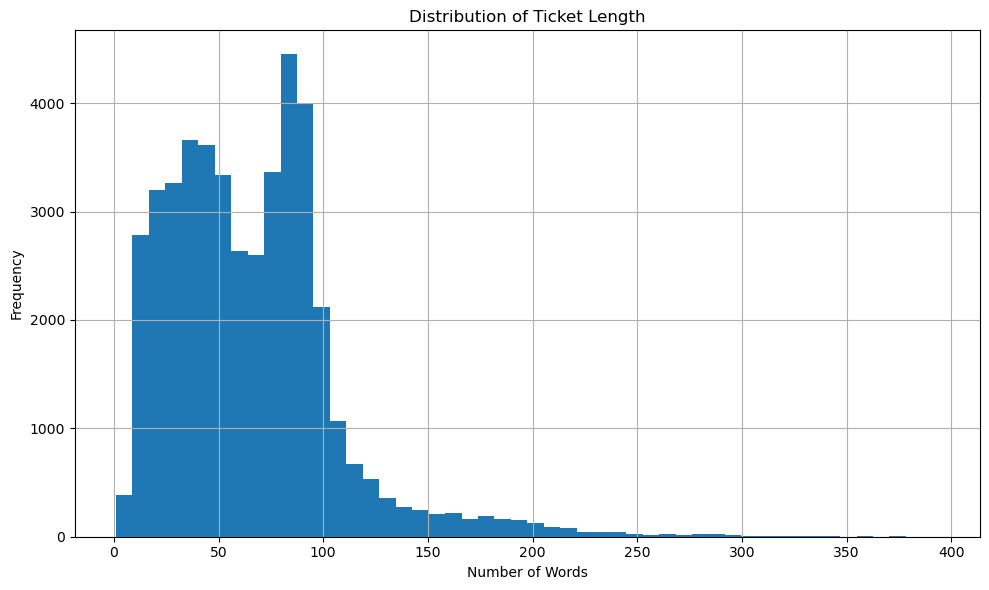

In [20]:
# Word count histogram

if "ticket_length_words" in df.columns:
    plt.figure(figsize=(10, 6))

    df["ticket_length_words"].hist(bins=50)

    plt.title("Distribution of Ticket Length")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


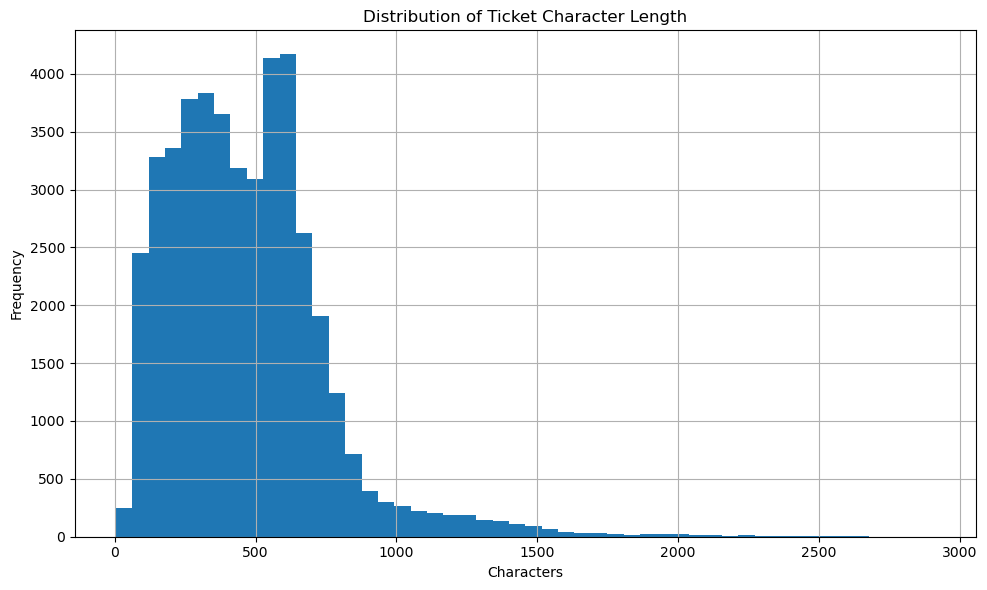

In [21]:
# Character count histogram

if "ticket_length_chars" in df.columns:
    plt.figure(figsize=(10, 6))

    df["ticket_length_chars"].hist(bins=50)

    plt.title("Distribution of Ticket Character Length")
    plt.xlabel("Characters")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


In [22]:
# Queues and priorities

if (
    "queue" in df.columns
    and "priority" in df.columns
):
    queue_priority = pd.crosstab(
        df["queue"],
        df["priority"]
    )

    display(queue_priority)


priority,high,low,medium
queue,,,
Billing and Payments,1303,933,2132
Customer Service,1270,2214,3257
General Inquiry,79,359,177
Human Resources,87,386,329
IT Support,2519,511,2207
Product Support,2463,1593,4057
Returns and Exchanges,465,823,916
Sales and Pre-Sales,228,501,664
Service Outages and Maintenance,1223,187,300


In [23]:
# Queues and ticket types

if (
    "queue" in df.columns
    and "type" in df.columns
):
    queue_type = pd.crosstab(
        df["queue"],
        df["type"]
    )

    display(queue_type)


type,Change,Incident,Problem,Request
queue,,,,
Billing and Payments,253,1052,949,2114
Customer Service,487,1731,1390,3133
General Inquiry,173,197,98,147
Human Resources,57,413,88,244
IT Support,885,1902,1364,1086
Product Support,940,3506,1806,1861
Returns and Exchanges,280,845,453,626
Sales and Pre-Sales,245,305,184,659
Service Outages and Maintenance,419,936,103,252


In [24]:
# Compare the largest and smallest queues

if "queue" in df.columns:
    queue_counts = df["queue"].value_counts()

    largest_class = queue_counts.max()
    smallest_class = queue_counts.min()

    imbalance_ratio = largest_class / smallest_class

    print("Largest class:", largest_class)
    print("Smallest class:", smallest_class)
    print(
        "Largest-to-smallest class ratio:",
        round(imbalance_ratio, 2)
    )


Largest class: 13095
Smallest class: 615
Largest-to-smallest class ratio: 21.29


In [25]:
# Queue counts and percentages

if "queue" in df.columns:
    queue_summary = pd.DataFrame({
        "count": df["queue"].value_counts()
    })

    queue_summary["percentage"] = (
        queue_summary["count"]
        / len(df)
        * 100
    ).round(2)

    display(queue_summary)


,count,percentage
queue,,
Technical Support,13095,29.57
Product Support,8113,18.32
Customer Service,6741,15.22
IT Support,5237,11.83
Billing and Payments,4368,9.86
Returns and Exchanges,2204,4.98
Service Outages and Maintenance,1710,3.86
Sales and Pre-Sales,1393,3.15
Human Resources,802,1.81


In [26]:
# Sample tickets

sample_columns = [
    col for col in
    [
        "subject",
        "body",
        "ticket_text",
        "queue",
        "priority",
        "type",
        "language",
        "source_dataset"
    ]
    if col in df.columns
]

display(
    df[sample_columns]
    .sample(10, random_state=42)
)


,subject,body,ticket_text,queue,priority,type,language,source_dataset
36251,Request for Data Lockdown,Data lockdown was detected; sensitive medical information might have been exposed due to outdated security protocols. Anti-virus software has been...,Request for Data Lockdown Data lockdown was detected; sensitive medical information might have been exposed due to outdated security protocols. An...,Technical Support,high,Problem,de,multi-lang-5-2-50-version
43037,Request for Mesh Network Support,"We are facing intermittent connectivity problems with the Netgear Nighthawk Mesh system, which is affecting our data analysis tools and efforts to...","Request for Mesh Network Support We are facing intermittent connectivity problems with the Netgear Nighthawk Mesh system, which is affecting our d...",Technical Support,medium,Incident,en,multi-lang-5-2-50-version
31069,Unexpected System Failure,"The data analytics platform is crashing suddenly, potentially due to software conflicts. I have rebooted the systems and verified updates, but the...","Unexpected System Failure The data analytics platform is crashing suddenly, potentially due to software conflicts. I have rebooted the systems and...",Technical Support,high,Incident,en,multi-lang-5-2-50-version
33778,Eiliger IT-Support erforderlich,"Das IT-System des Krankenhauses wurde unautorisiert zugänglich gemacht, wodurch sensible medizinische Daten möglicherweise kompromittiert wurden. ...","Eiliger IT-Support erforderlich Das IT-System des Krankenhauses wurde unautorisiert zugänglich gemacht, wodurch sensible medizinische Daten möglic...",Technical Support,low,Incident,de,multi-lang-5-2-50-version
25044,Cassandra-Integration,"Bitte nehmen Sie Kontakt auf, um eine Beratung zur Integration von Cassandra 4.0 in RapidMiner zu erhalten. Wir suchen nach verbesserten Methoden ...","Cassandra-Integration Bitte nehmen Sie Kontakt auf, um eine Beratung zur Integration von Cassandra 4.0 in RapidMiner zu erhalten. Wir suchen nach ...",Technical Support,low,Request,de,multi-lang-5-2-50-version
23662,Securing Medical Data in Hospital Settings,Please provide detailed solutions.,Securing Medical Data in Hospital Settings Please provide detailed solutions.,Sales and Pre-Sales,medium,Request,en,multi-lang-4-20k
6075,Encountered Issues with Medical Data Encryption,There has been a failure in the encryption of medical data. There may be an issue with the configuration of the Scikit-learn library. Steps alread...,Encountered Issues with Medical Data Encryption There has been a failure in the encryption of medical data. There may be an issue with the configu...,Technical Support,low,Incident,en,multi-lang-4-20k
2541,NaN,"Dear IT Services Support Team,<br><br>We are experiencing an issue with Jira Software 8.20. Our clients are unable to create user accounts, and th...","Dear IT Services Support Team,<br><br>We are experiencing an issue with Jira Software 8.20. Our clients are unable to create user accounts, and th...",Technical Support,high,Incident,en,multi-lang3-4k
10458,Report Generation Issue,The data analytics tool has ceased to generate reports due to a software update.,Report Generation Issue The data analytics tool has ceased to generate reports due to a software update.,Technical Support,medium,Incident,en,multi-lang-4-20k;multi-lang-5-2-50-version
18618,Optimizing Marketing with Ableton Live,I am seeking advice on using Ableton Live for digital marketing strategies. Could you provide insights on how to effectively utilize the tool? Spe...,Optimizing Marketing with Ableton Live I am seeking advice on using Ableton Live for digital marketing strategies. Could you provide insights on h...,IT Support,high,Request,en,multi-lang-4-20k;multi-lang-5-2-50-version


In [27]:
# Sample tickets from each queue

if "queue" in df.columns:
    for queue_name in df["queue"].dropna().unique():
        print("\n" + "=" * 80)
        print("QUEUE:", queue_name)
        print("=" * 80)

        sample = (
            df[df["queue"] == queue_name]
            .sample(
                min(3, len(df[df["queue"] == queue_name])),
                random_state=42
            )
        )

        display(
            sample[
                [
                    col for col in
                    [
                        "ticket_text",
                        "priority",
                        "language"
                    ]
                    if col in sample.columns
                ]
            ]
        )



QUEUE: Technical Support


,ticket_text,priority,language
4591,Concerns about Display Configuration I am facing display-related problems with the Acer Predator XB273K monitor while using a project management S...,high,en
13396,"Dear customer support, I am contacting you to report an issue with the website managed by our marketing agency. We are currently facing issues suc...",medium,en
25217,"Das Unternehmen erlebte Verzögerungen im System, wobei mehrere Produkte aufgrund von Netzwerküberlastungen bei intensiven Datenanalyseprozessen be...",high,de



QUEUE: Customer Service


,ticket_text,priority,language
1363,"Solicitação de Alta Prioridade para Serviço de TI Caro Time de Suporte da Empresa de Consultoria de TI, espero que esta mensagem o encontre bem. E...",high,pt
21293,Sicherung medizinischer Daten auf Linux Mint IT-Systemen in Krankenhäusern Für die Sicherung medizinischer Daten auf Linux Mint-Betriebssystemen i...,medium,de
16801,"Erkundung digitaler Strategien zur Förderung des Markenwachstums Sehr geehrte Kundenservice, ich beschreibe im folgenden Brief meine Bemühungen, D...",medium,de



QUEUE: IT Support


...

,ticket_text,priority,language
16023,"Issue with Order Several items from my last order are missing. I have contacted customer support, but the issue remains unresolved. It might be du...",medium,de
12260,"Concern about Data Breach A data breach has occurred, which might have exposed sensitive medical information. After updating the antivirus softwar...",medium,en
35735,Guide for Integrating Joomla SaaS Project Management Solution Seeking guidance on integrating the Joomla SaaS project management solution. Could y...,high,en



QUEUE: Sales and Pre-Sales


,ticket_text,priority,language
9863,"Anfrage zu Digitalen Strategie-Dienstleistungen für Markenwachstum Bitte kontaktieren Sie mich, um die digitalen Strategie-Dienstleistungen hinsic...",low,de
34752,Inquiry Regarding Digital Strategy Services Today Seeking information on digital strategy services to enhance brand growth. Would appreciate detai...,low,en
31231,Flexible SaaS-Project Management Solutions Könnten Sie bitte zusätzliche Informationen zu den verfügbaren Anpassungsmöglichkeiten der skalierbaren...,low,de



QUEUE: Human Resources


,ticket_text,priority,language
11621,Probleme mit der Zugriffsfunktion auf kritische SaaS-Funktionalitäten gemeldet Es gibt plötzlich Fehler beim Zugriff auf kritische SaaS-Funktional...,medium,de
17490,"Report on Security Breach of Data Through Unsecured Channel To Customer Support, I am contacting you to report a critical incident where medical d...",low,en
10104,Problem with Delayed Payroll Processing There have been complaints about delayed payroll processing. A potential system glitch could be the cause....,medium,en


In [29]:
# Missing queue labels

TARGET = "queue"

if TARGET in df.columns:
    missing_target = df[TARGET].isnull().sum()

    print(f"Missing {TARGET} labels:", missing_target)


Missing queue labels: 0


In [30]:
# Blank queue labels

if TARGET in df.columns:
    empty_target = (
        df[TARGET]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"Empty {TARGET} labels:", empty_target)


Empty queue labels: 0


In [31]:
# Empty ticket text

if "ticket_text" in df.columns:
    empty_text = (
        df["ticket_text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print("Empty ticket_text rows:", empty_text)


Empty ticket_text rows: 0


In [32]:
# Check for queue names in ticket text
# A queue name in the text is worth checking, but does not prove leakage.

if (
    "queue" in df.columns
    and "ticket_text" in df.columns
):
    leakage_results = []

    for queue_name in df["queue"].dropna().unique():
        queue_string = str(queue_name).lower()

        count = (
            df["ticket_text"]
            .fillna("")
            .str.lower()
            .str.contains(
                queue_string,
                regex=False
            )
            .sum()
        )

        leakage_results.append({
            "queue": queue_name,
            "tickets_containing_queue_name": count
        })

    leakage_df = pd.DataFrame(leakage_results)

    display(
        leakage_df.sort_values(
            "tickets_containing_queue_name",
            ascending=False
        )
    )


,queue,tickets_containing_queue_name
1,Customer Service,570
0,Technical Support,161
2,IT Support,56
3,Product Support,18
7,Returns and Exchanges,17
4,Billing and Payments,10
9,Human Resources,8
5,Service Outages and Maintenance,6
6,General Inquiry,0
8,Sales and Pre-Sales,0


In [33]:
# Source files per ticket

if "source_count" in df.columns:
    print("Source count distribution:")

    display(
        df["source_count"]
        .value_counts()
        .sort_index()
    )


Source count distribution:


source_count
1    35970
2     8308
Name: count, dtype: int64

In [34]:
# Original duplicate counts

if "duplicate_record_count" in df.columns:
    display(
        df["duplicate_record_count"]
        .value_counts()
        .sort_index()
    )

    print(
        "Tickets that originally appeared more than once:",
        (df["duplicate_record_count"] > 1).sum()
    )


duplicate_record_count
1    35970
2     8307
3        1
Name: count, dtype: int64

Tickets that originally appeared more than once: 8308


In [35]:
# Most repeated original tickets

if (
    "duplicate_record_count" in df.columns
    and "ticket_text" in df.columns
):
    top_duplicates = (
        df.sort_values(
            "duplicate_record_count",
            ascending=False
        )
        [
            [
                col for col in
                [
                    "ticket_text",
                    "duplicate_record_count",
                    "source_count",
                    "queue"
                ]
                if col in df.columns
            ]
        ]
        .head(20)
    )

    display(top_duplicates)


,ticket_text,duplicate_record_count,source_count,queue
10548,Problems with Software Integration,3,2,Technical Support
20586,"Support for Recent Campaign Issues Dear Support Team, We recently launched a digital campaign through the Brand Agency, but the expected engagemen...",2,2,Returns and Exchanges
20584,Issues Accessing Secure Medical Data There are issues accessing secured medical data due to incompatible software integrations.,2,2,Technical Support
6520,Encountering difficulties in generating precise investment reports through data analytics tools owing to data integration problems.,2,2,Product Support
20583,"Leistungsmangel bei Datenanalysewerkzeug Das Datenanalysewerkzeug hat Leistungsprobleme bei der Datenabholung erfahren, was auf mögliche Systemübe...",2,2,Returns and Exchanges
17681,Notice of Security Incident in Medical Data Systems A security breach has been identified in the medical data systems. This may have occurred due ...,2,2,Technical Support
20580,"Customer Support, <br><br>Our marketing agency is facing intermittent access problems with various digital tools, which may be due to network inst...",2,2,Technical Support
6525,"Sicherheitsanomalie melden Sehr geehrte Kundenservice, ich melde ein dringendes Sicherheitsproblem mit unserem medizinischen Datensystem. Unerwart...",2,2,Technical Support
6527,Istcstdinte Serverabstimmung gemeldet In der Agentur wurde während der kritischen Kampagnenstartphase eine unerwartete Serverabstimmung beobachtet...,2,2,Service Outages and Maintenance
20595,"Concerns Regarding Technical Issues with Marketing Software Systems Hello Customer Support, I hope this message finds you well. I am writing to dr...",2,2,IT Support


In [36]:
# Dataset summary

print("=" * 70)
print("MODEL READINESS SUMMARY")
print("=" * 70)

print(f"\nTotal rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")

if "queue" in df.columns:
    print(
        f"Unique routing queues: "
        f"{df['queue'].nunique()}"
    )

if "language" in df.columns:
    print(
        f"Unique languages: "
        f"{df['language'].nunique()}"
    )

if "priority" in df.columns:
    print(
        f"Unique priorities: "
        f"{df['priority'].nunique()}"
    )

if "type" in df.columns:
    print(
        f"Unique ticket types: "
        f"{df['type'].nunique()}"
    )

if "ticket_text" in df.columns:
    print(
        f"Median ticket length: "
        f"{df['ticket_length_words'].median():.0f} words"
    )

    print(
        f"Mean ticket length: "
        f"{df['ticket_length_words'].mean():.2f} words"
    )

    print(
        f"Maximum ticket length: "
        f"{df['ticket_length_words'].max():,.0f} words"
    )

print("\nExact duplicates:", df.duplicated().sum())


MODEL READINESS SUMMARY

Total rows: 44,278
Total columns: 24
Unique routing queues: 10
Unique languages: 5
Unique priorities: 3
Unique ticket types: 4
Median ticket length: 61 words
Mean ticket length: 65.85 words
Maximum ticket length: 394 words

Exact duplicates: 0


<a id="section-5"></a>
## 5. Feature engineering and Feature Store

We combined each ticket’s subject and body into one text field. We also prepared extra information, such as the language, word count, and character count, to see whether it could help the model.

We saved the training and validation records in SageMaker Feature Store. Then we read them back through Athena and checked that the values matched what we had prepared.

In the next section, we compare these features and choose a model that uses only the combined ticket text.

**Original notebook:** [feature_engineering.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/9480386/feature_engineering.ipynb)

The cells below show how we prepared, stored, and checked the features.


In [1]:
from pathlib import Path
from urllib.parse import urlparse
import json
import boto3
import pandas as pd

PROJECT_ROOT = Path.cwd()
config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

aws_session = boto3.Session(region_name=AWS_REGION)
s3_client = aws_session.client("s3")

def load_saved_split(name):
    """Read the exact S3 file version recorded in our configuration."""
    file_info = project_config["s3_data"][name]
    location = urlparse(file_info["uri"])

    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
        VersionId=file_info["version_id"]
    )

    try:
        return pd.read_csv(
            response["Body"],
            dtype={"ticket_id": "string"},
            low_memory=False
        )
    finally:
        response["Body"].close()

train_df = load_saved_split("train")
validation_df = load_saved_split("validation")

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Columns:", train_df.columns.tolist())


Training rows: 17710
Validation rows: 4428
Columns: ['ticket_id', 'subject', 'body', 'language', 'priority', 'type', 'queue']


In [2]:
def engineer_features(df):
    result = df.copy()

    subject = result["subject"].fillna("").astype(str).str.strip()
    body = result["body"].fillna("").astype(str).str.strip()

    result["combined_text"] = (subject + " " + body).str.strip()

    # Record subject presence, character counts, and word counts.
    result["has_subject"] = subject.ne("").astype(int)

    result["subject_char_count"] = subject.str.len()
    result["body_char_count"] = body.str.len()
    result["text_char_count"] = result["combined_text"].str.len()

    result["subject_word_count"] = subject.str.split().str.len()
    result["body_word_count"] = body.str.split().str.len()
    result["text_word_count"] = (
        result["combined_text"].str.split().str.len()
    )

    return result


train_features = engineer_features(train_df)
validation_features = engineer_features(validation_df)

structural_columns = [
    "has_subject",
    "subject_char_count",
    "body_char_count",
    "text_char_count",
    "subject_word_count",
    "body_word_count",
    "text_word_count",
]

# Check ticket IDs, text, and missing features.
for name, original, features in [
    ("Training", train_df, train_features),
    ("Validation", validation_df, validation_features),
]:
    assert features["ticket_id"].equals(original["ticket_id"])
    assert features["combined_text"].str.len().gt(0).all()
    assert features[structural_columns].notna().all().all()
    print(f"{name}: {len(features):,} tickets")

display(train_features[structural_columns].head())


Training: 17,710 tickets
Validation: 4,428 tickets


,has_subject,subject_char_count,body_char_count,text_char_count,subject_word_count,body_word_count,text_word_count
0,1,51,312,364,7,48,55
1,1,38,446,485,4,54,58
2,1,35,519,555,4,75,79
3,1,21,270,292,3,40,43
4,0,0,776,776,0,89,89


In [3]:
TEXT_COLUMN = "combined_text"
CATEGORICAL_COLUMNS = ["language"]
NUMERIC_COLUMNS = structural_columns.copy()
TARGET_COLUMN = "queue"

MODEL_INPUT_COLUMNS = [
    TEXT_COLUMN,
    *CATEGORICAL_COLUMNS,
    *NUMERIC_COLUMNS,
]

for features in [train_features, validation_features]:
    features["language"] = (
        features["language"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace("", "unknown")
    )

# Keep ticket IDs and queue labels out of the model inputs.
assert "ticket_id" not in MODEL_INPUT_COLUMNS
assert TARGET_COLUMN not in MODEL_INPUT_COLUMNS

print("Text input:", TEXT_COLUMN)
print("Categorical inputs:", CATEGORICAL_COLUMNS)
print("Numeric inputs:", NUMERIC_COLUMNS)
print("Prediction target:", TARGET_COLUMN)
print("Training queues:", train_features[TARGET_COLUMN].nunique())


Text input: combined_text
Categorical inputs: ['language']
Numeric inputs: ['has_subject', 'subject_char_count', 'body_char_count', 'text_char_count', 'subject_word_count', 'body_word_count', 'text_word_count']
Prediction target: queue
Training queues: 10


In [4]:
sagemaker_client = aws_session.client("sagemaker")
featurestore_runtime = aws_session.client("sagemaker-featurestore-runtime")
iam_client = aws_session.client("iam")

# Use the lab execution role.
EXECUTION_ROLE_ARN = iam_client.get_role(
    RoleName="LabRole"
)["Role"]["Arn"]

snapshot_id = project_config["dataset_sha256"][:12]

FEATURE_GROUP_NAME = f"aai540-group3-tickets-{snapshot_id}-v1"
FEATURE_STORE_S3_URI = (
    f"s3://{PROJECT_BUCKET}/feature-store/"
)

# Set the Feature Store column types.
# Store IDs and labels with the features,
# but only MODEL_INPUT_COLUMNS will enter the model.
feature_definitions = [
    {"FeatureName": "ticket_id", "FeatureType": "String"},
    {"FeatureName": "event_time", "FeatureType": "Fractional"},
    {"FeatureName": "split", "FeatureType": "String"},
    {"FeatureName": "combined_text", "FeatureType": "String"},
    {"FeatureName": "language", "FeatureType": "String"},
    {"FeatureName": "queue", "FeatureType": "String"},
]

feature_definitions += [
    {"FeatureName": column, "FeatureType": "Integral"}
    for column in NUMERIC_COLUMNS
]

print("Execution role:", EXECUTION_ROLE_ARN)
print("Feature group:", FEATURE_GROUP_NAME)
print("Offline storage:", FEATURE_STORE_S3_URI)
print("Registered column definitions:", len(feature_definitions))


Execution role: arn:aws:iam::390568313988:role/LabRole
Feature group: aai540-group3-tickets-c142eef90e9f-v1
Offline storage: s3://aai540-group3-tickets-390568313988-us-east-1/feature-store/
Registered column definitions: 13


In [5]:
from botocore.exceptions import ClientError

try:
    feature_group_info = sagemaker_client.describe_feature_group(
        FeatureGroupName=FEATURE_GROUP_NAME
    )
    print("Feature group already exists.")

except ClientError as error:
    if error.response["Error"]["Code"] != "ResourceNotFound":
        raise

    sagemaker_client.create_feature_group(
        FeatureGroupName=FEATURE_GROUP_NAME,
        RecordIdentifierFeatureName="ticket_id",
        EventTimeFeatureName="event_time",
        FeatureDefinitions=feature_definitions,
        OfflineStoreConfig={
            "S3StorageConfig": {
                "S3Uri": FEATURE_STORE_S3_URI
            },
            "DisableGlueTableCreation": False
        },
        RoleArn=EXECUTION_ROLE_ARN,
        Description=(
            "Multilingual ticket text and structural features. "
            "Includes split membership and queue labels."
        )
    )
    print("Feature group creation requested.")

    feature_group_info = sagemaker_client.describe_feature_group(
        FeatureGroupName=FEATURE_GROUP_NAME
    )

print("Feature group:", FEATURE_GROUP_NAME)
print("Status:", feature_group_info["FeatureGroupStatus"])

if feature_group_info.get("FailureReason"):
    print("Failure reason:", feature_group_info["FailureReason"])


Feature group creation requested.
Feature group: aai540-group3-tickets-c142eef90e9f-v1
Status: Creating


In [6]:
import time

for attempt in range(12):
    feature_group_info = sagemaker_client.describe_feature_group(
        FeatureGroupName=FEATURE_GROUP_NAME
    )
    status = feature_group_info["FeatureGroupStatus"]

    if status == "Created":
        break

    if status != "Creating":
        raise RuntimeError(
            f"Feature group status: {status}. "
            f"{feature_group_info.get('FailureReason', '')}"
        )

    time.sleep(5)

else:
    raise TimeoutError(
        "AWS is still creating the feature group. "
        "Wait a minute, then rerun this cell."
    )

project_config.setdefault("feature_store", {}).update({
    "feature_group_name": FEATURE_GROUP_NAME,
    "feature_group_arn": feature_group_info["FeatureGroupArn"],
    "execution_role_arn": EXECUTION_ROLE_ARN,
    "offline_s3_uri": FEATURE_STORE_S3_URI,
    "model_input_columns": MODEL_INPUT_COLUMNS,
    "target_column": TARGET_COLUMN,
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Feature group status:", status)
print(
    "Offline store status:",
    feature_group_info.get("OfflineStoreStatus", {})
    .get("Status", "Not reported")
)


Feature group status: Created
Offline store status: Not reported


In [7]:
import time

# Reuse the timestamp when resuming this feature upload.
# This records when we prepared the features, not when tickets arrived.
feature_event_time = project_config["feature_store"].setdefault(
    "feature_event_time", time.time()
)

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

stored_columns = ["ticket_id", *MODEL_INPUT_COLUMNS, TARGET_COLUMN]

feature_records_df = pd.concat(
    [
        train_features[stored_columns].assign(split="train"),
        validation_features[stored_columns].assign(split="validation"),
    ],
    ignore_index=True
)

feature_records_df["event_time"] = feature_event_time

# Match the Feature Store column order.
store_columns = [
    definition["FeatureName"]
    for definition in feature_definitions
]
feature_records_df = feature_records_df[store_columns]

assert feature_records_df["ticket_id"].is_unique
assert feature_records_df.notna().all().all()

def make_feature_record(row):
    return [
        {"FeatureName": column, "ValueAsString": str(row[column])}
        for column in store_columns
    ]

# Send one record before uploading the remaining records.
sample_row = feature_records_df.iloc[0]

featurestore_runtime.put_record(
    FeatureGroupName=FEATURE_GROUP_NAME,
    Record=make_feature_record(sample_row),
    TargetStores=["OfflineStore"]
)

sample_ticket_id = str(sample_row["ticket_id"])

print("Records prepared:", len(feature_records_df))
print(feature_records_df["split"].value_counts())
print("Sample record accepted by Feature Store.")


Records prepared: 22138
split
train         17710
validation     4428
Name: count, dtype: int64
Sample record accepted by Feature Store.


In [8]:
from concurrent.futures import ThreadPoolExecutor
from botocore.config import Config

# Retry temporary AWS errors automatically.
featurestore_runtime = aws_session.client(
    "sagemaker-featurestore-runtime",
    config=Config(
        retries={"mode": "standard", "max_attempts": 10},
        max_pool_connections=10
    )
)

# Track completed uploads for this feature version.
progress_dir = PROJECT_ROOT / "data" / "feature_store"
progress_dir.mkdir(parents=True, exist_ok=True)

progress_file = progress_dir / (
    f"{FEATURE_GROUP_NAME}-{int(feature_event_time * 1_000_000)}.txt"
)

uploaded_ids = (
    set(progress_file.read_text().splitlines())
    if progress_file.exists()
    else set()
)

# The sample record was already accepted.
with progress_file.open("a", encoding="utf-8") as log:
    if sample_ticket_id not in uploaded_ids:
        log.write(sample_ticket_id + "\n")
        uploaded_ids.add(sample_ticket_id)

pending_records = feature_records_df.loc[
    ~feature_records_df["ticket_id"].isin(uploaded_ids)
].to_dict("records")

def upload_feature_record(row):
    ticket_id = str(row["ticket_id"])
    try:
        featurestore_runtime.put_record(
            FeatureGroupName=FEATURE_GROUP_NAME,
            Record=make_feature_record(row),
            TargetStores=["OfflineStore"]
        )
        return ticket_id, None
    except Exception as error:
        return ticket_id, str(error)

print(f"Records remaining to upload: {len(pending_records):,}", flush=True)
failed_uploads = []

with progress_file.open("a", encoding="utf-8") as log:
    with ThreadPoolExecutor(max_workers=8) as executor:
        for ticket_id, error in executor.map(
            upload_feature_record, pending_records
        ):
            if error is not None:
                failed_uploads.append((ticket_id, error))
                continue

            uploaded_ids.add(ticket_id)
            log.write(ticket_id + "\n")
            log.flush()

            if len(uploaded_ids) % 1000 == 0:
                print(
                    f"Accepted: {len(uploaded_ids):,} / "
                    f"{len(feature_records_df):,}",
                    flush=True
                )

print(f"Upload failures: {len(failed_uploads)}")

if failed_uploads:
    print("First error:", failed_uploads[0][1])
    raise RuntimeError("Some uploads failed. Check the error above.")

assert set(feature_records_df["ticket_id"]).issubset(uploaded_ids)
print(f"All {len(feature_records_df):,} feature records accepted.")


Records remaining to upload: 22,137
Accepted: 1,000 / 22,138
Accepted: 2,000 / 22,138
Accepted: 3,000 / 22,138
Accepted: 4,000 / 22,138
Accepted: 5,000 / 22,138
Accepted: 6,000 / 22,138
Accepted: 7,000 / 22,138
Accepted: 8,000 / 22,138
Accepted: 9,000 / 22,138
Accepted: 10,000 / 22,138
Accepted: 11,000 / 22,138
Accepted: 12,000 / 22,138
Accepted: 13,000 / 22,138
Accepted: 14,000 / 22,138
Accepted: 15,000 / 22,138
Accepted: 16,000 / 22,138
Accepted: 17,000 / 22,138
Accepted: 18,000 / 22,138
Accepted: 19,000 / 22,138
Accepted: 20,000 / 22,138
Accepted: 21,000 / 22,138
Accepted: 22,000 / 22,138
Upload failures: 0
All 22,138 feature records accepted.


In [10]:
athena_client = aws_session.client("athena")

# Find the Athena table for this feature group.
feature_group_info = sagemaker_client.describe_feature_group(
    FeatureGroupName=FEATURE_GROUP_NAME
)
catalog_info = feature_group_info[
    "OfflineStoreConfig"
]["DataCatalogConfig"]

FEATURE_DATABASE = catalog_info["Database"]
FEATURE_TABLE = catalog_info["TableName"]

print("Database:", FEATURE_DATABASE)
print("Table:", FEATURE_TABLE)

# Count tickets from this feature upload.
# DISTINCT avoids counting retried uploads twice.
count_sql = f"""
SELECT
    split,
    COUNT(DISTINCT ticket_id) AS ticket_count
FROM "{FEATURE_DATABASE}"."{FEATURE_TABLE}"
WHERE is_deleted = false
  AND event_time = CAST({feature_event_time!r} AS DOUBLE)
GROUP BY split
ORDER BY split
"""

query_id = athena_client.start_query_execution(
    QueryString=count_sql,
    QueryExecutionContext={
        "Database": FEATURE_DATABASE,
        "Catalog": "AwsDataCatalog"
    },
    ResultConfiguration={
        "OutputLocation": project_config["athena"]["query_output"]
    },
    WorkGroup=project_config["athena"]["workgroup"]
)["QueryExecutionId"]

print("Query ID:", query_id)

for attempt in range(30):
    query_status = athena_client.get_query_execution(
        QueryExecutionId=query_id
    )["QueryExecution"]["Status"]

    state = query_status["State"]
    if state == "SUCCEEDED":
        break
    if state in {"FAILED", "CANCELLED"}:
        raise RuntimeError(query_status.get("StateChangeReason", state))
    time.sleep(2)
else:
    raise TimeoutError(f"Query is still running: {query_id}")

rows = athena_client.get_query_results(
    QueryExecutionId=query_id
)["ResultSet"]["Rows"]

actual_counts = {
    row["Data"][0]["VarCharValue"]:
        int(row["Data"][1]["VarCharValue"])
    for row in rows[1:]
}

expected_counts = {"train": 17710, "validation": 4428}
print("Expected:", expected_counts)
print("Available:", actual_counts)

if actual_counts == expected_counts:
    print("Counts match.")
else:
    print("Counts differ. Wait and check again.")


Database: sagemaker_featurestore
Table: aai540_group3_tickets_c142eef90e9f_v1_1791068947
Query ID: 6b14f7a0-ba17-411d-b21b-b38a49fc40d5
Expected: {'train': 17710, 'validation': 4428}
Available: {'train': 17710, 'validation': 4428}
Counts match.


In [11]:
# Select one copy of each ticket if any upload was retried.
selected_columns = ", ".join(f'"{c}"' for c in store_columns)

feature_snapshot_sql = f"""
WITH ranked_records AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY ticket_id
            ORDER BY api_invocation_time DESC, write_time DESC
        ) AS row_num
    FROM "{FEATURE_DATABASE}"."{FEATURE_TABLE}"
    WHERE event_time = CAST({feature_event_time!r} AS DOUBLE)
)
SELECT {selected_columns}
FROM ranked_records
WHERE row_num = 1 AND is_deleted = false
"""

feature_query_id = athena_client.start_query_execution(
    QueryString=feature_snapshot_sql,
    QueryExecutionContext={
        "Database": FEATURE_DATABASE,
        "Catalog": "AwsDataCatalog"
    },
    ResultConfiguration={
        "OutputLocation": project_config["athena"]["query_output"]
    },
    WorkGroup=project_config["athena"]["workgroup"]
)["QueryExecutionId"]

print("Feature retrieval query:", feature_query_id)

for attempt in range(30):
    execution = athena_client.get_query_execution(
        QueryExecutionId=feature_query_id
    )["QueryExecution"]

    state = execution["Status"]["State"]
    if state == "SUCCEEDED":
        break
    if state in {"FAILED", "CANCELLED"}:
        raise RuntimeError(
            execution["Status"].get("StateChangeReason", state)
        )
    time.sleep(2)
else:
    raise TimeoutError(f"Query still running: {feature_query_id}")

# Read the Athena query results from S3.
feature_result_uri = execution["ResultConfiguration"]["OutputLocation"]
location = urlparse(feature_result_uri)

response = s3_client.get_object(
    Bucket=location.netloc,
    Key=location.path.lstrip("/")
)
try:
    stored_features = pd.read_csv(
        response["Body"],
        dtype={"ticket_id": "string"},
        keep_default_na=False
    )
finally:
    response["Body"].close()

train_features_store = stored_features[
    stored_features["split"] == "train"
].copy()

validation_features_store = stored_features[
    stored_features["split"] == "validation"
].copy()

# Check that the retrieved tickets are in the original splits.
assert stored_features["ticket_id"].is_unique
assert set(train_features_store["ticket_id"]) == set(train_df["ticket_id"])
assert set(validation_features_store["ticket_id"]) == set(
    validation_df["ticket_id"]
)

print("Training features retrieved:", len(train_features_store))
print("Validation features retrieved:", len(validation_features_store))


Feature retrieval query: 9b502988-5fcb-463b-9e72-b47cf7917d2c
Training features retrieved: 17710
Validation features retrieved: 4428


In [12]:
import hashlib

feature_output_dir = PROJECT_ROOT / "data" / "features"
feature_output_dir.mkdir(parents=True, exist_ok=True)

feature_prefix = (
    f"features/{snapshot_id}/v1/"
    f"{int(feature_event_time * 1_000_000)}"
)

feature_datasets = {}

for name, retrieved, original in [
    ("train", train_features_store, train_features),
    ("validation", validation_features_store, validation_features),
]:
    # Compare the retrieved features and labels with the original values.
    pd.testing.assert_frame_equal(
        retrieved[stored_columns]
        .sort_values("ticket_id").reset_index(drop=True),
        original[stored_columns]
        .sort_values("ticket_id").reset_index(drop=True),
        check_dtype=False
    )

    output_path = feature_output_dir / f"{name}.csv"
    retrieved[stored_columns].sort_values("ticket_id").to_csv(
        output_path, index=False
    )

    s3_key = f"{feature_prefix}/{name}.csv"
    s3_client.upload_file(str(output_path), PROJECT_BUCKET, s3_key)

    metadata = s3_client.head_object(
        Bucket=PROJECT_BUCKET, Key=s3_key
    )
    assert metadata["ContentLength"] == output_path.stat().st_size
    assert metadata.get("VersionId") not in (None, "null")

    feature_datasets[name] = {
        "uri": f"s3://{PROJECT_BUCKET}/{s3_key}",
        "version_id": metadata["VersionId"],
        "rows": len(retrieved),
        "sha256": hashlib.sha256(output_path.read_bytes()).hexdigest(),
    }

    print(f"Saved: {name}.csv")

project_config["feature_store"].update({
    "database": FEATURE_DATABASE,
    "table": FEATURE_TABLE,
    "retrieval_query_id": feature_query_id,
    "retrieval_result_uri": feature_result_uri,
    "datasets": feature_datasets,
    "text_column": TEXT_COLUMN,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "numeric_columns": NUMERIC_COLUMNS,
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Feature Store dataset locations saved in project_config.json.")


Saved: train.csv
Saved: validation.csv
Feature Store dataset locations saved in project_config.json.


<a id="section-6"></a>
## 6. Benchmark, model training, and evaluation

We started with a simple benchmark that predicts “Technical Support” for every ticket because it is the largest queue. This gave us a starting score to compare our models against.

Next, we trained Logistic Regression and compared two options: ticket text alone, and ticket text with extra information such as language and text length. We used the validation data to compare the results and choose the model settings.

Our selected model uses ticket text only. TF-IDF turns individual words and two-word combinations into numerical features. We chose C=10 and balanced class weights, which give more weight to tickets from smaller queues during training.

We then trained the selected model in SageMaker and evaluated it on the separate test data. We saved the overall results and the results for each queue and language.

**Original notebook:** [model_training.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/9480386/model_training.ipynb)

The cells below show our model comparisons, training, and evaluation results.


In [1]:
from pathlib import Path
from urllib.parse import urlparse
from io import BytesIO
import hashlib
import json
import boto3
import pandas as pd

PROJECT_ROOT = Path.cwd()
config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

aws_session = boto3.Session(
    region_name=project_config["aws_region"]
)
s3_client = aws_session.client("s3")

feature_config = project_config["feature_store"]

def load_training_features(split_name):
    file_info = feature_config["datasets"][split_name]
    location = urlparse(file_info["uri"])

    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
        VersionId=file_info["version_id"]
    )
    try:
        content = response["Body"].read()
    finally:
        response["Body"].close()

    assert hashlib.sha256(content).hexdigest() == file_info["sha256"]

    df = pd.read_csv(
        BytesIO(content),
        dtype={"ticket_id": "string"},
        keep_default_na=False
    )
    assert len(df) == file_info["rows"]
    return df

train_df = load_training_features("train")
validation_df = load_training_features("validation")

MODEL_INPUT_COLUMNS = feature_config["model_input_columns"]
TARGET_COLUMN = feature_config["target_column"]

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Model inputs:", MODEL_INPUT_COLUMNS)


Training rows: 17710
Validation rows: 4428
Model inputs: ['combined_text', 'language', 'has_subject', 'subject_char_count', 'body_char_count', 'text_char_count', 'subject_word_count', 'body_word_count', 'text_word_count']


### Simple benchmark


In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train = train_df[MODEL_INPUT_COLUMNS]
y_train = train_df[TARGET_COLUMN]

X_validation = validation_df[MODEL_INPUT_COLUMNS]
y_validation = validation_df[TARGET_COLUMN]

QUEUE_LABELS = sorted(y_train.unique())

# The benchmark always predicts the most common training queue.
benchmark = DummyClassifier(strategy="most_frequent")
benchmark.fit(X_train, y_train)

benchmark_predictions = benchmark.predict(X_validation)

benchmark_metrics = {
    "model": "Majority-class benchmark",
    "evaluation_split": "validation",
    "accuracy": accuracy_score(
        y_validation, benchmark_predictions
    ),
    "macro_f1": f1_score(
        y_validation, benchmark_predictions,
        labels=QUEUE_LABELS, average="macro", zero_division=0
    ),
    "weighted_f1": f1_score(
        y_validation, benchmark_predictions,
        labels=QUEUE_LABELS, average="weighted", zero_division=0
    ),
}

print("Queue predicted for every ticket:", benchmark_predictions[0])
display(pd.DataFrame([benchmark_metrics]).round(4))


Queue predicted for every ticket: Technical Support


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,validation,0.2958,0.0457,0.1351


### Compare text with extra features


In [3]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=30000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            ),
            feature_config["text_column"]
        ),
        (
            "language",
            OneHotEncoder(handle_unknown="ignore"),
            feature_config["categorical_columns"]
        ),
        (
            "structural",
            StandardScaler(),
            feature_config["numeric_columns"]
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        C=1.0,
        random_state=42
    ))
])

print("Training Logistic Regression...", flush=True)
start_time = time.perf_counter()

lr_pipeline.fit(X_train, y_train)

training_seconds = time.perf_counter() - start_time
lr_predictions = lr_pipeline.predict(X_validation)

lr_metrics = {
    "model": "TF-IDF + metadata + Logistic Regression",
    "evaluation_split": "validation",
    "accuracy": accuracy_score(y_validation, lr_predictions),
    "macro_f1": f1_score(
        y_validation, lr_predictions,
        labels=QUEUE_LABELS, average="macro", zero_division=0
    ),
    "weighted_f1": f1_score(
        y_validation, lr_predictions,
        labels=QUEUE_LABELS, average="weighted", zero_division=0
    ),
}

print(f"Training time: {training_seconds:.1f} seconds")
print("Solver iterations:", lr_pipeline["classifier"].n_iter_)
display(pd.DataFrame([benchmark_metrics, lr_metrics]).round(4))


Training Logistic Regression...
Training time: 17.3 seconds
Solver iterations: [216]


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,validation,0.2958,0.0457,0.1351
1,TF-IDF + metadata + Logistic Regression,validation,0.3850,0.3623,0.3890


In [4]:
from sklearn.metrics import classification_report

# Results by queue.
queue_report = classification_report(
    y_validation,
    lr_predictions,
    labels=QUEUE_LABELS,
    output_dict=True,
    zero_division=0
)

queue_results = (
    pd.DataFrame(queue_report).T
    .loc[QUEUE_LABELS, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score")
)

print("Validation performance by queue:")
display(queue_results.round(4))

# Results by language.
validation_results = validation_df[
    ["ticket_id", "language", TARGET_COLUMN]
].copy()
validation_results["prediction"] = lr_predictions

language_rows = []

for language, group in validation_results.groupby("language"):
    language_rows.append({
        "language": language,
        "tickets": len(group),
        "queues_present": group[TARGET_COLUMN].nunique(),
        "accuracy": accuracy_score(
            group[TARGET_COLUMN], group["prediction"]
        ),
        "macro_f1_10_queues": f1_score(
            group[TARGET_COLUMN],
            group["prediction"],
            labels=QUEUE_LABELS,
            average="macro",
            zero_division=0
        )
    })

language_results = pd.DataFrame(language_rows)

print("Validation performance by language:")
display(language_results.round(4))


Validation performance by queue:


,precision,recall,f1-score,support
Human Resources,0.2150,0.2875,0.2460,80.0
General Inquiry,0.2200,0.3548,0.2716,62.0
Sales and Pre-Sales,0.1928,0.4604,0.2718,139.0
Customer Service,0.2970,0.2671,0.2812,674.0
Returns and Exchanges,0.2566,0.3955,0.3113,220.0
Product Support,0.3641,0.2824,0.3181,811.0
IT Support,0.3018,0.3531,0.3254,524.0
Technical Support,0.5191,0.3847,0.4419,1310.0
Service Outages and Maintenance,0.3639,0.6257,0.4602,171.0
Billing and Payments,0.6957,0.6957,0.6957,437.0


Validation performance by language:


,language,tickets,queues_present,accuracy,macro_f1_10_queues
0,de,1720,10,0.3564,0.3151
1,en,2523,10,0.4003,0.3884
2,es,89,10,0.4382,0.3938
3,fr,42,8,0.4286,0.3371
4,pt,54,9,0.4630,0.3683


In [5]:
from sklearn.base import clone

# Keep the same TF-IDF settings, but remove language and length features.
text_only_pipeline = Pipeline([
    (
        "tfidf",
        clone(
            lr_pipeline["preprocessor"]
            .named_transformers_["text"]
        )
    ),
    ("classifier", clone(lr_pipeline["classifier"]))
])

text_column = feature_config["text_column"]

print("Training text-only Logistic Regression...", flush=True)
start_time = time.perf_counter()

text_only_pipeline.fit(train_df[text_column], y_train)

text_only_predictions = text_only_pipeline.predict(
    validation_df[text_column]
)

text_only_metrics = {
    "model": "TF-IDF only + Logistic Regression",
    "evaluation_split": "validation",
    "accuracy": accuracy_score(
        y_validation, text_only_predictions
    ),
    "macro_f1": f1_score(
        y_validation, text_only_predictions,
        labels=QUEUE_LABELS, average="macro", zero_division=0
    ),
    "weighted_f1": f1_score(
        y_validation, text_only_predictions,
        labels=QUEUE_LABELS, average="weighted", zero_division=0
    ),
}

print(f"Training time: {time.perf_counter() - start_time:.1f} seconds")
print("Solver iterations:", text_only_pipeline["classifier"].n_iter_)

display(
    pd.DataFrame([
        benchmark_metrics,
        lr_metrics,
        text_only_metrics
    ]).round(4)
)


Training text-only Logistic Regression...
Training time: 9.2 seconds
Solver iterations: [93]


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,validation,0.2958,0.0457,0.1351
1,TF-IDF + metadata + Logistic Regression,validation,0.3850,0.3623,0.3890
2,TF-IDF only + Logistic Regression,validation,0.3850,0.3625,0.3890


### Choose model settings using validation data


In [6]:
# Reuse TF-IDF fitted on training data only.
fitted_tfidf = text_only_pipeline["tfidf"]
X_train_text = fitted_tfidf.transform(train_df[text_column])
X_validation_text = fitted_tfidf.transform(
    validation_df[text_column]
)

tuning_rows = []
tuned_classifiers = {}

for class_weight in ["balanced", None]:
    for C in [0.1, 1.0, 10.0]:
        candidate_name = f"C={C}, class_weight={class_weight}"
        print("Evaluating:", candidate_name, flush=True)

        # Reuse the earlier model for the C=1, balanced setting.
        if C == 1.0 and class_weight == "balanced":
            classifier = text_only_pipeline["classifier"]
        else:
            classifier = clone(
                text_only_pipeline["classifier"]
            ).set_params(C=C, class_weight=class_weight)

            classifier.fit(X_train_text, y_train)

        predictions = classifier.predict(X_validation_text)
        tuned_classifiers[candidate_name] = classifier

        tuning_rows.append({
            "candidate": candidate_name,
            "accuracy": accuracy_score(y_validation, predictions),
            "macro_f1": f1_score(
                y_validation, predictions,
                labels=QUEUE_LABELS,
                average="macro",
                zero_division=0
            ),
            "weighted_f1": f1_score(
                y_validation, predictions,
                labels=QUEUE_LABELS,
                average="weighted",
                zero_division=0
            ),
            "iterations": int(classifier.n_iter_.max())
        })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

display(tuning_results.round(4))

best_candidate_name = tuning_results.iloc[0]["candidate"]

best_text_pipeline = Pipeline([
    ("tfidf", fitted_tfidf),
    ("classifier", tuned_classifiers[best_candidate_name])
])

print("Best validation macro F1 candidate:", best_candidate_name)


Evaluating: C=0.1, class_weight=balanced
Evaluating: C=1.0, class_weight=balanced
Evaluating: C=10.0, class_weight=balanced
Evaluating: C=0.1, class_weight=None
Evaluating: C=1.0, class_weight=None
Evaluating: C=10.0, class_weight=None


,candidate,accuracy,macro_f1,weighted_f1,iterations
0,"C=10.0, class_weight=balanced",0.4553,0.4358,0.4565,234
1,"C=10.0, class_weight=None",0.4657,0.3988,0.4555,303
2,"C=1.0, class_weight=balanced",0.3850,0.3625,0.3890,93
3,"C=1.0, class_weight=None",0.4336,0.2744,0.3938,124
4,"C=0.1, class_weight=balanced",0.2940,0.2601,0.2981,21
5,"C=0.1, class_weight=None",0.3600,0.1429,0.2639,45


Best validation macro F1 candidate: C=10.0, class_weight=balanced


Tuned model — validation results by queue:


,precision,recall,f1-score,support
Sales and Pre-Sales,0.3219,0.3381,0.3298,139.0
Human Resources,0.6129,0.2375,0.3423,80.0
Customer Service,0.3451,0.3902,0.3663,674.0
IT Support,0.3664,0.3874,0.3766,524.0
General Inquiry,0.5000,0.3065,0.3800,62.0
Returns and Exchanges,0.4000,0.3818,0.3907,220.0
Product Support,0.3814,0.4044,0.3926,811.0
Technical Support,0.5306,0.4893,0.5091,1310.0
Service Outages and Maintenance,0.5330,0.5673,0.5496,171.0
Billing and Payments,0.7208,0.7208,0.7208,437.0


Tuned model — validation results by language:


,language,tickets,queues_present,accuracy,macro_f1_10_queues
0,de,1720,10,0.3948,0.3426
1,en,2523,10,0.4927,0.4920
2,es,89,10,0.5056,0.3691
3,fr,42,8,0.4286,0.2959
4,pt,54,9,0.5741,0.5369


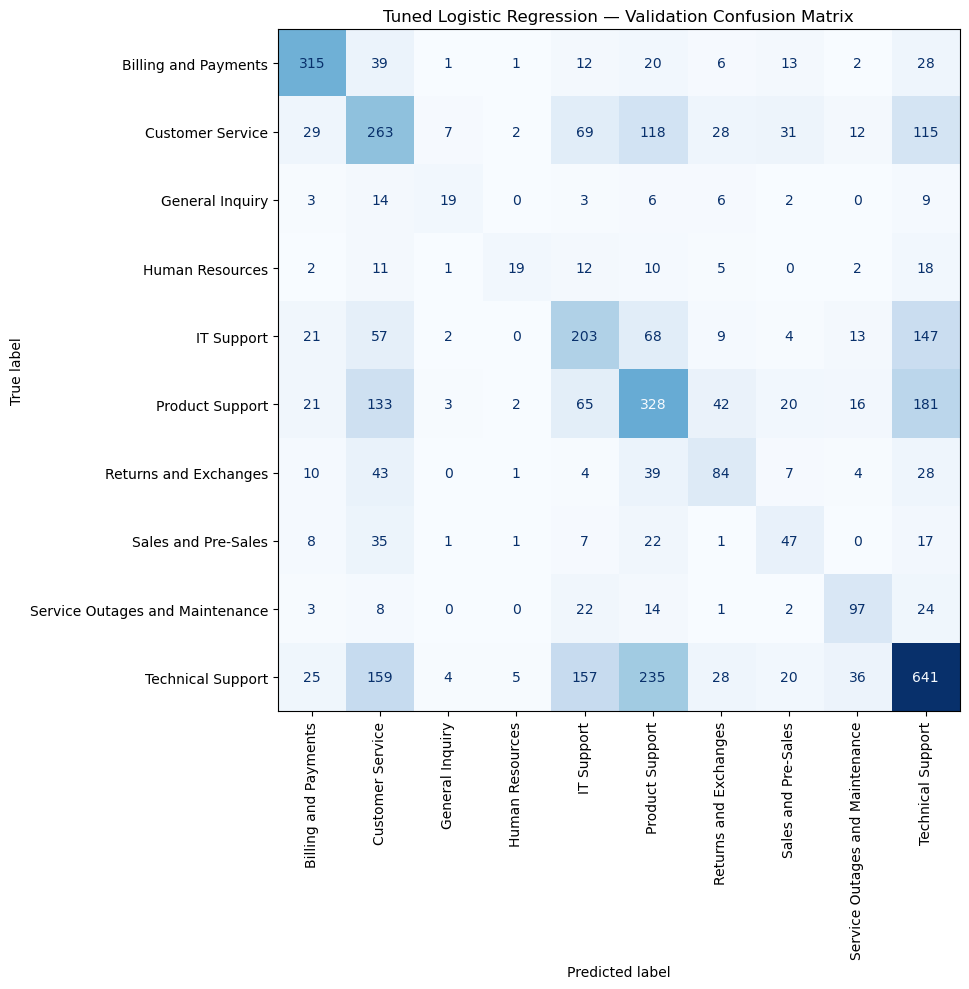

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_predictions = best_text_pipeline.predict(
    validation_df[text_column]
)

# Tuned model results by queue.
best_queue_report = classification_report(
    y_validation,
    best_predictions,
    labels=QUEUE_LABELS,
    output_dict=True,
    zero_division=0
)

best_queue_results = (
    pd.DataFrame(best_queue_report).T
    .loc[QUEUE_LABELS, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score")
)

print("Tuned model — validation results by queue:")
display(best_queue_results.round(4))

# Results by language.
best_validation_results = validation_df[
    ["ticket_id", "language", TARGET_COLUMN]
].copy()
best_validation_results["prediction"] = best_predictions

best_language_rows = []

for language, group in best_validation_results.groupby("language"):
    best_language_rows.append({
        "language": language,
        "tickets": len(group),
        "queues_present": group[TARGET_COLUMN].nunique(),
        "accuracy": accuracy_score(
            group[TARGET_COLUMN], group["prediction"]
        ),
        "macro_f1_10_queues": f1_score(
            group[TARGET_COLUMN],
            group["prediction"],
            labels=QUEUE_LABELS,
            average="macro",
            zero_division=0
        )
    })

best_language_results = pd.DataFrame(best_language_rows)
print("Tuned model — validation results by language:")
display(best_language_results.round(4))

# Rows are actual queues; columns are predicted queues.
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_predictions,
    labels=QUEUE_LABELS,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax
)

ax.set_title("Tuned Logistic Regression — Validation Confusion Matrix")
plt.tight_layout()
plt.show()


In [8]:
import joblib
import sklearn

report_dir = PROJECT_ROOT / "reports" / "model_development"
report_dir.mkdir(parents=True, exist_ok=True)

model_dir = PROJECT_ROOT / "data" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

# Save the model comparisons and validation results.
pd.DataFrame([
    benchmark_metrics,
    lr_metrics,
    text_only_metrics
]).to_csv(report_dir / "initial_comparison.csv", index=False)

tuning_results.to_csv(
    report_dir / "hyperparameter_comparison.csv", index=False
)
best_queue_results.to_csv(
    report_dir / "validation_by_queue.csv", index_label="queue"
)
best_language_results.to_csv(
    report_dir / "validation_by_language.csv", index=False
)

fig.savefig(
    report_dir / "validation_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

# Save the model trained in this notebook.
joblib.dump(
    best_text_pipeline,
    model_dir / "text_logistic_regression.joblib"
)

selected_model_config = {
    "algorithm": "LogisticRegression",
    "input_column": text_column,
    "selection_metric": "validation_macro_f1",
    "C": float(best_text_pipeline["classifier"].C),
    "class_weight": best_text_pipeline["classifier"].class_weight,
    "solver": "lbfgs",
    "max_iter": 2000,
    "random_state": 42,
    "tfidf": {
        "max_features": 30000,
        "ngram_range": [1, 2],
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True
    },
    "sklearn_version": sklearn.__version__,
    "validation_results": tuning_results.iloc[0].to_dict(),
    "feature_datasets": feature_config["datasets"]
}

(report_dir / "selected_model.json").write_text(
    json.dumps(selected_model_config, indent=2),
    encoding="utf-8"
)

project_config["model_development"] = selected_model_config
config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Reports saved:", report_dir)
print("Notebook model saved:", model_dir)


Reports saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/model_development
Notebook model saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/data/models


### Train the selected model in SageMaker


In [9]:
%pip install "sagemaker>=2.250,<3" "scikit-learn==1.7.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.8 MB/s  0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: attrs
    Found existing installation: attrs 26.1.0
    Uninstalling attrs-26.1.0:
      Successfully uninstalled attrs-26.1.0
  Attempting uninstall: sagemaker-corem━━━━━━━━━━━━━━━━━━━━━━ 3/7 [attrs]
    Found existing installation: sagemaker-core 2.20.0━━━━━━━━ 3/7 [attrs]
    Uninstalling sagemaker-core-2.20.0:m━━━━━━━━━━━━━━━━━━━━━━ 3/7 [attrs]
      Successfully uninstalled sagemaker-core-2.20.0━━━━━━━━━━ 3/7 [attrs]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [sagemaker]/7 [sagemaker]core]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sagemaker-studio 1.1.32 requires pymongo-auth-aws>=1.3.0, whi

In [10]:
import sys
import sagemaker
import sklearn
from sagemaker import image_uris

print("Python:", sys.version.split()[0])
print("SageMaker SDK:", sagemaker.__version__)
print("Scikit-learn:", sklearn.__version__)

# List the container versions supported by this SDK.
image_config = image_uris.config_for_framework("sklearn")
image_versions = image_config.get(
    "versions",
    image_config.get("training", {}).get("versions", {})
)

print("Available scikit-learn image versions:", list(image_versions))

for version, details in image_versions.items():
    if version.startswith(("1.4", "1.9")):
        print(version, "Python options:", details.get("py_versions"))


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Python: 3.12.14
SageMaker SDK: 2.257.6
Scikit-learn: 1.7.2
Available scikit-learn image versions: ['0.20.0', '0.23-1', '1.0-1', '1.2-1', '1.4-2']
1.4-2 Python options: ['py3']


In [11]:
from importlib.metadata import version

TRAINING_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_training"
TRAINING_SOURCE_DIR.mkdir(parents=True, exist_ok=True)

# Use the same ML package versions in SageMaker training.
training_packages = [
    "scikit-learn",
    "numpy",
    "scipy",
    "pandas",
    "joblib",
    "threadpoolctl",
]

training_requirements = "\n".join(
    f"{package}=={version(package)}"
    for package in training_packages
) + "\n"

(TRAINING_SOURCE_DIR / "requirements.txt").write_text(
    training_requirements,
    encoding="utf-8"
)

# Save the model settings and dataset hashes.
(TRAINING_SOURCE_DIR / "training_config.json").write_text(
    json.dumps(project_config["model_development"], indent=2),
    encoding="utf-8"
)

print("Training script folder:", TRAINING_SOURCE_DIR)
print("\nTraining package requirements:")
print(training_requirements)


Training script folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/src/ticket_training

Training package requirements:
scikit-learn==1.7.2
numpy==1.26.4
scipy==1.16.3
pandas==2.3.3
joblib==1.5.3
threadpoolctl==3.6.0



In [12]:
%%writefile src/ticket_training/train.py
import hashlib
import json
import os
from importlib.metadata import version
from pathlib import Path

import joblib
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline


def load_verified_data(directory, split_name, config):
    path = Path(directory) / f"{split_name}.csv"
    expected = config["feature_datasets"][split_name]

    fingerprint = hashlib.sha256(path.read_bytes()).hexdigest()
    if fingerprint != expected["sha256"]:
        raise ValueError(f"{split_name}: dataset fingerprint mismatch")

    df = pd.read_csv(
        path,
        dtype={"ticket_id": "string"},
        keep_default_na=False,
    )

    if len(df) != expected["rows"]:
        raise ValueError(f"{split_name}: unexpected row count")
    if not df["ticket_id"].is_unique:
        raise ValueError(f"{split_name}: duplicate ticket IDs")

    return df


def calculate_metrics(actual, predicted, labels):
    return {
        "accuracy": float(accuracy_score(actual, predicted)),
        "macro_f1": float(f1_score(
            actual, predicted,
            labels=labels, average="macro", zero_division=0,
        )),
        "weighted_f1": float(f1_score(
            actual, predicted,
            labels=labels, average="weighted", zero_division=0,
        )),
    }


def main():
    config_path = Path(__file__).with_name("training_config.json")
    config = json.loads(config_path.read_text(encoding="utf-8"))

    train = load_verified_data(
        os.environ["SM_CHANNEL_TRAIN"], "train", config
    )
    validation = load_verified_data(
        os.environ["SM_CHANNEL_VALIDATION"], "validation", config
    )

    if set(train["ticket_id"]) & set(validation["ticket_id"]):
        raise ValueError("Training and validation tickets overlap")

    text_column = config["input_column"]
    labels = sorted(train["queue"].unique())

    if len(labels) != 10:
        raise ValueError("Expected 10 training queues")
    if not set(validation["queue"]).issubset(labels):
        raise ValueError("Validation contains unknown queue labels")

    for name, df in [("train", train), ("validation", validation)]:
        if not df[text_column].str.strip().ne("").all():
            raise ValueError(f"{name}: empty ticket text")

    tfidf_settings = dict(config["tfidf"])
    tfidf_settings["ngram_range"] = tuple(
        tfidf_settings["ngram_range"]
    )

    model = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_settings)),
        ("classifier", LogisticRegression(
            C=config["C"],
            class_weight=config["class_weight"],
            solver=config["solver"],
            max_iter=config["max_iter"],
            random_state=config["random_state"],
        )),
    ])

    print(f"Training on {len(train):,} tickets.", flush=True)
    model.fit(train[text_column], train["queue"])

    predictions = model.predict(validation[text_column])
    metrics = calculate_metrics(
        validation["queue"], predictions, labels
    )

    benchmark = DummyClassifier(strategy="most_frequent")
    benchmark.fit(train[[text_column]], train["queue"])
    benchmark_predictions = benchmark.predict(
        validation[[text_column]]
    )
    benchmark_metrics = calculate_metrics(
        validation["queue"], benchmark_predictions, labels
    )

    model_dir = Path(os.environ["SM_MODEL_DIR"])
    output_dir = Path(os.environ["SM_OUTPUT_DATA_DIR"])
    model_dir.mkdir(parents=True, exist_ok=True)
    output_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(model, model_dir / "model.joblib")

    report = {
        "evaluation_split": "validation",
        "model": metrics,
        "benchmark": benchmark_metrics,
        "training_rows": len(train),
        "validation_rows": len(validation),
        "solver_iterations": int(
            model["classifier"].n_iter_.max()
        ),
    }
    (output_dir / "evaluation.json").write_text(
        json.dumps(report, indent=2), encoding="utf-8"
    )

    queue_report = classification_report(
        validation["queue"], predictions,
        labels=labels, output_dict=True, zero_division=0,
    )
    pd.DataFrame(queue_report).T.to_csv(
        output_dir / "validation_by_queue.csv",
        index_label="queue",
    )

    language_rows = []
    evaluation_rows = validation[["language", "queue"]].copy()
    evaluation_rows["prediction"] = predictions

    for language, group in evaluation_rows.groupby("language"):
        language_rows.append({
            "language": language,
            "tickets": len(group),
            "queues_present": group["queue"].nunique(),
            **calculate_metrics(
                group["queue"], group["prediction"], labels
            ),
        })

    pd.DataFrame(language_rows).to_csv(
        output_dir / "validation_by_language.csv", index=False
    )

    pd.DataFrame(
        confusion_matrix(
            validation["queue"], predictions, labels=labels
        ),
        index=labels,
        columns=labels,
    ).to_csv(
        output_dir / "validation_confusion_matrix.csv",
        index_label="actual_queue",
    )

    metadata = {
        "configuration": config,
        "queue_labels": labels,
        "packages": {
            name: version(name)
            for name in [
                "scikit-learn", "numpy", "scipy",
                "pandas", "joblib", "threadpoolctl",
            ]
        },
    }
    (model_dir / "model_metadata.json").write_text(
        json.dumps(metadata, indent=2), encoding="utf-8"
    )

    for metric_name, value in metrics.items():
        print(f"validation:{metric_name}={value:.8f}", flush=True)

    print("Model and validation reports saved.", flush=True)


if __name__ == "__main__":
    main()

Writing src/ticket_training/train.py


In [13]:
from sagemaker.sklearn.estimator import SKLearn
from sagemaker.inputs import TrainingInput

# Check the script's Python syntax without running training.
script_path = TRAINING_SOURCE_DIR / "train.py"
compile(
    script_path.read_text(encoding="utf-8"),
    str(script_path),
    "exec"
)

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

sagemaker_session = sagemaker.Session(
    boto_session=aws_session,
    default_bucket=PROJECT_BUCKET
)

# Select the Python 3.12 training image for this AWS region.
base_image_uri = image_uris.retrieve(
    framework="sklearn",
    region=AWS_REGION,
    version="1.4-2",
    py_version="py3",
    instance_type="ml.m5.xlarge",
    image_scope="training"
)

TRAINING_IMAGE_URI = (
    base_image_uri.rsplit(":", 1)[0]
    + ":1.4-2-py312-cpu-py3"
)

training_estimator = SKLearn(
    entry_point="train.py",
    source_dir=str(TRAINING_SOURCE_DIR),
    framework_version="1.4-2",
    py_version="py3",
    image_uri=TRAINING_IMAGE_URI,
    role=project_config["feature_store"]["execution_role_arn"],
    instance_count=1,
    instance_type="ml.m5.xlarge",
    volume_size=20,
    max_run=900,
    output_path=f"s3://{PROJECT_BUCKET}/training-output/",
    code_location=f"s3://{PROJECT_BUCKET}/training-code/",
    sagemaker_session=sagemaker_session,
    disable_profiler=True,
    debugger_hook_config=False,
    metric_definitions=[
        {
            "Name": f"validation:{metric}",
            "Regex": rf"validation:{metric}=([0-9.]+)"
        }
        for metric in ["accuracy", "macro_f1", "weighted_f1"]
    ]
)

training_inputs = {
    name: TrainingInput(
        s3_data=feature_config["datasets"][name]["uri"],
        content_type="text/csv",
        input_mode="File"
    )
    for name in ["train", "validation"]
}

print("Training image:", TRAINING_IMAGE_URI)
print("Compute: one ml.m5.xlarge instance")
print("Maximum training runtime: 15 minutes")


/opt/conda/lib/python3.12/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: SKLearn is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
SKLearn is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Training image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.4-2-py312-cpu-py3
Compute: one ml.m5.xlarge instance
Maximum training runtime: 15 minutes


In [14]:
from datetime import datetime, timezone

# Check for a saved job before starting another one.
if project_config.get("managed_training", {}).get("job_name"):
    raise RuntimeError(
        "A training job is already recorded. Check its status "
        "before launching another one."
    )

training_job_name = (
    "aai540-group3-lr-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

# Save the job name before starting training.
project_config["managed_training"] = {
    "job_name": training_job_name,
    "image_uri": TRAINING_IMAGE_URI,
    "instance_type": "ml.m5.xlarge",
    "sdk_version": sagemaker.__version__,
    "source_sha256": {
        filename: hashlib.sha256(
            (TRAINING_SOURCE_DIR / filename).read_bytes()
        ).hexdigest()
        for filename in [
            "train.py", "requirements.txt", "training_config.json"
        ]
    }
}

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

training_estimator.fit(
    inputs=training_inputs,
    job_name=training_job_name,
    wait=False
)

sagemaker_client = aws_session.client("sagemaker")
job_details = sagemaker_client.describe_training_job(
    TrainingJobName=training_job_name
)

print("Job name:", training_job_name)
print("Status:", job_details["TrainingJobStatus"])
print("Stage:", job_details.get("SecondaryStatus"))


INFO:sagemaker:Creating training-job with name: aai540-group3-lr-20261004-003353


Job name: aai540-group3-lr-20261004-003353
Status: InProgress
Stage: Starting


In [15]:
training_job_name = project_config["managed_training"]["job_name"]

job_details = aws_session.client("sagemaker").describe_training_job(
    TrainingJobName=training_job_name
)

status = job_details["TrainingJobStatus"]

print("Job:", training_job_name)
print("Current status:", status)
print("Current stage:", job_details.get("SecondaryStatus"))

if status == "Completed":
    print("Training seconds:", job_details.get("TrainingTimeInSeconds"))
    print("Model location:", job_details["ModelArtifacts"]["S3ModelArtifacts"])

    for metric in job_details.get("FinalMetricDataList", []):
        print(f"{metric['MetricName']}: {metric['Value']:.4f}")

elif status == "Failed":
    print("Failure reason:", job_details.get("FailureReason"))

else:
    transitions = job_details.get("SecondaryStatusTransitions", [])
    if transitions:
        print("Latest update:", transitions[-1].get("StatusMessage"))


Job: aai540-group3-lr-20261004-003353
Current status: Completed
Current stage: Completed
Training seconds: 119
Model location: s3://aai540-group3-tickets-390568313988-us-east-1/training-output/aai540-group3-lr-20261004-003353/output/model.tar.gz
validation:weighted_f1: 0.4569
validation:macro_f1: 0.4362
validation:accuracy: 0.4557


In [16]:
import tarfile

model_uri = job_details["ModelArtifacts"]["S3ModelArtifacts"]
output_uri = model_uri.rsplit("/", 1)[0] + "/output.tar.gz"

def read_s3_archive(uri):
    location = urlparse(uri)
    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/")
    )
    try:
        return response["Body"].read(), response.get("VersionId")
    finally:
        response["Body"].close()

def read_archive_member(archive_bytes, filename):
    # Read one file from the archive without unpacking it.
    with tarfile.open(fileobj=BytesIO(archive_bytes), mode="r:gz") as archive:
        matches = [
            member for member in archive.getmembers()
            if member.isfile() and Path(member.name).name == filename
        ]
        if len(matches) != 1:
            raise ValueError(f"Expected exactly one {filename} in archive")
        with archive.extractfile(matches[0]) as member_file:
            return member_file.read()

managed_model_archive, model_version = read_s3_archive(model_uri)
managed_output_archive, output_version = read_s3_archive(output_uri)

managed_evaluation = json.loads(
    read_archive_member(managed_output_archive, "evaluation.json")
)
managed_metadata = json.loads(
    read_archive_member(managed_model_archive, "model_metadata.json")
)

managed_report_dir = PROJECT_ROOT / "reports" / "managed_training"
managed_report_dir.mkdir(parents=True, exist_ok=True)

for filename, contents in [
    ("evaluation.json", managed_evaluation),
    ("model_metadata.json", managed_metadata),
]:
    (managed_report_dir / filename).write_text(
        json.dumps(contents, indent=2),
        encoding="utf-8"
    )

project_config["managed_training"].update({
    "status": job_details["TrainingJobStatus"],
    "model_uri": model_uri,
    "model_version_id": model_version,
    "output_uri": output_uri,
    "output_version_id": output_version,
    "training_seconds": job_details["TrainingTimeInSeconds"],
    "validation_metrics": managed_evaluation["model"],
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Managed training evaluation:")
print(json.dumps(managed_evaluation, indent=2))
print("\nPackages used by the training job:")
print(json.dumps(managed_metadata["packages"], indent=2))


Managed training evaluation:
{
  "evaluation_split": "validation",
  "model": {
    "accuracy": 0.45573622402890696,
    "macro_f1": 0.43616079833313764,
    "weighted_f1": 0.4569255989374723
  },
  "benchmark": {
    "accuracy": 0.2958446251129178,
    "macro_f1": 0.04566050888811433,
    "weighted_f1": 0.13508416134469234
  },
  "training_rows": 17710,
  "validation_rows": 4428,
  "solver_iterations": 229
}

Packages used by the training job:
{
  "scikit-learn": "1.7.2",
  "numpy": "1.26.4",
  "scipy": "1.16.3",
  "pandas": "2.3.3",
  "joblib": "1.5.3",
  "threadpoolctl": "3.6.0"
}



### Evaluate on the test data


In [17]:
# Load the model from the completed training job.
managed_model = joblib.load(BytesIO(
    read_archive_member(managed_model_archive, "model.joblib")
))

assert managed_metadata["configuration"] == (
    project_config["model_development"]
)

# Save our model choice before checking the test scores.
project_config["final_model"] = {
    "training_job_name": project_config["managed_training"]["job_name"],
    "model_uri": model_uri,
    "model_version_id": model_version,
    "model_archive_sha256": hashlib.sha256(
        managed_model_archive
    ).hexdigest(),
    "selection_metric": "validation_macro_f1",
}

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

# Load the saved test dataset version.
test_info = project_config["s3_data"]["test"]
test_location = urlparse(test_info["uri"])

response = s3_client.get_object(
    Bucket=test_location.netloc,
    Key=test_location.path.lstrip("/"),
    VersionId=test_info["version_id"]
)
try:
    test_df = pd.read_csv(
        response["Body"],
        dtype={"ticket_id": "string"},
        low_memory=False
    )
finally:
    response["Body"].close()

assert len(test_df) == 4428
assert test_df["ticket_id"].is_unique
assert not set(test_df["ticket_id"]) & set(train_df["ticket_id"])
assert not set(test_df["ticket_id"]) & set(validation_df["ticket_id"])

# Apply the same text preparation used for training.
test_text = (
    test_df["subject"].fillna("").astype(str).str.strip()
    + " "
    + test_df["body"].fillna("").astype(str).str.strip()
).str.strip()

assert test_text.str.len().gt(0).all()

test_predictions = managed_model.predict(test_text)
y_test = test_df[TARGET_COLUMN]

# Choose the benchmark queue from training data only.
majority_queue = y_train.value_counts().idxmax()
test_benchmark_predictions = [majority_queue] * len(test_df)

test_metric_rows = []

for name, predictions in [
    ("Majority-class benchmark", test_benchmark_predictions),
    ("Managed Logistic Regression", test_predictions),
]:
    test_metric_rows.append({
        "model": name,
        "evaluation_split": "test",
        "accuracy": accuracy_score(y_test, predictions),
        "macro_f1": f1_score(
            y_test, predictions,
            labels=QUEUE_LABELS, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_test, predictions,
            labels=QUEUE_LABELS, average="weighted", zero_division=0
        )
    })

test_metrics = pd.DataFrame(test_metric_rows)

print("Test tickets evaluated:", len(test_df))
display(test_metrics.round(4))


Test tickets evaluated: 4428


,model,evaluation_split,accuracy,macro_f1,weighted_f1
0,Majority-class benchmark,test,0.2956,0.0456,0.1349
1,Managed Logistic Regression,test,0.4634,0.4464,0.4653


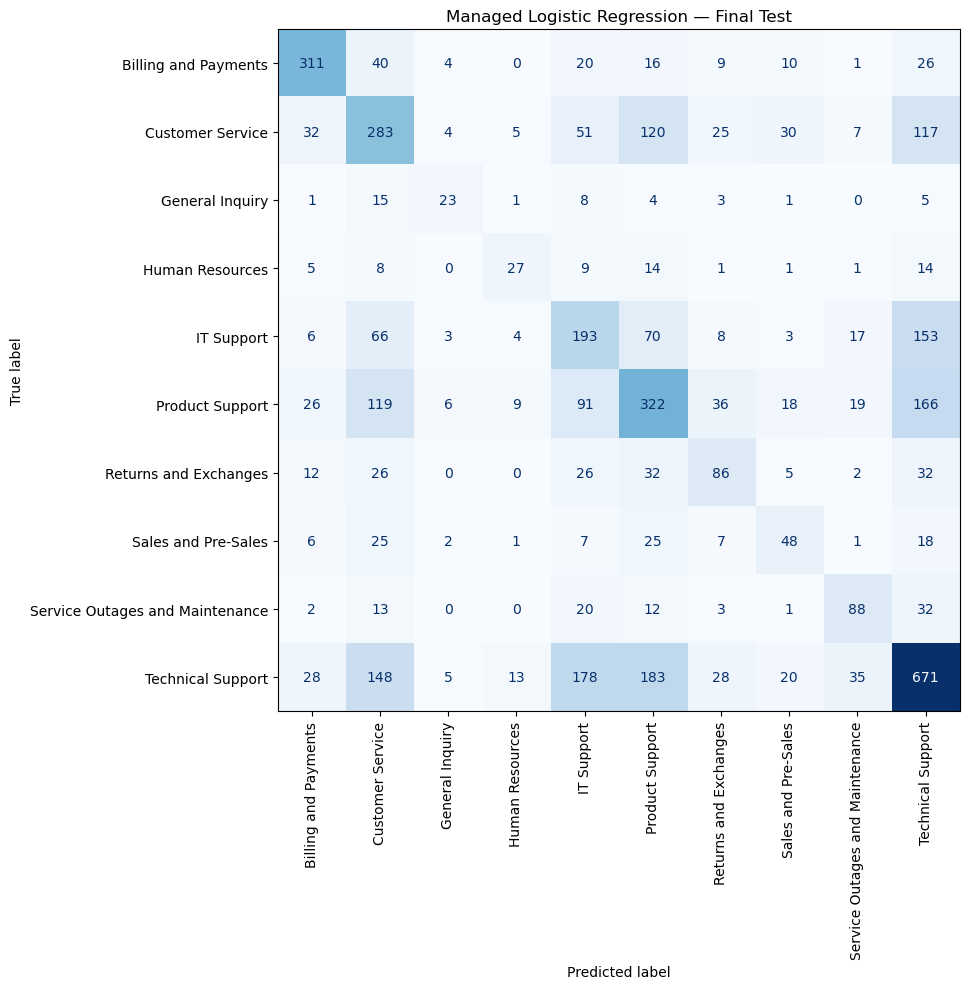

Final test reports saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/final_test


,language,tickets,queues_present,accuracy,macro_f1_10_queues
0,de,1720,10,0.4023,0.3410
1,en,2555,10,0.5029,0.5148
2,es,82,10,0.5000,0.3837
3,fr,39,9,0.5128,0.3591
4,pt,32,8,0.4375,0.3738


In [18]:
test_report_dir = PROJECT_ROOT / "reports" / "final_test"
test_report_dir.mkdir(parents=True, exist_ok=True)

test_metrics.to_csv(
    test_report_dir / "metrics.csv", index=False
)

# Results by queue.
test_queue_report = classification_report(
    y_test,
    test_predictions,
    labels=QUEUE_LABELS,
    output_dict=True,
    zero_division=0
)

test_queue_results = (
    pd.DataFrame(test_queue_report).T
    .loc[QUEUE_LABELS, ["precision", "recall", "f1-score", "support"]]
)

test_queue_results.to_csv(
    test_report_dir / "by_queue.csv", index_label="queue"
)

# Results by language.
test_results = test_df[
    ["ticket_id", "language", TARGET_COLUMN]
].copy()
test_results["prediction"] = test_predictions

test_language_rows = []

for language, group in test_results.groupby("language"):
    test_language_rows.append({
        "language": language,
        "tickets": len(group),
        "queues_present": group[TARGET_COLUMN].nunique(),
        "accuracy": accuracy_score(
            group[TARGET_COLUMN], group["prediction"]
        ),
        "macro_f1_10_queues": f1_score(
            group[TARGET_COLUMN],
            group["prediction"],
            labels=QUEUE_LABELS,
            average="macro",
            zero_division=0
        )
    })

test_language_results = pd.DataFrame(test_language_rows)
test_language_results.to_csv(
    test_report_dir / "by_language.csv", index=False
)

test_fig, test_ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=QUEUE_LABELS,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=test_ax
)

test_ax.set_title("Managed Logistic Regression — Final Test")
test_fig.tight_layout()
test_fig.savefig(
    test_report_dir / "confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# Save each test prediction for later review.
prediction_dir = PROJECT_ROOT / "data" / "predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)
test_results.to_csv(prediction_dir / "test_predictions.csv", index=False)

project_config["final_model"].update({
    "test_dataset": test_info,
    "test_rows": len(test_df),
    "test_metrics": test_metric_rows[1],
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Final test reports saved:", test_report_dir)
display(test_language_results.round(4))


<a id="section-7"></a>
## 7. Batch predictions

We prepared the prediction code and used SageMaker Batch Transform to predict the queues for 17,712 tickets. These were the tickets we had set aside to act as new production data.

We checked that every ticket received exactly one prediction and that all predictions came from our selected model.

After the predictions were complete, we matched them with the correct queue labels, which we had saved separately. This allowed us to measure how well the model performed on these tickets.

For this step, we used the model we had already trained and tested. We created another model version later in the automated pipeline.

**Original notebook:** [model_deployment.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/9480386/model_deployment.ipynb)

The cells below show the batch prediction process and its saved results.


In [2]:
from pathlib import Path
from urllib.parse import urlparse
import json
import boto3
import pandas as pd

PROJECT_ROOT = Path.cwd()
config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

aws_session = boto3.Session(region_name=AWS_REGION)
s3_client = aws_session.client("s3")
sagemaker_client = aws_session.client("sagemaker")

# Load production inputs only; their labels remain separate.
production_info = project_config["s3_data"]["production"]
location = urlparse(production_info["uri"])

response = s3_client.get_object(
    Bucket=location.netloc,
    Key=location.path.lstrip("/"),
    VersionId=production_info["version_id"]
)
try:
    production_df = pd.read_csv(
        response["Body"],
        dtype={"ticket_id": "string"},
        low_memory=False
    )
finally:
    response["Body"].close()

assert len(production_df) == 17712
assert production_df["ticket_id"].notna().all()
assert production_df["ticket_id"].is_unique
assert "queue" not in production_df.columns

print("Production tickets:", len(production_df))
print("Columns:", production_df.columns.tolist())
print("Selected model:", project_config["final_model"]["training_job_name"])


Production tickets: 17712
Columns: ['ticket_id', 'subject', 'body', 'language', 'priority', 'type']
Selected model: aai540-group3-lr-20261004-003353


In [2]:
import hashlib
import shutil

INFERENCE_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_inference"
INFERENCE_SOURCE_DIR.mkdir(parents=True, exist_ok=True)

# Use the same package versions as training.
shutil.copyfile(
    PROJECT_ROOT / "src" / "ticket_training" / "requirements.txt",
    INFERENCE_SOURCE_DIR / "requirements.txt"
)

batch_dir = PROJECT_ROOT / "data" / "batch"
batch_dir.mkdir(parents=True, exist_ok=True)
batch_input_path = batch_dir / "production.jsonl"

# Include only the fields needed for prediction and monitoring.
input_columns = ["ticket_id", "subject", "body", "language"]
batch_records = (
    production_df[input_columns]
    .fillna("")
    .to_dict("records")
)

largest_record_bytes = 0

with batch_input_path.open("w", encoding="utf-8") as file:
    for record in batch_records:
        line = json.dumps(
            record, ensure_ascii=False, allow_nan=False
        ) + "\n"
        largest_record_bytes = max(
            largest_record_bytes, len(line.encode("utf-8"))
        )
        file.write(line)

# Keep each record below the 1 MB request limit.
assert largest_record_bytes < 1_000_000

model_job_name = project_config["final_model"]["training_job_name"]
batch_input_key = f"batch/{model_job_name}/input/production.jsonl"

s3_client.upload_file(
    str(batch_input_path), PROJECT_BUCKET, batch_input_key
)

metadata = s3_client.head_object(
    Bucket=PROJECT_BUCKET,
    Key=batch_input_key
)
assert metadata["ContentLength"] == batch_input_path.stat().st_size
assert metadata.get("VersionId") not in (None, "null")

project_config.setdefault("deployment", {}).update({
    "mode": "batch_transform",
    "input": {
        "uri": f"s3://{PROJECT_BUCKET}/{batch_input_key}",
        "version_id": metadata["VersionId"],
        "sha256": hashlib.sha256(
            batch_input_path.read_bytes()
        ).hexdigest(),
        "rows": len(batch_records)
    }
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Production records prepared:", len(batch_records))
print("Largest record:", largest_record_bytes, "bytes")
print("Batch input uploaded:", project_config["deployment"]["input"]["uri"])
print("Inference script folder:", INFERENCE_SOURCE_DIR)


Production records prepared: 17712
Largest record: 2994 bytes
Batch input uploaded: s3://aai540-group3-tickets-390568313988-us-east-1/batch/aai540-group3-lr-20261004-003353/input/production.jsonl
Inference script folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/src/ticket_inference


In [1]:
%%writefile src/ticket_inference/inference.py
import hashlib
import json
from pathlib import Path

import joblib


CONTENT_TYPE = "application/jsonlines"


def model_fn(model_dir):
    """Load the trained pipeline once when the prediction server starts."""
    model_path = Path(model_dir) / "model.joblib"

    return {
        "pipeline": joblib.load(model_path),
        "model_sha256": hashlib.sha256(
            model_path.read_bytes()
        ).hexdigest(),
    }


def input_fn(request_body, content_type):
    """Read one or more JSON Lines ticket records."""
    media_type = content_type.split(";", 1)[0].strip().lower()
    if media_type != CONTENT_TYPE:
        raise ValueError(f"Expected {CONTENT_TYPE}")

    if isinstance(request_body, bytes):
        request_body = request_body.decode("utf-8")

    records = [
        json.loads(line)
        for line in request_body.splitlines()
        if line.strip()
    ]

    if not records:
        raise ValueError("No ticket records provided")

    required_fields = {"ticket_id", "subject", "body", "language"}

    for record in records:
        if not isinstance(record, dict):
            raise ValueError("Each ticket must be a JSON object")

        if not required_fields.issubset(record):
            raise ValueError("A ticket is missing required fields")

        if "queue" in record:
            raise ValueError("Prediction inputs must not contain queue labels")

        if not isinstance(record["ticket_id"], str):
            raise ValueError("ticket_id must be a string")
        if not record["ticket_id"].strip():
            raise ValueError("ticket_id must not be empty")

        for field in ["subject", "body", "language"]:
            value = record[field]
            if value is not None and not isinstance(value, str):
                raise ValueError(f"{field} must be a string or null")

    return records


def predict_fn(records, model):
    """Apply the same text preparation used during training."""
    subjects = [(record["subject"] or "").strip() for record in records]
    bodies = [(record["body"] or "").strip() for record in records]

    texts = [
        (subject + " " + body).strip()
        for subject, body in zip(subjects, bodies)
    ]

    if any(not text for text in texts):
        raise ValueError("Each ticket needs a nonempty subject or body")

    pipeline = model["pipeline"]
    probabilities = pipeline.predict_proba(texts)
    classes = pipeline.classes_
    winning_indices = probabilities.argmax(axis=1)

    results = []

    for index, record in enumerate(records):
        winning_index = int(winning_indices[index])
        subject = subjects[index]
        body = bodies[index]
        text = texts[index]

        results.append({
            "ticket_id": record["ticket_id"],
            "language": (
                (record["language"] or "").strip().lower() or "unknown"
            ),
            "predicted_queue": str(classes[winning_index]),
            "max_probability": float(
                probabilities[index, winning_index]
            ),
            "has_subject": int(bool(subject)),
            "subject_char_count": len(subject),
            "body_char_count": len(body),
            "text_char_count": len(text),
            "subject_word_count": len(subject.split()),
            "body_word_count": len(body.split()),
            "text_word_count": len(text.split()),
            "model_sha256": model["model_sha256"],
        })

    return results


def output_fn(predictions, accept):
    """Return one JSON line per ticket, preserving input order."""
    media_type = accept.split(";", 1)[0].strip().lower()
    if media_type != CONTENT_TYPE:
        raise ValueError(f"Expected response type {CONTENT_TYPE}")

    response_body = "\n".join(
        json.dumps(record, ensure_ascii=False, allow_nan=False)
        for record in predictions
    )

    return response_body, CONTENT_TYPE

Writing src/ticket_inference/inference.py


In [3]:
import hashlib
import importlib.util
import tarfile
from io import BytesIO

final_model_info = project_config["final_model"]
model_location = urlparse(final_model_info["model_uri"])

response = s3_client.get_object(
    Bucket=model_location.netloc,
    Key=model_location.path.lstrip("/"),
    VersionId=final_model_info["model_version_id"]
)
try:
    model_archive_bytes = response["Body"].read()
finally:
    response["Body"].close()

assert hashlib.sha256(model_archive_bytes).hexdigest() == (
    final_model_info["model_archive_sha256"]
)

# Read only model.joblib from the archive.
local_model_dir = PROJECT_ROOT / "data" / "deployment" / "model"
local_model_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(
    fileobj=BytesIO(model_archive_bytes), mode="r:gz"
) as archive:
    matches = [
        member for member in archive.getmembers()
        if member.isfile() and Path(member.name).name == "model.joblib"
    ]
    assert len(matches) == 1

    with archive.extractfile(matches[0]) as model_file:
        (local_model_dir / "model.joblib").write_bytes(model_file.read())

inference_path = PROJECT_ROOT / "src" / "ticket_inference" / "inference.py"

spec = importlib.util.spec_from_file_location(
    "ticket_inference", inference_path
)
inference_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(inference_module)

serving_model = inference_module.model_fn(str(local_model_dir))

# Use one ticket from each production language.
sample_records = (
    production_df.groupby("language", sort=False)
    .head(1)[["ticket_id", "subject", "body", "language"]]
    .fillna("")
    .to_dict("records")
)

sample_request = "\n".join(
    json.dumps(record, ensure_ascii=False, allow_nan=False)
    for record in sample_records
)

parsed_records = inference_module.input_fn(
    sample_request, "application/jsonlines"
)
sample_predictions = inference_module.predict_fn(
    parsed_records, serving_model
)
response_body, response_type = inference_module.output_fn(
    sample_predictions, "application/jsonlines"
)

returned_records = [
    json.loads(line) for line in response_body.splitlines()
]

assert response_type == "application/jsonlines"
assert [r["ticket_id"] for r in returned_records] == [
    r["ticket_id"] for r in sample_records
]
assert all(
    r["predicted_queue"] in serving_model["pipeline"].classes_
    and 0.0 <= r["max_probability"] <= 1.0
    for r in returned_records
)

display(
    pd.DataFrame(returned_records)[
        ["language", "predicted_queue", "max_probability"]
    ].round(4)
)


,language,predicted_queue,max_probability
0,de,Technical Support,0.3737
1,en,Sales and Pre-Sales,0.2569
2,fr,IT Support,0.2941
3,pt,IT Support,0.3857
4,es,Product Support,0.2375


In [4]:
import sagemaker
from sagemaker.sklearn.model import SKLearnModel

INFERENCE_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_inference"

sagemaker_session = sagemaker.Session(
    boto_session=aws_session,
    default_bucket=PROJECT_BUCKET
)

# Check that the S3 model version has not changed.
model_location = urlparse(project_config["final_model"]["model_uri"])
model_head = s3_client.head_object(
    Bucket=model_location.netloc,
    Key=model_location.path.lstrip("/")
)
assert model_head["VersionId"] == (
    project_config["final_model"]["model_version_id"]
)

# Make an ID from the model and prediction-code hashes.
inference_source_hashes = {
    filename: hashlib.sha256(
        (INFERENCE_SOURCE_DIR / filename).read_bytes()
    ).hexdigest()
    for filename in ["inference.py", "requirements.txt"]
}

deployment_id = hashlib.sha256(
    (
        project_config["final_model"]["model_archive_sha256"]
        + json.dumps(inference_source_hashes, sort_keys=True)
    ).encode("utf-8")
).hexdigest()[:12]

batch_model_name = f"aai540-group3-routing-{deployment_id}"
batch_output_uri = (
    f"s3://{PROJECT_BUCKET}/batch/{deployment_id}/predictions/"
)

batch_model = SKLearnModel(
    name=batch_model_name,
    model_data=project_config["final_model"]["model_uri"],
    role=project_config["feature_store"]["execution_role_arn"],
    entry_point="inference.py",
    source_dir=str(INFERENCE_SOURCE_DIR),
    framework_version="1.4-2",
    py_version="py3",
    image_uri=project_config["managed_training"]["image_uri"],
    model_server_workers=1,
    sagemaker_session=sagemaker_session
)

batch_transformer = batch_model.transformer(
    instance_count=1,
    instance_type="ml.m5.xlarge",
    strategy="MultiRecord",
    assemble_with="Line",
    accept="application/jsonlines",
    max_payload=1,
    max_concurrent_transforms=1,
    output_path=batch_output_uri
)

project_config["deployment"].update({
    "model_name": batch_model_name,
    "deployment_id": deployment_id,
    "output_uri": batch_output_uri,
    "inference_source_sha256": inference_source_hashes,
    "instance_type": "ml.m5.xlarge"
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("SageMaker model:", batch_model_name)
print("Prediction output:", batch_output_uri)


/opt/conda/lib/python3.12/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: SKLearnModel is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
SKLearnModel is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
/opt/conda/lib/python3.12/site-packages/sagemaker/transformer.py:115: SageMakerV2DeprecationWarning: Transformer is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `sagemaker.core.shapes.TransformJob`.
See https://g

SageMaker model: aai540-group3-routing-ce725539a788
Prediction output: s3://aai540-group3-tickets-390568313988-us-east-1/batch/ce725539a788/predictions/


In [5]:
from datetime import datetime, timezone
from sagemaker.inputs import BatchDataCaptureConfig

deployment = project_config["deployment"]

# Check for a saved batch job before starting another one.
if deployment.get("job_name"):
    raise RuntimeError(
        "A batch job is already recorded. Check its status "
        "before submitting another job."
    )

# Check the input file's S3 version.
input_location = urlparse(deployment["input"]["uri"])
input_head = s3_client.head_object(
    Bucket=input_location.netloc,
    Key=input_location.path.lstrip("/")
)
assert input_head["VersionId"] == deployment["input"]["version_id"]

batch_job_name = (
    "aai540-group3-batch-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)

capture_uri = (
    f"s3://{PROJECT_BUCKET}/batch/"
    f"{deployment['deployment_id']}/capture/"
)

# Save the job name before starting predictions.
deployment.update({
    "job_name": batch_job_name,
    "capture_uri": capture_uri
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

batch_transformer.transform(
    data=deployment["input"]["uri"],
    data_type="S3Prefix",
    content_type="application/jsonlines",
    split_type="Line",
    job_name=batch_job_name,
    batch_data_capture_config=BatchDataCaptureConfig(
        destination_s3_uri=capture_uri,
        generate_inference_id=False
    ),
    model_client_config={
        "InvocationsTimeoutInSeconds": 120,
        "InvocationsMaxRetries": 2
    },
    wait=False,
    logs=False
)

batch_details = sagemaker_client.describe_transform_job(
    TransformJobName=batch_job_name
)

print("Batch job:", batch_job_name)
print("Status:", batch_details["TransformJobStatus"])
print("Prediction output:", deployment["output_uri"])


INFO:sagemaker:Creating transform job with name: aai540-group3-batch-20261004-045734


Batch job: aai540-group3-batch-20261004-045734
Status: InProgress
Prediction output: s3://aai540-group3-tickets-390568313988-us-east-1/batch/ce725539a788/predictions/


In [7]:
batch_job_name = project_config["deployment"]["job_name"]

batch_details = sagemaker_client.describe_transform_job(
    TransformJobName=batch_job_name
)

status = batch_details["TransformJobStatus"]

print("Batch job:", batch_job_name)
print("Current status:", status)

if status == "Completed":
    print(
        "Predictions saved:",
        batch_details["TransformOutput"]["S3OutputPath"]
    )
elif status == "Failed":
    print("Failure reason:", batch_details.get("FailureReason"))
else:
    print("The job has not finished yet.")


Batch job: aai540-group3-batch-20261004-045734
Current status: Completed
Predictions saved: s3://aai540-group3-tickets-390568313988-us-east-1/batch/ce725539a788/predictions/


In [8]:
output_location = urlparse(
    batch_details["TransformOutput"]["S3OutputPath"]
)

output_keys = []
paginator = s3_client.get_paginator("list_objects_v2")

for page in paginator.paginate(
    Bucket=output_location.netloc,
    Prefix=output_location.path.lstrip("/")
):
    output_keys.extend(
        item["Key"]
        for item in page.get("Contents", [])
        if item["Key"].endswith(".out")
    )

if not output_keys:
    raise RuntimeError("No batch prediction output files were found.")

prediction_records = []
prediction_artifacts = []

for key in sorted(output_keys):
    response = s3_client.get_object(
        Bucket=output_location.netloc,
        Key=key
    )
    try:
        content = response["Body"].read()
    finally:
        response["Body"].close()

    prediction_records.extend(
        json.loads(line)
        for line in content.decode("utf-8").splitlines()
        if line.strip()
    )

    prediction_artifacts.append({
        "uri": f"s3://{output_location.netloc}/{key}",
        "version_id": response.get("VersionId"),
        "sha256": hashlib.sha256(content).hexdigest()
    })

production_predictions = pd.DataFrame(prediction_records)

# Check ticket IDs, predicted queues, probabilities, and model hash.
assert len(production_predictions) == len(production_df)
assert production_predictions["ticket_id"].is_unique
assert set(production_predictions["ticket_id"]) == set(
    production_df["ticket_id"]
)
assert production_predictions["predicted_queue"].isin(
    serving_model["pipeline"].classes_
).all()
assert production_predictions["max_probability"].between(0, 1).all()
assert production_predictions["model_sha256"].eq(
    serving_model["model_sha256"]
).all()

prediction_dir = PROJECT_ROOT / "data" / "predictions"
prediction_dir.mkdir(parents=True, exist_ok=True)

production_predictions.to_csv(
    prediction_dir / "production_predictions.csv",
    index=False
)

project_config["deployment"].update({
    "status": batch_details["TransformJobStatus"],
    "prediction_count": len(production_predictions),
    "prediction_artifacts": prediction_artifacts
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Predictions verified:", len(production_predictions))
print("\nPredicted tickets per queue:")
print(production_predictions["predicted_queue"].value_counts())


Predictions verified: 17712

Predicted tickets per queue:
predicted_queue
Technical Support                  5039
Product Support                    3258
Customer Service                   3088
IT Support                         2269
Billing and Payments               1668
Returns and Exchanges               828
Service Outages and Maintenance     668
Sales and Pre-Sales                 586
Human Resources                     178
General Inquiry                     130
Name: count, dtype: int64


In [9]:
from sklearn.metrics import accuracy_score, f1_score

# Load the correct queue labels after predictions are complete.
labels_info = project_config["s3_data"]["production_labels"]
labels_location = urlparse(labels_info["uri"])

response = s3_client.get_object(
    Bucket=labels_location.netloc,
    Key=labels_location.path.lstrip("/"),
    VersionId=labels_info["version_id"]
)
try:
    production_labels = pd.read_csv(
        response["Body"],
        dtype={"ticket_id": "string"}
    )
finally:
    response["Body"].close()

assert production_labels["ticket_id"].is_unique
assert production_labels["queue"].notna().all()
assert set(production_labels["ticket_id"]) == set(
    production_predictions["ticket_id"]
)

# Match labels and predictions by ticket ID, not row position.
production_evaluation = production_predictions.merge(
    production_labels[["ticket_id", "queue"]],
    on="ticket_id",
    how="inner",
    validate="one_to_one"
)

queue_labels = serving_model["pipeline"].classes_.tolist()
assert production_evaluation["queue"].isin(queue_labels).all()

production_metrics = {
    "evaluation_split": "simulated_production",
    "tickets": len(production_evaluation),
    "accuracy": float(accuracy_score(
        production_evaluation["queue"],
        production_evaluation["predicted_queue"]
    )),
    "macro_f1": float(f1_score(
        production_evaluation["queue"],
        production_evaluation["predicted_queue"],
        labels=queue_labels,
        average="macro",
        zero_division=0
    )),
    "weighted_f1": float(f1_score(
        production_evaluation["queue"],
        production_evaluation["predicted_queue"],
        labels=queue_labels,
        average="weighted",
        zero_division=0
    ))
}

monitoring_report_dir = PROJECT_ROOT / "reports" / "monitoring"
monitoring_report_dir.mkdir(parents=True, exist_ok=True)

production_report = {
    "batch_job_name": project_config["deployment"]["job_name"],
    "ground_truth_source": labels_info,
    "metrics": production_metrics
}

(monitoring_report_dir / "production_quality.json").write_text(
    json.dumps(production_report, indent=2),
    encoding="utf-8"
)

production_evaluation.to_csv(
    prediction_dir / "production_evaluation.csv",
    index=False
)

print("Production labels matched:", len(production_evaluation))
display(pd.DataFrame([
    project_config["final_model"]["test_metrics"],
    production_metrics
])[["evaluation_split", "accuracy", "macro_f1", "weighted_f1"]].round(4))

print("Production quality report saved.")


Production labels matched: 17712


,evaluation_split,accuracy,macro_f1,weighted_f1
0,test,0.4634,0.4464,0.4653
1,simulated_production,0.4591,0.4380,0.4605


Production quality report saved.


In [10]:
# Save the production results in S3.
quality_report_path = monitoring_report_dir / "production_quality.json"
quality_report_key = (
    f"monitoring/{project_config['deployment']['job_name']}/"
    "production_quality.json"
)

s3_client.upload_file(
    str(quality_report_path),
    PROJECT_BUCKET,
    quality_report_key
)

report_metadata = s3_client.head_object(
    Bucket=PROJECT_BUCKET,
    Key=quality_report_key
)
assert report_metadata.get("VersionId") not in (None, "null")

project_config.setdefault("monitoring", {}).update({
    "production_quality": {
        "uri": f"s3://{PROJECT_BUCKET}/{quality_report_key}",
        "version_id": report_metadata["VersionId"],
        "metrics": production_metrics
    }
})

# Save the notebook package versions.
ml_requirements = (
    PROJECT_ROOT / "src" / "ticket_training" / "requirements.txt"
).read_text(encoding="utf-8")

(PROJECT_ROOT / "requirements-notebooks.txt").write_text(
    "sagemaker==2.257.6\n"
    "sagemaker-core==1.0.78\n"
    + ml_requirements,
    encoding="utf-8"
)

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8"
)

print("Production quality report saved to S3.")
print("Notebook dependencies saved in requirements-notebooks.txt.")


Production quality report saved to S3.
Notebook dependencies saved in requirements-notebooks.txt.


<a id="section-8"></a>
## 8. Monitoring and CloudWatch

We used the training data as a reference to check for changes in the production tickets, such as differences in languages, ticket lengths, or missing text. We also checked the model’s scores and whether the AWS jobs finished successfully and how long they took.

We sent 18 measurements to CloudWatch and created a dashboard and alarms to help us see possible problems.

We first tested our monitoring code in the notebook, then ran it in a SageMaker Processing job and compared the results.

We start monitoring manually. We have not set up a regular schedule or email or text notifications for the alarms.

**Original notebook:** [model_monitoring.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/9480386/model_monitoring.ipynb)

The cells below show our monitoring checks, reports, and CloudWatch setup.


In [1]:
from pathlib import Path
import json

PROJECT_ROOT = Path(
    "/home/sagemaker-user/AAI-540-Project/"
    "multilingual-it-ticket-routing-mlops"
)

config_path = PROJECT_ROOT / "project_config.json"
assert config_path.is_file(), "project_config.json was not found."

project_config = json.loads(config_path.read_text())

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

deployment = project_config["deployment"]
quality_report = project_config["monitoring"]["production_quality"]

assert deployment["status"] == "Completed", (
    "The saved batch deployment is not marked Completed."
)

print("Region:", AWS_REGION)
print("Project bucket:", PROJECT_BUCKET)
print("Completed batch job:", deployment["job_name"])
print("Production quality report:", quality_report["uri"])


Region: us-east-1
Project bucket: aai540-group3-tickets-390568313988-us-east-1
Completed batch job: aai540-group3-batch-20261004-045734
Production quality report: s3://aai540-group3-tickets-390568313988-us-east-1/monitoring/aai540-group3-batch-20261004-045734/production_quality.json



In [2]:
from io import BytesIO
from urllib.parse import urlparse

import boto3
import pandas as pd

aws_session = boto3.Session(region_name=AWS_REGION)
s3_client = aws_session.client("s3")


def read_versioned_csv(file_info):
    location = urlparse(file_info["uri"])
    version_id = file_info["version_id"]

    assert version_id and version_id != "null", "Missing S3 version ID."

    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
        VersionId=version_id,
    )

    assert response["VersionId"] == version_id

    with response["Body"] as body:
        return pd.read_csv(
            BytesIO(body.read()),
            dtype={"ticket_id": "string"},
            low_memory=False,
        )


training_df = read_versioned_csv(project_config["s3_data"]["train"])
production_df = read_versioned_csv(
    project_config["s3_data"]["production"]
)

required_inputs = {"ticket_id", "subject", "body", "language"}

for name, frame in [
    ("Training", training_df),
    ("Production", production_df),
]:
    assert required_inputs.issubset(frame.columns)
    assert frame["ticket_id"].notna().all()
    assert frame["ticket_id"].is_unique
    print(f"{name}: {len(frame):,} tickets loaded")

assert len(training_df) == 17710
assert len(production_df) == 17712
assert "queue" not in production_df.columns
assert set(training_df["ticket_id"]).isdisjoint(
    set(production_df["ticket_id"])
)


Training: 17,710 tickets loaded
Production: 17,712 tickets loaded



### Build the training-data reference


In [3]:
import numpy as np


def monitoring_features(frame):
    subject = frame["subject"].fillna("").astype(str).str.strip()
    body = frame["body"].fillna("").astype(str).str.strip()
    text = (subject + " " + body).str.strip()

    language = (
        frame["language"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace("", "unknown")
    )

    return pd.DataFrame({
        "language": language,
        "text_char_count": text.str.len(),
        "text_word_count": text.str.split().str.len(),
        "missing_subject": subject.eq(""),
        "missing_body": body.eq(""),
        "empty_text": text.eq(""),
        "unknown_language": language.eq("unknown"),
    }, index=frame.index)


training_monitor_features = monitoring_features(training_df)

training_baseline = {
    "reference_split": "train",
    "source": project_config["s3_data"]["train"],
    "rows": len(training_df),
    "language_proportions": (
        training_monitor_features["language"]
        .value_counts(normalize=True)
        .sort_index()
        .to_dict()
    ),
    "missing_rates": {},
    "numeric_features": {},
}

for column in [
    "missing_subject", "missing_body", "empty_text", "unknown_language"
]:
    training_baseline["missing_rates"][column] = float(
        training_monitor_features[column].mean()
    )

for column in ["text_char_count", "text_word_count"]:
    values = training_monitor_features[column].to_numpy()

    # Set the length ranges using training data only.
    # The end ranges also accept shorter or longer production tickets.
    cut_points = np.unique(
        np.quantile(values, np.arange(0.1, 1.0, 0.1))
    )
    bin_indices = np.searchsorted(cut_points, values, side="right")
    bin_counts = np.bincount(
        bin_indices, minlength=len(cut_points) + 1
    )

    training_baseline["numeric_features"][column] = {
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "p95": float(np.quantile(values, 0.95)),
        "cut_points": cut_points.tolist(),
        "bin_proportions": (bin_counts / len(values)).tolist(),
    }

monitoring_report_dir = PROJECT_ROOT / "reports" / "monitoring"
monitoring_report_dir.mkdir(parents=True, exist_ok=True)

baseline_path = monitoring_report_dir / "training_data_baseline.json"
baseline_path.write_text(
    json.dumps(training_baseline, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Reference tickets:", training_baseline["rows"])
print("Languages:", sorted(training_baseline["language_proportions"]))
print("Missing-text rates:", training_baseline["missing_rates"])
print("Training reference saved:", baseline_path)


Reference tickets: 17710
Languages: ['de', 'en', 'es', 'fr', 'pt']
Missing-text rates: {'missing_subject': 0.10316205533596838, 'missing_body': 0.0, 'empty_text': 0.0, 'unknown_language': 0.0}
Training reference saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/monitoring/training_data_baseline.json


### Check production data and model scores


In [4]:
# Set the alert thresholds before checking production data.
data_thresholds = {
    "distribution_distance": 0.10,
    "missing_rate_increase": 0.05,
    "empty_text_rate": 0.0,
    "unknown_language_rate": 0.0,
    "unseen_language_rate": 0.0,
}

production_monitor_features = monitoring_features(production_df)
data_checks = []


def add_check(name, value, threshold):
    data_checks.append({
        "check": name,
        "value": float(value),
        "threshold": float(threshold),
        "status": "ALERT" if value > threshold else "OK",
    })


# Total variation distance: 0 means identical distributions;
# 1 means completely non-overlapping distributions.
reference_languages = training_baseline["language_proportions"]
current_languages = (
    production_monitor_features["language"]
    .value_counts(normalize=True)
    .to_dict()
)

all_languages = sorted(
    set(reference_languages) | set(current_languages)
)

language_distance = 0.5 * sum(
    abs(
        reference_languages.get(language, 0.0)
        - current_languages.get(language, 0.0)
    )
    for language in all_languages
)

add_check(
    "language_distribution",
    language_distance,
    data_thresholds["distribution_distance"],
)

# Reuse the training bins; do not create new bins from production.
for column, reference in training_baseline["numeric_features"].items():
    values = production_monitor_features[column].to_numpy()
    bin_indices = np.searchsorted(
        reference["cut_points"], values, side="right"
    )
    counts = np.bincount(
        bin_indices,
        minlength=len(reference["bin_proportions"]),
    )
    proportions = counts / len(values)

    distance = 0.5 * np.abs(
        proportions - np.array(reference["bin_proportions"])
    ).sum()

    add_check(
        f"{column}_distribution",
        distance,
        data_thresholds["distribution_distance"],
    )

for column in ["missing_subject", "missing_body"]:
    increase = max(
        0.0,
        float(production_monitor_features[column].mean())
        - training_baseline["missing_rates"][column],
    )
    add_check(
        f"{column}_rate_increase",
        increase,
        data_thresholds["missing_rate_increase"],
    )

for column in ["empty_text", "unknown_language"]:
    add_check(
        f"{column}_rate",
        production_monitor_features[column].mean(),
        data_thresholds[f"{column}_rate"],
    )

unseen_language_rate = (
    ~production_monitor_features["language"].isin(reference_languages)
).mean()

add_check(
    "unseen_language_rate",
    unseen_language_rate,
    data_thresholds["unseen_language_rate"],
)

data_quality_report = {
    "reference_source": training_baseline["source"],
    "production_source": project_config["s3_data"]["production"],
    "production_rows": len(production_df),
    "thresholds": data_thresholds,
    "checks": data_checks,
    "alert_count": sum(item["status"] == "ALERT" for item in data_checks),
}

(monitoring_report_dir / "production_data_quality.json").write_text(
    json.dumps(data_quality_report, indent=2, allow_nan=False),
    encoding="utf-8",
)

display(pd.DataFrame(data_checks).round(4))
print("Alerts:", data_quality_report["alert_count"])
print("Production data monitoring report saved.")


,check,value,threshold,status
0,language_distribution,0.0042,0.10,OK
1,text_char_count_distribution,0.0127,0.10,OK
2,text_word_count_distribution,0.0103,0.10,OK
3,missing_subject_rate_increase,0.0008,0.05,OK
4,missing_body_rate_increase,0.0001,0.05,OK
5,empty_text_rate,0.0000,0.00,OK
6,unknown_language_rate,0.0000,0.00,OK
7,unseen_language_rate,0.0000,0.00,OK


Alerts: 0
Production data monitoring report saved.


In [5]:
# Load the saved S3 version of the production report.
report_location = urlparse(quality_report["uri"])

response = s3_client.get_object(
    Bucket=report_location.netloc,
    Key=report_location.path.lstrip("/"),
    VersionId=quality_report["version_id"],
)

assert response["VersionId"] == quality_report["version_id"]

with response["Body"] as body:
    production_quality = json.loads(body.read())

assert production_quality["batch_job_name"] == deployment["job_name"]

current_metrics = production_quality["metrics"]
reference_metrics = project_config["final_model"]["test_metrics"]

assert current_metrics["tickets"] == len(production_df)

# Flag score drops greater than 0.05 from the test result.
allowed_drop = 0.05
model_checks = []

for metric in ["accuracy", "macro_f1", "weighted_f1"]:
    reference_value = float(reference_metrics[metric])
    current_value = float(current_metrics[metric])

    assert 0.0 <= reference_value <= 1.0
    assert 0.0 <= current_value <= 1.0

    minimum_value = max(0.0, reference_value - allowed_drop)

    model_checks.append({
        "metric": metric,
        "test_reference": reference_value,
        "production_value": current_value,
        "minimum_allowed": minimum_value,
        "status": "ALERT" if current_value < minimum_value else "OK",
    })

model_quality_report = {
    "batch_job_name": deployment["job_name"],
    "training_job_name": project_config["final_model"]["training_job_name"],
    "reference_split": "test",
    "reference_source": project_config["final_model"]["test_dataset"],
    "production_report_source": {
        "uri": quality_report["uri"],
        "version_id": quality_report["version_id"],
    },
    "allowed_absolute_drop": allowed_drop,
    "checks": model_checks,
    "alert_count": sum(
        item["status"] == "ALERT" for item in model_checks
    ),
}

(monitoring_report_dir / "model_quality_checks.json").write_text(
    json.dumps(model_quality_report, indent=2, allow_nan=False),
    encoding="utf-8",
)

display(pd.DataFrame(model_checks).round(4))
print("Model quality alerts:", model_quality_report["alert_count"])
print("Model quality monitoring report saved.")


,metric,test_reference,production_value,minimum_allowed,status
0,accuracy,0.4634,0.4591,0.4134,OK
1,macro_f1,0.4464,0.4380,0.3964,OK
2,weighted_f1,0.4653,0.4605,0.4153,OK


Model quality alerts: 0
Model quality monitoring report saved.


### Check AWS job status and duration


In [6]:
from datetime import datetime, timezone

sagemaker_client = aws_session.client("sagemaker")

training_details = sagemaker_client.describe_training_job(
    TrainingJobName=project_config["final_model"]["training_job_name"]
)

batch_details = sagemaker_client.describe_transform_job(
    TransformJobName=deployment["job_name"]
)


def summarize_job(details, job_type):
    if job_type == "training":
        name = details["TrainingJobName"]
        status = details["TrainingJobStatus"]
        start = details.get("TrainingStartTime")
        end = details.get("TrainingEndTime")
    else:
        name = details["TransformJobName"]
        status = details["TransformJobStatus"]
        start = details.get("TransformStartTime")
        end = details.get("TransformEndTime")

    duration = (
        (end - start).total_seconds()
        if start is not None and end is not None
        else None
    )

    if status == "Completed":
        check_status = "OK"
    elif status in {"Failed", "Stopped", "Stopping"}:
        check_status = "ALERT"
    else:
        check_status = "PENDING"

    return {
        "job_type": job_type,
        "job_name": name,
        "aws_status": status,
        "check_status": check_status,
        "duration_seconds": duration,
        "start_time": start.isoformat() if start else None,
        "end_time": end.isoformat() if end else None,
        "failure_reason": details.get("FailureReason"),
    }


infrastructure_jobs = [
    summarize_job(training_details, "training"),
    summarize_job(batch_details, "batch_prediction"),
]

infrastructure_report = {
    "checked_at": datetime.now(timezone.utc).isoformat(),
    "jobs": infrastructure_jobs,
    "alert_count": sum(
        job["check_status"] == "ALERT" for job in infrastructure_jobs
    ),
}

(monitoring_report_dir / "infrastructure_status.json").write_text(
    json.dumps(infrastructure_report, indent=2, allow_nan=False),
    encoding="utf-8",
)

display(pd.DataFrame(infrastructure_jobs)[[
    "job_type",
    "aws_status",
    "duration_seconds",
    "check_status",
]])

print("Infrastructure alerts:", infrastructure_report["alert_count"])
print("Infrastructure status report saved.")


,job_type,aws_status,duration_seconds,check_status
0,training,Completed,118.783,OK
1,batch_prediction,Completed,72.528,OK


Infrastructure alerts: 0
Infrastructure status report saved.


### Send measurements to CloudWatch


In [7]:
cloudwatch_client = aws_session.client("cloudwatch")

METRIC_NAMESPACE = "AAI540/TicketRouting"
metric_dimensions = [
    {"Name": "Project", "Value": "aai540-group3"},
    {"Name": "Environment", "Value": "simulated-production"},
]

snapshot_time = datetime.now(timezone.utc)
metric_data = []


def add_metric(name, value, unit="None"):
    metric_data.append({
        "MetricName": name,
        "Dimensions": metric_dimensions,
        "Timestamp": snapshot_time,
        "Value": float(value),
        "Unit": unit,
    })


# Model scores use a 0–1 scale.
for metric, name in [
    ("accuracy", "ProductionAccuracy"),
    ("macro_f1", "ProductionMacroF1"),
    ("weighted_f1", "ProductionWeightedF1"),
]:
    add_metric(name, current_metrics[metric])

# Number of checks that triggered alerts.
add_metric("DataAlertCount", data_quality_report["alert_count"], "Count")
add_metric(
    "ModelQualityAlertCount", model_quality_report["alert_count"], "Count"
)
add_metric(
    "InfrastructureAlertCount",
    infrastructure_report["alert_count"],
    "Count",
)

# Data quality measurements.
data_metric_names = {
    "language_distribution": "LanguageDistributionDistance",
    "text_char_count_distribution": "TextCharDistributionDistance",
    "text_word_count_distribution": "TextWordDistributionDistance",
    "missing_subject_rate_increase": "MissingSubjectRateIncrease",
    "missing_body_rate_increase": "MissingBodyRateIncrease",
    "empty_text_rate": "EmptyTextRate",
    "unknown_language_rate": "UnknownLanguageRate",
    "unseen_language_rate": "UnseenLanguageRate",
}

for check in data_checks:
    add_metric(data_metric_names[check["check"]], check["value"])

# Job runtimes and status checks.
for job in infrastructure_jobs:
    prefix = "Training" if job["job_type"] == "training" else "Batch"

    if job["duration_seconds"] is not None:
        add_metric(
            f"{prefix}DurationSeconds",
            job["duration_seconds"],
            "Seconds",
        )

    add_metric(
        f"{prefix}JobAlert",
        int(job["check_status"] == "ALERT"),
        "Count",
    )

result = cloudwatch_client.put_metric_data(
    Namespace=METRIC_NAMESPACE,
    MetricData=metric_data,
)

assert result["ResponseMetadata"]["HTTPStatusCode"] == 200

project_config["monitoring"]["cloudwatch"] = {
    "namespace": METRIC_NAMESPACE,
    "dimensions": metric_dimensions,
    "last_published_at": snapshot_time.isoformat(),
    "batch_job_name": deployment["job_name"],
    "metric_names": [item["MetricName"] for item in metric_data],
}

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("CloudWatch accepted metrics:", len(metric_data))
print("Namespace:", METRIC_NAMESPACE)


CloudWatch accepted metrics: 18
Namespace: AAI540/TicketRouting


In [8]:
dashboard_name = "AAI540-Group3-Ticket-Monitoring"

# Match the dashboard dimensions to the published metrics.
dimension_fields = [
    value
    for dimension in metric_dimensions
    for value in (dimension["Name"], dimension["Value"])
]


def metric_widget(title, metric_names, x, y, width=12):
    return {
        "type": "metric",
        "x": x,
        "y": y,
        "width": width,
        "height": 6,
        "properties": {
            "title": title,
            "region": AWS_REGION,
            "view": "singleValue",
            "sparkline": False,
            "stat": "Average",
            "period": 300,
            "metrics": [
                [METRIC_NAMESPACE, name, *dimension_fields]
                for name in metric_names
            ],
        },
    }


dashboard_body = {
    "start": "-P7D",
    "periodOverride": "inherit",
    "widgets": [
        {
            "type": "text",
            "x": 0,
            "y": 0,
            "width": 24,
            "height": 4,
            "properties": {
                "markdown": (
                    "# Multilingual ticket routing — monitoring\n"
                    f"Batch job: `{deployment['job_name']}`\n\n"
                    f"Snapshot published: `{snapshot_time.isoformat()}`\n\n"
                    "Metrics are published when monitoring runs. "
                    "This is not yet scheduled monitoring. "
                    "Quality scores and data rates use a 0–1 scale. "
                    "Zero alerts means the configured checks passed; "
                    "it does not establish readiness for automatic routing."
                )
            },
        },
        metric_widget(
            "Production model quality — higher is better",
            [
                "ProductionAccuracy",
                "ProductionMacroF1",
                "ProductionWeightedF1",
            ],
            0, 4,
        ),
        metric_widget(
            "Triggered checks — zero means no alerts",
            [
                "DataAlertCount",
                "ModelQualityAlertCount",
                "InfrastructureAlertCount",
            ],
            12, 4,
        ),
        metric_widget(
            "Data distribution changes — alert above 0.10",
            [
                "LanguageDistributionDistance",
                "TextCharDistributionDistance",
                "TextWordDistributionDistance",
            ],
            0, 10,
        ),
        metric_widget(
            "AWS job duration — seconds",
            ["TrainingDurationSeconds", "BatchDurationSeconds"],
            12, 10,
        ),
        metric_widget(
            "Input quality — missing-rate increases and invalid-input rates",
            [
                "MissingSubjectRateIncrease",
                "MissingBodyRateIncrease",
                "EmptyTextRate",
                "UnknownLanguageRate",
                "UnseenLanguageRate",
            ],
            0, 16, width=24,
        ),
    ],
}

dashboard_json = json.dumps(dashboard_body, indent=2)

(monitoring_report_dir / "cloudwatch_dashboard.json").write_text(
    dashboard_json, encoding="utf-8"
)

result = cloudwatch_client.put_dashboard(
    DashboardName=dashboard_name,
    DashboardBody=dashboard_json,
)

validation_messages = result.get("DashboardValidationMessages", [])
if validation_messages:
    raise RuntimeError(
        "Dashboard validation messages: "
        + json.dumps(validation_messages, indent=2)
    )

dashboard_url = (
    f"https://console.aws.amazon.com/cloudwatch/home?region={AWS_REGION}"
    f"#dashboards:name={dashboard_name}"
)

project_config["monitoring"]["cloudwatch"].update({
    "dashboard_name": dashboard_name,
    "dashboard_url": dashboard_url,
})

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Dashboard created:", dashboard_name)
print("Open this link while signed into your AWS lab:")
print(dashboard_url)


Dashboard created: AAI540-Group3-Ticket-Monitoring
Open this link while signed into your AWS lab:
https://console.aws.amazon.com/cloudwatch/home?region=us-east-1#dashboards:name=AAI540-Group3-Ticket-Monitoring


In [9]:
from datetime import timedelta

published_at = datetime.fromisoformat(
    project_config["monitoring"]["cloudwatch"]["last_published_at"]
)

metric_check = cloudwatch_client.get_metric_statistics(
    Namespace=METRIC_NAMESPACE,
    MetricName="ProductionAccuracy",
    Dimensions=metric_dimensions,
    StartTime=published_at - timedelta(minutes=5),
    EndTime=published_at + timedelta(minutes=5),
    Period=60,
    Statistics=["Average"],
)

points = sorted(
    metric_check["Datapoints"],
    key=lambda point: point["Timestamp"],
)

print("Accuracy data points found:", len(points))

for point in points:
    print(
        "Timestamp:", point["Timestamp"].isoformat(),
        "| Accuracy:", round(point["Average"], 4),
    )


Accuracy data points found: 1
Timestamp: 2026-10-04T05:32:00+00:00 | Accuracy: 0.4591


In [10]:
# Show the time window around the saved monitoring run.
window_start = published_at - timedelta(minutes=5)
window_end = published_at + timedelta(minutes=5)

start_text = window_start.strftime("%Y-%m-%dT%H:%M:%SZ")
end_text = window_end.strftime("%Y-%m-%dT%H:%M:%SZ")

dashboard_body["start"] = start_text
dashboard_body["end"] = end_text

for widget in dashboard_body["widgets"]:
    if widget["type"] == "metric":
        widget["properties"].update({
            "start": start_text,
            "end": end_text,
            "setPeriodToTimeRange": True,
            "sparkline": False,
        })

dashboard_json = json.dumps(dashboard_body, indent=2)

result = cloudwatch_client.put_dashboard(
    DashboardName=dashboard_name,
    DashboardBody=dashboard_json,
)

messages = result.get("DashboardValidationMessages", [])
if messages:
    raise RuntimeError(json.dumps(messages, indent=2))

(monitoring_report_dir / "cloudwatch_dashboard.json").write_text(
    dashboard_json, encoding="utf-8"
)

project_config["monitoring"]["cloudwatch"].update({
    "dashboard_window_start": start_text,
    "dashboard_window_end": end_text,
})

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Dashboard updated to show the saved batch snapshot.")
print(dashboard_url)


Dashboard updated to show the saved batch snapshot.
https://console.aws.amazon.com/cloudwatch/home?region=us-east-1#dashboards:name=AAI540-Group3-Ticket-Monitoring


In [11]:
alarm_definitions = {
    "AAI540-Group3-DataQuality": "DataAlertCount",
    "AAI540-Group3-ModelQuality": "ModelQualityAlertCount",
    "AAI540-Group3-Infrastructure": "InfrastructureAlertCount",
}

for alarm_name, metric_name in alarm_definitions.items():
    cloudwatch_client.put_metric_alarm(
        AlarmName=alarm_name,
        AlarmDescription=(
            f"Flag when {metric_name} exceeds zero. "
            "Metrics are published by the ticket monitoring workflow."
        ),
        Namespace=METRIC_NAMESPACE,
        MetricName=metric_name,
        Dimensions=metric_dimensions,
        Statistic="Maximum",
        Period=3600,
        EvaluationPeriods=1,
        DatapointsToAlarm=1,
        Threshold=0.0,
        ComparisonOperator="GreaterThanThreshold",
        TreatMissingData="missing",
        ActionsEnabled=False,
    )
    print("Alarm created:", alarm_name)

alarm_response = cloudwatch_client.describe_alarms(
    AlarmNames=list(alarm_definitions)
)

alarm_records = [
    {
        "name": alarm["AlarmName"],
        "arn": alarm["AlarmArn"],
        "metric": alarm["MetricName"],
        "state": alarm["StateValue"],
    }
    for alarm in alarm_response["MetricAlarms"]
]

assert len(alarm_records) == 3

project_config["monitoring"]["cloudwatch"]["alarms"] = alarm_records

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

display(pd.DataFrame(alarm_records)[["name", "metric", "state"]])
print("Alarm configuration saved.")


Alarm created: AAI540-Group3-DataQuality
Alarm created: AAI540-Group3-ModelQuality
Alarm created: AAI540-Group3-Infrastructure


,name,metric,state
0,AAI540-Group3-DataQuality,DataAlertCount,INSUFFICIENT_DATA
1,AAI540-Group3-Infrastructure,InfrastructureAlertCount,INSUFFICIENT_DATA
2,AAI540-Group3-ModelQuality,ModelQualityAlertCount,INSUFFICIENT_DATA


Alarm configuration saved.


In [12]:
import hashlib

# Read the current alarm states.
alarm_response = cloudwatch_client.describe_alarms(
    AlarmNames=list(alarm_definitions)
)

alarm_records = [
    {
        "name": alarm["AlarmName"],
        "arn": alarm["AlarmArn"],
        "metric": alarm["MetricName"],
        "state": alarm["StateValue"],
    }
    for alarm in alarm_response["MetricAlarms"]
]

alarm_report = {
    "checked_at": datetime.now(timezone.utc).isoformat(),
    "alarms": alarm_records,
}

(monitoring_report_dir / "alarm_status.json").write_text(
    json.dumps(alarm_report, indent=2),
    encoding="utf-8",
)

report_names = [
    "training_data_baseline.json",
    "production_data_quality.json",
    "model_quality_checks.json",
    "infrastructure_status.json",
    "cloudwatch_dashboard.json",
    "alarm_status.json",
]

saved_artifacts = {}

for filename in report_names:
    report_path = monitoring_report_dir / filename
    report_bytes = report_path.read_bytes()
    object_key = f"monitoring/{deployment['job_name']}/{filename}"

    upload = s3_client.put_object(
        Bucket=PROJECT_BUCKET,
        Key=object_key,
        Body=report_bytes,
        ContentType="application/json",
    )

    version_id = upload.get("VersionId")
    assert version_id and version_id != "null"

    saved_artifacts[report_path.stem] = {
        "uri": f"s3://{PROJECT_BUCKET}/{object_key}",
        "version_id": version_id,
        "sha256": hashlib.sha256(report_bytes).hexdigest(),
    }

    print("Saved to S3:", filename)

monitoring_config = project_config["monitoring"]
monitoring_config.setdefault("artifacts", {}).update(saved_artifacts)
monitoring_config["data_thresholds"] = data_thresholds
monitoring_config["model_allowed_absolute_drop"] = allowed_drop
monitoring_config["cloudwatch"]["alarms"] = alarm_records

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

display(pd.DataFrame(alarm_records)[["name", "state"]])
print("Versioned monitoring reports and configuration saved.")


Saved to S3: training_data_baseline.json
Saved to S3: production_data_quality.json
Saved to S3: model_quality_checks.json
Saved to S3: infrastructure_status.json
Saved to S3: cloudwatch_dashboard.json
Saved to S3: alarm_status.json


,name,state
0,AAI540-Group3-DataQuality,INSUFFICIENT_DATA
1,AAI540-Group3-Infrastructure,OK
2,AAI540-Group3-ModelQuality,INSUFFICIENT_DATA


Versioned monitoring reports and configuration saved.


### Prepare and test reusable monitoring scripts


In [13]:
MONITORING_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_monitoring"
MONITORING_SOURCE_DIR.mkdir(parents=True, exist_ok=True)

monitoring_job_config = {
    "aws_region": AWS_REGION,
    "training_job_name": project_config["final_model"]["training_job_name"],
    "batch_job_name": deployment["job_name"],

    # Saved file versions for this monitoring run.
    "training_baseline": project_config["monitoring"]["artifacts"][
        "training_data_baseline"
    ],
    "production_data": project_config["s3_data"]["production"],
    "production_labels": project_config["s3_data"]["production_labels"],
    "prediction_artifacts": deployment["prediction_artifacts"],

    "expected_production_rows": len(production_df),
    "queue_labels": sorted(training_df["queue"].unique().tolist()),

    # Keep the same monitoring rules used in the notebook.
    "reference_metrics": project_config["final_model"]["test_metrics"],
    "data_thresholds": data_thresholds,
    "model_allowed_absolute_drop": allowed_drop,

    "cloudwatch": {
        "namespace": METRIC_NAMESPACE,
        "dimensions": metric_dimensions,
    },
}

monitoring_config_path = (
    MONITORING_SOURCE_DIR / "monitoring_config.json"
)

monitoring_config_path.write_text(
    json.dumps(monitoring_job_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Monitoring script folder:", MONITORING_SOURCE_DIR)
print("Job configuration saved:", monitoring_config_path.name)
print("Expected production tickets:",
      monitoring_job_config["expected_production_rows"])
print("Queue labels:", len(monitoring_job_config["queue_labels"]))


Monitoring script folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/src/ticket_monitoring
Job configuration saved: monitoring_config.json
Expected production tickets: 17712
Queue labels: 10


In [14]:
%%writefile src/ticket_monitoring/checks.py
"""Reusable data and model quality checks for ticket monitoring."""

from bisect import bisect_right
from collections import Counter
import math


def data_quality_checks(records, baseline, thresholds):
    if not records:
        raise ValueError("Production data is empty.")

    required = {"ticket_id", "subject", "body", "language"}
    languages = Counter()
    char_counts = []
    word_counts = []
    missing = Counter()

    for record in records:
        if not required.issubset(record):
            raise ValueError("A production record is missing required fields.")

        subject = (record["subject"] or "").strip()
        body = (record["body"] or "").strip()
        text = (subject + " " + body).strip()
        language = (record["language"] or "").strip().lower() or "unknown"

        languages[language] += 1
        char_counts.append(len(text))
        word_counts.append(len(text.split()))
        missing["missing_subject"] += int(not subject)
        missing["missing_body"] += int(not body)
        missing["empty_text"] += int(not text)
        missing["unknown_language"] += int(language == "unknown")

    count = len(records)
    checks = []

    def add(name, value, threshold):
        checks.append({
            "check": name,
            "value": float(value),
            "threshold": float(threshold),
            "status": "ALERT" if value > threshold else "OK",
        })

    reference_languages = baseline["language_proportions"]
    all_languages = set(reference_languages) | set(languages)

    distance = 0.5 * sum(
        abs(reference_languages.get(language, 0.0)
            - languages.get(language, 0) / count)
        for language in all_languages
    )
    add("language_distribution", distance,
        thresholds["distribution_distance"])

    for column, values in [
        ("text_char_count", char_counts),
        ("text_word_count", word_counts),
    ]:
        reference = baseline["numeric_features"][column]
        bin_counts = [0] * len(reference["bin_proportions"])

        for value in values:
            index = bisect_right(reference["cut_points"], value)
            bin_counts[index] += 1

        distance = 0.5 * sum(
            abs(observed / count - expected)
            for observed, expected in zip(
                bin_counts, reference["bin_proportions"]
            )
        )
        add(f"{column}_distribution", distance,
            thresholds["distribution_distance"])

    for column in ["missing_subject", "missing_body"]:
        increase = max(
            0.0,
            missing[column] / count - baseline["missing_rates"][column],
        )
        add(f"{column}_rate_increase", increase,
            thresholds["missing_rate_increase"])

    for column in ["empty_text", "unknown_language"]:
        add(f"{column}_rate", missing[column] / count,
            thresholds[f"{column}_rate"])

    unseen_count = sum(
        number for language, number in languages.items()
        if language not in reference_languages
    )
    add("unseen_language_rate", unseen_count / count,
        thresholds["unseen_language_rate"])

    return checks


def classification_metrics(actual, predicted, queue_labels):
    """Calculate accuracy and F1 across the fixed set of routing queues."""
    if not actual or len(actual) != len(predicted):
        raise ValueError("Labels and predictions must have equal, nonzero length.")

    if not queue_labels or len(set(queue_labels)) != len(queue_labels):
        raise ValueError("Queue labels must be nonempty and unique.")

    allowed = set(queue_labels)
    if not set(actual).issubset(allowed):
        raise ValueError("Ground truth contains an unexpected queue.")
    if not set(predicted).issubset(allowed):
        raise ValueError("Predictions contain an unexpected queue.")

    actual_counts = Counter(actual)
    predicted_counts = Counter(predicted)
    correct_counts = Counter(
        truth for truth, prediction in zip(actual, predicted)
        if truth == prediction
    )

    f1_scores = {}
    for queue in queue_labels:
        denominator = actual_counts[queue] + predicted_counts[queue]
        f1_scores[queue] = (
            2.0 * correct_counts[queue] / denominator
            if denominator else 0.0
        )

    count = len(actual)
    return {
        "accuracy": sum(correct_counts.values()) / count,
        "macro_f1": sum(f1_scores.values()) / len(queue_labels),
        "weighted_f1": sum(
            f1_scores[queue] * actual_counts[queue]
            for queue in queue_labels
        ) / count,
    }


def model_quality_checks(metrics, reference_metrics, allowed_drop):
    if not 0.0 <= allowed_drop <= 1.0:
        raise ValueError("Allowed drop must be between zero and one.")

    checks = []
    for metric in ["accuracy", "macro_f1", "weighted_f1"]:
        current = float(metrics[metric])
        reference = float(reference_metrics[metric])

        if not all(
            math.isfinite(value) and 0.0 <= value <= 1.0
            for value in (current, reference)
        ):
            raise ValueError(f"Invalid value for {metric}.")

        minimum = max(0.0, reference - allowed_drop)
        checks.append({
            "metric": metric,
            "test_reference": reference,
            "production_value": current,
            "minimum_allowed": minimum,
            "status": "ALERT" if current < minimum else "OK",
        })

    return checks

Writing src/ticket_monitoring/checks.py


In [1]:
from pathlib import Path
import os
import json
import hashlib
import importlib.util

import boto3

PROJECT_ROOT = Path(
    "/home/sagemaker-user/AAI-540-Project/"
    "multilingual-it-ticket-routing-mlops"
)
assert PROJECT_ROOT.is_dir(), "Project folder was not found."
os.chdir(PROJECT_ROOT)

config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

MONITORING_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_monitoring"
monitoring_report_dir = PROJECT_ROOT / "reports" / "monitoring"

monitoring_job_config = json.loads(
    (MONITORING_SOURCE_DIR / "monitoring_config.json")
    .read_text(encoding="utf-8")
)

# Load and check the saved training reference.
baseline_bytes = (
    monitoring_report_dir / "training_data_baseline.json"
).read_bytes()

assert hashlib.sha256(baseline_bytes).hexdigest() == (
    monitoring_job_config["training_baseline"]["sha256"]
), "The local training reference differs from the saved version."

training_baseline = json.loads(baseline_bytes)
data_thresholds = monitoring_job_config["data_thresholds"]
allowed_drop = monitoring_job_config["model_allowed_absolute_drop"]
reference_metrics = monitoring_job_config["reference_metrics"]

checks_path = MONITORING_SOURCE_DIR / "checks.py"
spec = importlib.util.spec_from_file_location(
    "ticket_monitoring_checks", checks_path
)
checks_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(checks_module)

aws_session = boto3.Session(region_name=AWS_REGION)
s3_client = aws_session.client("s3")

print("Project folder:", PROJECT_ROOT)
print("Region:", AWS_REGION)
print(
    "Expected production tickets:",
    monitoring_job_config["expected_production_rows"],
)


Project folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops
Region: us-east-1
Expected production tickets: 17712


In [2]:
import csv
import io
import math
from urllib.parse import urlparse


def read_saved_s3_bytes(file_info):
    location = urlparse(file_info["uri"])
    version_id = file_info["version_id"]
    assert version_id and version_id != "null"

    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
        VersionId=version_id,
    )
    assert response["VersionId"] == version_id

    with response["Body"] as body:
        content = body.read()

    if file_info.get("sha256"):
        assert hashlib.sha256(content).hexdigest() == file_info["sha256"]

    return content


production_bytes = read_saved_s3_bytes(
    monitoring_job_config["production_data"]
)

production_records = list(csv.DictReader(
    io.StringIO(production_bytes.decode("utf-8-sig"))
))

assert len(production_records) == (
    monitoring_job_config["expected_production_rows"]
)
assert all(record["ticket_id"] for record in production_records)
assert len({r["ticket_id"] for r in production_records}) == len(
    production_records
)
assert all("queue" not in record for record in production_records)

# Compare reusable checks with the original notebook results.
verified_data_checks = checks_module.data_quality_checks(
    production_records, training_baseline, data_thresholds
)

saved_data_report = json.loads(
    read_saved_s3_bytes(
        project_config["monitoring"]["artifacts"]["production_data_quality"]
    )
)
expected_checks = {
    item["check"]: item for item in saved_data_report["checks"]
}

assert {item["check"] for item in verified_data_checks} == set(
    expected_checks
)

for check in verified_data_checks:
    expected = expected_checks[check["check"]]
    assert math.isclose(
        check["value"], expected["value"],
        rel_tol=1e-9, abs_tol=1e-12,
    ), f"Value mismatch: {check['check']}"
    assert check["threshold"] == expected["threshold"]
    assert check["status"] == expected["status"]

print("PASS: all 8 data checks match the saved notebook results.")

# Use a copy with invalid values to test the alerts.
bad_records = [dict(record) for record in production_records[:100]]
for record in bad_records:
    record.update(subject="", body="", language="zz")

bad_checks = checks_module.data_quality_checks(
    bad_records, training_baseline, data_thresholds
)
bad_status = {item["check"]: item["status"] for item in bad_checks}

for name in [
    "empty_text_rate",
    "unseen_language_rate",
    "language_distribution",
]:
    assert bad_status[name] == "ALERT", f"Missed expected alert: {name}"

print("PASS: empty tickets triggered an alert.")
print("PASS: an unfamiliar language triggered an alert.")
print("PASS: the changed language distribution triggered an alert.")


PASS: all 8 data checks match the saved notebook results.
PASS: empty tickets triggered an alert.
PASS: an unfamiliar language triggered an alert.
PASS: the changed language distribution triggered an alert.


In [3]:
from datetime import datetime, timezone

# Read the saved prediction file versions.
prediction_records = []
for artifact in monitoring_job_config["prediction_artifacts"]:
    content = read_saved_s3_bytes(artifact).decode("utf-8")
    prediction_records.extend(
        json.loads(line)
        for line in content.splitlines()
        if line.strip()
    )

label_bytes = read_saved_s3_bytes(
    monitoring_job_config["production_labels"]
)
label_records = list(csv.DictReader(
    io.StringIO(label_bytes.decode("utf-8-sig"))
))


def index_by_ticket(records):
    indexed = {}
    for record in records:
        ticket_id = record["ticket_id"]
        assert ticket_id, "Empty ticket ID."
        assert ticket_id not in indexed, "Duplicate ticket ID."
        indexed[ticket_id] = record
    return indexed


predictions_by_id = index_by_ticket(prediction_records)
labels_by_id = index_by_ticket(label_records)
production_ids = [record["ticket_id"] for record in production_records]

assert set(predictions_by_id) == set(labels_by_id) == set(production_ids)

actual = [labels_by_id[ticket_id]["queue"] for ticket_id in production_ids]
predicted = [
    predictions_by_id[ticket_id]["predicted_queue"]
    for ticket_id in production_ids
]
queue_labels = monitoring_job_config["queue_labels"]

verified_metrics = checks_module.classification_metrics(
    actual, predicted, queue_labels
)

saved_quality = json.loads(
    read_saved_s3_bytes(project_config["monitoring"]["production_quality"])
)
assert saved_quality["batch_job_name"] == monitoring_job_config["batch_job_name"]

for metric, value in verified_metrics.items():
    assert math.isclose(
        value, saved_quality["metrics"][metric],
        rel_tol=1e-9, abs_tol=1e-12,
    ), f"Metric mismatch: {metric}"
    print(f"PASS: {metric} matches the saved result ({value:.4f}).")

# Check the formulas with hand-calculated scores.
# Class C has no examples but must still count in macro F1.
example_metrics = checks_module.classification_metrics(
    ["A", "A", "B", "B"],
    ["A", "A", "A", "A"],
    ["A", "B", "C"],
)
for metric, expected in {
    "accuracy": 0.5,
    "macro_f1": 2 / 9,
    "weighted_f1": 1 / 3,
}.items():
    assert math.isclose(example_metrics[metric], expected, abs_tol=1e-12)

print("PASS: metric formulas handle an absent class correctly.")

# Make every prediction wrong in a separate test.
next_queue = {
    queue: queue_labels[(index + 1) % len(queue_labels)]
    for index, queue in enumerate(queue_labels)
}
bad_predictions = [next_queue[queue] for queue in actual]

bad_metrics = checks_module.classification_metrics(
    actual, bad_predictions, queue_labels
)
bad_model_checks = checks_module.model_quality_checks(
    bad_metrics, reference_metrics, allowed_drop
)

assert all(value == 0.0 for value in bad_metrics.values())
assert all(check["status"] == "ALERT" for check in bad_model_checks)

print("PASS: deliberately wrong predictions triggered all 3 quality alerts.")

verification_report = {
    "verified_at": datetime.now(timezone.utc).isoformat(),
    "checks_script_sha256": hashlib.sha256(checks_path.read_bytes()).hexdigest(),
    "production_rows": len(production_ids),
    "production_metrics": verified_metrics,
    "tests_passed": [
        "Data checks match saved notebook results",
        "Empty text and unfamiliar language are detected",
        "Accuracy and F1 match saved production results",
        "Known metric example with an absent class",
        "Incorrect predictions trigger all model quality alerts",
    ],
}

(monitoring_report_dir / "reusable_checks_verification.json").write_text(
    json.dumps(verification_report, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Verification report saved.")


PASS: accuracy matches the saved result (0.4591).
PASS: macro_f1 matches the saved result (0.4380).
PASS: weighted_f1 matches the saved result (0.4605).
PASS: metric formulas handle an absent class correctly.
PASS: deliberately wrong predictions triggered all 3 quality alerts.
Verification report saved.


In [4]:
%%writefile src/ticket_monitoring/run_monitoring.py
"""Run ticket monitoring and save reports in a SageMaker Processing job."""

import argparse
import csv
import hashlib
import io
import json
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlparse

import boto3

from checks import (
    classification_metrics,
    data_quality_checks,
    model_quality_checks,
)


def require(condition, message):
    if not condition:
        raise ValueError(message)


def read_saved_bytes(client, source):
    location = urlparse(source["uri"])
    version = source["version_id"]
    require(version and version != "null", "Missing S3 version ID.")

    response = client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
        VersionId=version,
    )
    require(response["VersionId"] == version, "S3 version mismatch.")

    with response["Body"] as body:
        content = body.read()

    if source.get("sha256"):
        require(
            hashlib.sha256(content).hexdigest() == source["sha256"],
            "File fingerprint mismatch.",
        )
    return content


def read_csv_records(content):
    return list(csv.DictReader(io.StringIO(content.decode("utf-8-sig"))))


def index_records(records):
    result = {}
    for record in records:
        ticket_id = record.get("ticket_id")
        require(isinstance(ticket_id, str) and ticket_id.strip(),
                "Missing or invalid ticket ID.")
        require(ticket_id not in result, "Duplicate ticket ID.")
        result[ticket_id] = record
    return result


def summarize_job(details, kind):
    prefix = "Training" if kind == "training" else "Transform"
    status = details[f"{prefix}JobStatus"]
    start = details.get(f"{prefix}StartTime")
    end = details.get(f"{prefix}EndTime")

    state = (
        "OK" if status == "Completed"
        else "ALERT" if status in {"Failed", "Stopped", "Stopping"}
        else "PENDING"
    )

    return {
        "job_type": kind,
        "job_name": details[f"{prefix}JobName"],
        "aws_status": status,
        "check_status": state,
        "duration_seconds": (
            (end - start).total_seconds() if start and end else None
        ),
        "start_time": start.isoformat() if start else None,
        "end_time": end.isoformat() if end else None,
        "failure_reason": details.get("FailureReason"),
    }


def alert_count(checks):
    return sum(item["status"] == "ALERT" for item in checks)


def save_json(folder, filename, value):
    (folder / filename).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--config",
        default=str(Path(__file__).with_name("monitoring_config.json")),
    )
    parser.add_argument("--output-dir", default="/opt/ml/processing/output")
    parser.add_argument("--publish-metrics", action="store_true")
    args = parser.parse_args()

    config = json.loads(Path(args.config).read_text(encoding="utf-8"))
    output = Path(args.output_dir)
    output.mkdir(parents=True, exist_ok=True)

    session = boto3.Session(region_name=config["aws_region"])
    s3 = session.client("s3")
    sagemaker = session.client("sagemaker")

    baseline = json.loads(read_saved_bytes(s3, config["training_baseline"]))
    records = read_csv_records(read_saved_bytes(s3, config["production_data"]))

    require(len(records) == config["expected_production_rows"],
            "Unexpected production row count.")
    require(all("queue" not in row for row in records),
            "Production inputs contain queue labels.")
    production = index_records(records)

    predictions = []
    for source in config["prediction_artifacts"]:
        content = read_saved_bytes(s3, source).decode("utf-8")
        predictions.extend(
            json.loads(line) for line in content.splitlines() if line.strip()
        )
    predictions = index_records(predictions)

    labels = index_records(
        read_csv_records(read_saved_bytes(s3, config["production_labels"]))
    )

    require(set(production) == set(predictions) == set(labels),
            "Input, prediction, and label ticket IDs do not match.")

    ticket_ids = list(production)
    actual = [labels[ticket_id]["queue"] for ticket_id in ticket_ids]
    predicted = [
        predictions[ticket_id]["predicted_queue"] for ticket_id in ticket_ids
    ]

    data_checks = data_quality_checks(
        records, baseline, config["data_thresholds"]
    )
    metrics = classification_metrics(actual, predicted, config["queue_labels"])
    model_checks = model_quality_checks(
        metrics,
        config["reference_metrics"],
        config["model_allowed_absolute_drop"],
    )

    jobs = [
        summarize_job(
            sagemaker.describe_training_job(
                TrainingJobName=config["training_job_name"]
            ),
            "training",
        ),
        summarize_job(
            sagemaker.describe_transform_job(
                TransformJobName=config["batch_job_name"]
            ),
            "batch_prediction",
        ),
    ]

    now = datetime.now(timezone.utc)
    infrastructure_alerts = sum(
        job["check_status"] == "ALERT" for job in jobs
    )

    save_json(output, "production_data_quality.json", {
        "reference_source": baseline["source"],
        "production_source": config["production_data"],
        "production_rows": len(records),
        "thresholds": config["data_thresholds"],
        "checks": data_checks,
        "alert_count": alert_count(data_checks),
    })
    save_json(output, "production_quality.json", {
        "batch_job_name": config["batch_job_name"],
        "ground_truth_source": config["production_labels"],
        "metrics": {
            "evaluation_split": "simulated_production",
            "tickets": len(records),
            **metrics,
        },
    })
    save_json(output, "model_quality_checks.json", {
        "batch_job_name": config["batch_job_name"],
        "reference_metrics": config["reference_metrics"],
        "allowed_absolute_drop": config["model_allowed_absolute_drop"],
        "checks": model_checks,
        "alert_count": alert_count(model_checks),
    })
    save_json(output, "infrastructure_status.json", {
        "checked_at": now.isoformat(),
        "jobs": jobs,
        "alert_count": infrastructure_alerts,
    })
    save_json(output, "monitoring_config.json", config)

    metric_data = []

    def add_metric(name, value, unit="None"):
        metric_data.append({
            "MetricName": name,
            "Dimensions": config["cloudwatch"]["dimensions"],
            "Timestamp": now,
            "Value": float(value),
            "Unit": unit,
        })

    for metric, name in [
        ("accuracy", "ProductionAccuracy"),
        ("macro_f1", "ProductionMacroF1"),
        ("weighted_f1", "ProductionWeightedF1"),
    ]:
        add_metric(name, metrics[metric])

    add_metric("DataAlertCount", alert_count(data_checks), "Count")
    add_metric("ModelQualityAlertCount", alert_count(model_checks), "Count")
    add_metric("InfrastructureAlertCount", infrastructure_alerts, "Count")

    metric_names = {
        "language_distribution": "LanguageDistributionDistance",
        "text_char_count_distribution": "TextCharDistributionDistance",
        "text_word_count_distribution": "TextWordDistributionDistance",
        "missing_subject_rate_increase": "MissingSubjectRateIncrease",
        "missing_body_rate_increase": "MissingBodyRateIncrease",
        "empty_text_rate": "EmptyTextRate",
        "unknown_language_rate": "UnknownLanguageRate",
        "unseen_language_rate": "UnseenLanguageRate",
    }
    for check in data_checks:
        add_metric(metric_names[check["check"]], check["value"])

    for job in jobs:
        prefix = "Training" if job["job_type"] == "training" else "Batch"
        if job["duration_seconds"] is not None:
            add_metric(f"{prefix}DurationSeconds",
                       job["duration_seconds"], "Seconds")
        add_metric(f"{prefix}JobAlert",
                   int(job["check_status"] == "ALERT"), "Count")

    if args.publish_metrics:
        response = session.client("cloudwatch").put_metric_data(
            Namespace=config["cloudwatch"]["namespace"],
            MetricData=metric_data,
        )
        require(response["ResponseMetadata"]["HTTPStatusCode"] == 200,
                "CloudWatch metric publication failed.")

    summary = {
        "checked_at": now.isoformat(),
        "batch_job_name": config["batch_job_name"],
        "production_rows": len(records),
        "metrics": metrics,
        "data_alert_count": alert_count(data_checks),
        "model_alert_count": alert_count(model_checks),
        "infrastructure_alert_count": infrastructure_alerts,
        "cloudwatch_metrics_published": args.publish_metrics,
        "metric_count": len(metric_data) if args.publish_metrics else 0,
    }
    save_json(output, "monitoring_summary.json", summary)
    print(json.dumps(summary, indent=2, allow_nan=False))


if __name__ == "__main__":
    main()

Writing src/ticket_monitoring/run_monitoring.py


In [5]:
import subprocess
import sys

for filename in ["checks.py", "run_monitoring.py"]:
    script_path = MONITORING_SOURCE_DIR / filename
    compile(
        script_path.read_text(encoding="utf-8"),
        str(script_path),
        "exec",
    )

print("Both scripts passed the syntax check.")

local_output_dir = PROJECT_ROOT / "data" / "monitoring_preflight"

result = subprocess.run(
    [
        sys.executable,
        str(MONITORING_SOURCE_DIR / "run_monitoring.py"),
        "--config",
        str(MONITORING_SOURCE_DIR / "monitoring_config.json"),
        "--output-dir",
        str(local_output_dir),
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    timeout=180,
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    result.check_returncode()

local_summary = json.loads(
    (local_output_dir / "monitoring_summary.json").read_text(
        encoding="utf-8"
    )
)

assert local_summary["production_rows"] == len(production_records)
assert local_summary["cloudwatch_metrics_published"] is False

for metric, expected in verified_metrics.items():
    assert math.isclose(
        local_summary["metrics"][metric],
        expected,
        rel_tol=1e-9,
        abs_tol=1e-12,
    ), f"Result mismatch: {metric}"

print(json.dumps(local_summary, indent=2))
print("\nPASS: the complete script reproduces the verified model metrics.")


Both scripts passed the syntax check.
{
  "checked_at": "2026-10-04T14:37:51.544498+00:00",
  "batch_job_name": "aai540-group3-batch-20261004-045734",
  "production_rows": 17712,
  "metrics": {
    "accuracy": 0.4591237579042457,
    "macro_f1": 0.4379727744255188,
    "weighted_f1": 0.4605194849461991
  },
  "data_alert_count": 0,
  "model_alert_count": 0,
  "infrastructure_alert_count": 0,
  "cloudwatch_metrics_published": false,
  "metric_count": 0
}

PASS: the complete script reproduces the verified model metrics.


### Run monitoring in SageMaker


In [6]:
from botocore.validate import validate_parameters

sagemaker_client = aws_session.client("sagemaker")

# Keep the settings for any existing monitoring job.
existing_job = project_config["monitoring"].get("processing_job", {})
assert not existing_job.get("job_name"), (
    "A monitoring job already exists. Check its status first."
)

source_names = [
    "checks.py",
    "run_monitoring.py",
    "monitoring_config.json",
]

source_contents = {
    name: (MONITORING_SOURCE_DIR / name).read_bytes()
    for name in source_names
}
source_hashes = {
    name: hashlib.sha256(content).hexdigest()
    for name, content in source_contents.items()
}

package_id = hashlib.sha256(
    json.dumps(source_hashes, sort_keys=True).encode("utf-8")
).hexdigest()[:16]

code_prefix = f"monitoring-code/{package_id}/"
source_artifacts = {}

for name, content in source_contents.items():
    key = code_prefix + name
    uploaded = s3_client.put_object(
        Bucket=PROJECT_BUCKET,
        Key=key,
        Body=content,
    )
    version_id = uploaded.get("VersionId")
    assert version_id and version_id != "null"

    source_artifacts[name] = {
        "uri": f"s3://{PROJECT_BUCKET}/{key}",
        "version_id": version_id,
        "sha256": source_hashes[name],
    }

# Reuse the role and container from the completed training job.
training_details = sagemaker_client.describe_training_job(
    TrainingJobName=monitoring_job_config["training_job_name"]
)
processing_role = training_details["RoleArn"]
processing_image = training_details["AlgorithmSpecification"]["TrainingImage"]

processing_job_name = (
    "aai540-group3-monitor-"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
)
processing_output_uri = (
    f"s3://{PROJECT_BUCKET}/monitoring-jobs/{processing_job_name}/reports/"
)

processing_request = {
    "ProcessingJobName": processing_job_name,
    "RoleArn": processing_role,
    "AppSpecification": {
        "ImageUri": processing_image,
        "ContainerEntrypoint": [
            "python3",
            "/opt/ml/processing/code/run_monitoring.py",
        ],
        "ContainerArguments": [
            "--config", "/opt/ml/processing/code/monitoring_config.json",
            "--output-dir", "/opt/ml/processing/output",
            "--publish-metrics",
        ],
    },
    "ProcessingInputs": [{
        "InputName": "monitoring-code",
        "S3Input": {
            "S3Uri": f"s3://{PROJECT_BUCKET}/{code_prefix}",
            "LocalPath": "/opt/ml/processing/code",
            "S3DataType": "S3Prefix",
            "S3InputMode": "File",
            "S3DataDistributionType": "FullyReplicated",
        },
    }],
    "ProcessingOutputConfig": {
        "Outputs": [{
            "OutputName": "monitoring-reports",
            "S3Output": {
                "S3Uri": processing_output_uri,
                "LocalPath": "/opt/ml/processing/output",
                "S3UploadMode": "EndOfJob",
            },
        }],
    },
    "ProcessingResources": {
        "ClusterConfig": {
            "InstanceCount": 1,
            "InstanceType": "ml.m5.xlarge",
            "VolumeSizeInGB": 20,
        },
    },
    "StoppingCondition": {"MaxRuntimeInSeconds": 900},
}

# Check the request fields before submission.
validate_parameters(
    processing_request,
    sagemaker_client.meta.service_model.operation_model(
        "CreateProcessingJob"
    ).input_shape,
)

request_path = monitoring_report_dir / "processing_job_request.json"
request_path.write_text(
    json.dumps(processing_request, indent=2),
    encoding="utf-8",
)

project_config["monitoring"]["processing_job"] = {
    "job_name": processing_job_name,
    "status": "Prepared",
    "image_uri": processing_image,
    "role_arn": processing_role,
    "output_uri": processing_output_uri,
    "source_artifacts": source_artifacts,
    "request_file": str(request_path.relative_to(PROJECT_ROOT)),
}

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Monitoring source files uploaded:", len(source_artifacts))
print("Job name:", processing_job_name)
print("Compute: one ml.m5.xlarge instance")
print("Maximum runtime: 15 minutes")


Monitoring source files uploaded: 3
Job name: aai540-group3-monitor-20261004-143912
Compute: one ml.m5.xlarge instance
Maximum runtime: 15 minutes


In [7]:
# Reload the saved job status before submitting.
project_config = json.loads(config_path.read_text(encoding="utf-8"))
processing_info = project_config["monitoring"]["processing_job"]
processing_job_name = processing_info["job_name"]

if processing_info["status"] == "Prepared":
    # Check the uploaded source file versions.
    for source in processing_info["source_artifacts"].values():
        location = urlparse(source["uri"])
        current = s3_client.head_object(
            Bucket=location.netloc,
            Key=location.path.lstrip("/"),
        )
        assert current["VersionId"] == source["version_id"], (
            "An uploaded source file changed."
        )

    processing_request = json.loads(
        (PROJECT_ROOT / processing_info["request_file"])
        .read_text(encoding="utf-8")
    )
    assert processing_request["ProcessingJobName"] == processing_job_name

    # Record the submission before making the AWS request.
    processing_info["status"] = "Submitting"
    config_path.write_text(
        json.dumps(project_config, indent=2),
        encoding="utf-8",
    )

    submitted = sagemaker_client.create_processing_job(**processing_request)
    processing_info["job_arn"] = submitted["ProcessingJobArn"]
else:
    print("Submission already recorded; checking the existing job.")

processing_details = sagemaker_client.describe_processing_job(
    ProcessingJobName=processing_job_name
)

processing_info["status"] = processing_details["ProcessingJobStatus"]
config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8",
)

print("Monitoring job:", processing_job_name)
print("Status:", processing_info["status"])
print("Report destination:", processing_info["output_uri"])


Monitoring job: aai540-group3-monitor-20261004-143912
Status: InProgress
Report destination: s3://aai540-group3-tickets-390568313988-us-east-1/monitoring-jobs/aai540-group3-monitor-20261004-143912/reports/


In [10]:
processing_details = sagemaker_client.describe_processing_job(
    ProcessingJobName=processing_job_name
)

status = processing_details["ProcessingJobStatus"]
project_config["monitoring"]["processing_job"]["status"] = status

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8",
)

print("Monitoring job:", processing_job_name)
print("Current status:", status)

if status == "Completed":
    print("Reports saved:", processing_info["output_uri"])
elif status in {"Failed", "Stopped"}:
    print("Reason:", processing_details.get("FailureReason", "Not provided"))
else:
    print("Still running. Run this status cell again in about one minute.")


Monitoring job: aai540-group3-monitor-20261004-143912
Current status: Completed
Reports saved: s3://aai540-group3-tickets-390568313988-us-east-1/monitoring-jobs/aai540-group3-monitor-20261004-143912/reports/


In [11]:
report_names = [
    "production_data_quality.json",
    "production_quality.json",
    "model_quality_checks.json",
    "infrastructure_status.json",
    "monitoring_config.json",
    "monitoring_summary.json",
]

output_location = urlparse(processing_info["output_uri"])
output_prefix = output_location.path.lstrip("/").rstrip("/") + "/"

managed_reports = {}
report_contents = {}
report_artifacts = {}

for filename in report_names:
    key = output_prefix + filename
    response = s3_client.get_object(
        Bucket=output_location.netloc,
        Key=key,
    )

    version_id = response.get("VersionId")
    assert version_id and version_id != "null"

    with response["Body"] as body:
        content = body.read()

    managed_reports[filename] = json.loads(content)
    report_contents[filename] = content
    report_artifacts[Path(filename).stem] = {
        "uri": f"s3://{output_location.netloc}/{key}",
        "version_id": version_id,
        "sha256": hashlib.sha256(content).hexdigest(),
    }

managed_summary = managed_reports["monitoring_summary.json"]

assert managed_summary["batch_job_name"] == (
    monitoring_job_config["batch_job_name"]
)
assert managed_summary["production_rows"] == len(production_records)
assert managed_summary["cloudwatch_metrics_published"] is True
assert managed_summary["metric_count"] == 18
assert managed_reports["monitoring_config.json"] == monitoring_job_config

# Compare SageMaker scores with the notebook results.
for metric, expected in verified_metrics.items():
    assert math.isclose(
        managed_summary["metrics"][metric],
        expected,
        rel_tol=1e-9,
        abs_tol=1e-12,
    ), f"Managed metric mismatch: {metric}"

# Compare data checks, allowing small rounding differences.
expected_data_checks = {
    item["check"]: item for item in verified_data_checks
}
managed_data_checks = managed_reports["production_data_quality.json"]["checks"]

assert {item["check"] for item in managed_data_checks} == set(
    expected_data_checks
)

for check in managed_data_checks:
    expected = expected_data_checks[check["check"]]
    assert check["status"] == expected["status"]
    assert check["threshold"] == expected["threshold"]
    assert math.isclose(
        check["value"], expected["value"],
        rel_tol=1e-9, abs_tol=1e-12,
    )

# Save the checked reports for the team.
managed_report_dir = PROJECT_ROOT / "reports" / "managed_monitoring"
managed_report_dir.mkdir(parents=True, exist_ok=True)

for filename, content in report_contents.items():
    (managed_report_dir / filename).write_bytes(content)

processing_info = project_config["monitoring"]["processing_job"]
processing_info["report_artifacts"] = report_artifacts
processing_info["summary"] = managed_summary

project_config["monitoring"]["cloudwatch"]["last_published_at"] = (
    managed_summary["checked_at"]
)

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print(json.dumps(managed_summary, indent=2))
print("\nPASS: managed model metrics and data checks match local results.")
print("Saved reports:", managed_report_dir)


{
  "checked_at": "2026-10-04T14:41:32.148403+00:00",
  "batch_job_name": "aai540-group3-batch-20261004-045734",
  "production_rows": 17712,
  "metrics": {
    "accuracy": 0.4591237579042457,
    "macro_f1": 0.4379727744255188,
    "weighted_f1": 0.4605194849461991
  },
  "data_alert_count": 0,
  "model_alert_count": 0,
  "infrastructure_alert_count": 0,
  "cloudwatch_metrics_published": true,
  "metric_count": 18
}

PASS: managed model metrics and data checks match local results.
Saved reports: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/managed_monitoring


In [12]:
from datetime import timedelta

cloudwatch_client = aws_session.client("cloudwatch")
cloudwatch_config = project_config["monitoring"]["cloudwatch"]
dashboard_name = cloudwatch_config["dashboard_name"]

dashboard_path = monitoring_report_dir / "cloudwatch_dashboard.json"
dashboard_body = json.loads(dashboard_path.read_text(encoding="utf-8"))

published_at = datetime.fromisoformat(managed_summary["checked_at"])
start_text = (published_at - timedelta(minutes=5)).strftime(
    "%Y-%m-%dT%H:%M:%SZ"
)
end_text = (published_at + timedelta(minutes=5)).strftime(
    "%Y-%m-%dT%H:%M:%SZ"
)

dashboard_body["start"] = start_text
dashboard_body["end"] = end_text

for widget in dashboard_body["widgets"]:
    if widget["type"] == "metric":
        widget["properties"].update({
            "start": start_text,
            "end": end_text,
            "setPeriodToTimeRange": True,
            "sparkline": False,
        })

dashboard_body["widgets"][0]["properties"]["markdown"] = (
    "# Multilingual ticket routing — monitoring\n"
    f"**Monitoring job:** `{processing_info['job_name']}` — Completed\n\n"
    f"**Prediction batch:** `{managed_summary['batch_job_name']}`\n\n"
    f"**Snapshot published:** `{managed_summary['checked_at']}`\n\n"
    "Reports and metrics were generated by a SageMaker Processing job. "
    "This dashboard shows that run's snapshot. Recurring execution is "
    "not yet configured. Quality scores and data rates use a 0–1 scale. "
    "Zero alerts means the configured checks passed; it does not establish "
    "readiness for automatic routing."
)

dashboard_json = json.dumps(dashboard_body, indent=2)

response = cloudwatch_client.put_dashboard(
    DashboardName=dashboard_name,
    DashboardBody=dashboard_json,
)

messages = response.get("DashboardValidationMessages", [])
if messages:
    raise RuntimeError(json.dumps(messages, indent=2))

dashboard_path.write_text(dashboard_json, encoding="utf-8")

cloudwatch_config.update({
    "dashboard_window_start": start_text,
    "dashboard_window_end": end_text,
    "dashboard_processing_job": processing_info["job_name"],
})

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Dashboard updated to the managed monitoring run.")
print("Snapshot time:", managed_summary["checked_at"])
print(cloudwatch_config["dashboard_url"])


Dashboard updated to the managed monitoring run.
Snapshot time: 2026-10-04T14:41:32.148403+00:00
https://console.aws.amazon.com/cloudwatch/home?region=us-east-1#dashboards:name=AAI540-Group3-Ticket-Monitoring


<a id="section-9"></a>
## 9. Model Registry

We added our tested model to SageMaker Model Registry as version 1, along with its test results and the settings needed to run predictions.

We checked that the registered model and prediction code matched what we used for the batch predictions.

The model’s approval status is `PendingManualApproval`, which means it is waiting for review and approval.

**Original notebook:** [model_registry.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/9480386/model_registry.ipynb)

The cells below show how we registered and checked the model.


In [1]:
from pathlib import Path
import json
import boto3

PROJECT_ROOT = Path(
    "/home/sagemaker-user/AAI-540-Project/"
    "multilingual-it-ticket-routing-mlops"
)

config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

aws_session = boto3.Session(region_name=AWS_REGION)
sagemaker_client = aws_session.client("sagemaker")
s3_client = aws_session.client("s3")

batch_details = sagemaker_client.describe_transform_job(
    TransformJobName=project_config["deployment"]["job_name"]
)
assert batch_details["TransformJobStatus"] == "Completed"

deployed_model_name = batch_details["ModelName"]
deployed_model = sagemaker_client.describe_model(
    ModelName=deployed_model_name
)
serving_container = deployed_model["PrimaryContainer"]

print("Model used for batch predictions:", deployed_model_name)
print("Serving image:", serving_container["Image"])
print("Serving model artifact:", serving_container.get("ModelDataUrl"))
print(
    "Serving configuration keys:",
    sorted(serving_container.get("Environment", {})),
)


Model used for batch predictions: aai540-group3-routing-ce725539a788
Serving image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.4-2-py312-cpu-py3
Serving model artifact: s3://aai540-group3-tickets-390568313988-us-east-1/training-output/aai540-group3-lr-20261004-003353/output/model.tar.gz
Serving configuration keys: ['SAGEMAKER_CONTAINER_LOG_LEVEL', 'SAGEMAKER_MODEL_SERVER_WORKERS', 'SAGEMAKER_PROGRAM', 'SAGEMAKER_REGION', 'SAGEMAKER_SUBMIT_DIRECTORY']



In [2]:
import hashlib
import tarfile
from io import BytesIO
from urllib.parse import urlparse


def read_current_s3_artifact(uri):
    location = urlparse(uri)
    assert location.scheme == "s3", f"Expected an S3 location: {uri}"

    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
    )

    version_id = response.get("VersionId")
    assert version_id and version_id != "null"

    with response["Body"] as body:
        content = body.read()

    return content, {
        "uri": uri,
        "version_id": version_id,
        "sha256": hashlib.sha256(content).hexdigest(),
    }


# Check the model used for predictions.
final_model = project_config["final_model"]
assert serving_container["ModelDataUrl"] == final_model["model_uri"]

model_bytes, model_artifact = read_current_s3_artifact(
    serving_container["ModelDataUrl"]
)

assert model_artifact["version_id"] == final_model["model_version_id"]
assert model_artifact["sha256"] == final_model["model_archive_sha256"]

print("Model version and SHA-256 match.")

# Check the uploaded prediction code.
serving_environment = dict(serving_container["Environment"])
code_uri = serving_environment["SAGEMAKER_SUBMIT_DIRECTORY"]

code_bytes, code_artifact = read_current_s3_artifact(code_uri)
expected_source_hashes = project_config["deployment"][
    "inference_source_sha256"
]

with tarfile.open(fileobj=BytesIO(code_bytes), mode="r:gz") as archive:
    for filename, expected_hash in expected_source_hashes.items():
        matches = [
            member for member in archive.getmembers()
            if member.isfile() and Path(member.name).name == filename
        ]
        assert len(matches) == 1, f"Missing or ambiguous file: {filename}"

        extracted = archive.extractfile(matches[0])
        assert extracted is not None
        with extracted:
            actual_hash = hashlib.sha256(extracted.read()).hexdigest()

        assert actual_hash == expected_hash, f"Code changed: {filename}"
        print("Prediction code verified:", filename)

registry_assets = {
    "source_model_name": deployed_model_name,
    "serving_image": serving_container["Image"],
    "serving_environment": serving_environment,
    "model_artifact": model_artifact,
    "inference_code_artifact": code_artifact,
    "inference_source_sha256": expected_source_hashes,
}

registry_report_dir = PROJECT_ROOT / "reports" / "model_registry"
registry_report_dir.mkdir(parents=True, exist_ok=True)

(registry_report_dir / "verified_assets.json").write_text(
    json.dumps(registry_assets, indent=2, allow_nan=False),
    encoding="utf-8",
)


Model version and SHA-256 match.
Prediction code verified: inference.py
Prediction code verified: requirements.txt



In [3]:
import math

test_metrics = project_config["final_model"]["test_metrics"]

for metric in ["accuracy", "macro_f1", "weighted_f1"]:
    value = float(test_metrics[metric])
    assert math.isfinite(value) and 0.0 <= value <= 1.0

registry_evaluation = {
    "evaluation_split": "test",
    "evaluated_tickets": project_config["final_model"]["test_rows"],
    "training_job_name": project_config["final_model"]["training_job_name"],
    "model_selection_metric": "validation_macro_f1",
    "evaluation_dataset": project_config["final_model"]["test_dataset"],
    "multiclass_classification_metrics": {
        metric: {"value": float(test_metrics[metric])}
        for metric in ["accuracy", "macro_f1", "weighted_f1"]
    },
    "limitations": [
        "Current accuracy is insufficient to establish readiness for "
        "fully automatic ticket routing.",
        "Performance differs across queues and languages.",
        "Small test samples limit conclusions for Spanish, French, "
        "and Portuguese.",
    ],
}

evaluation_bytes = json.dumps(
    registry_evaluation, indent=2, allow_nan=False
).encode("utf-8")

evaluation_sha256 = hashlib.sha256(evaluation_bytes).hexdigest()
evaluation_key = (
    f"registry/evaluations/{evaluation_sha256}/evaluation.json"
)

uploaded = s3_client.put_object(
    Bucket=PROJECT_BUCKET,
    Key=evaluation_key,
    Body=evaluation_bytes,
    ContentType="application/json",
)

evaluation_version = uploaded.get("VersionId")
assert evaluation_version and evaluation_version != "null"

evaluation_artifact = {
    "uri": f"s3://{PROJECT_BUCKET}/{evaluation_key}",
    "version_id": evaluation_version,
    "sha256": evaluation_sha256,
}

(registry_report_dir / "evaluation.json").write_bytes(evaluation_bytes)

registry_config = project_config.setdefault("model_registry", {})
registry_config["verified_assets"] = registry_assets
registry_config["evaluation_report"] = evaluation_artifact

config_path.write_text(
    json.dumps(project_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("Registry evaluation report saved locally and in S3.")
print("Evaluation split:", registry_evaluation["evaluation_split"])
print("Evaluated tickets:", registry_evaluation["evaluated_tickets"])

for metric in ["accuracy", "macro_f1", "weighted_f1"]:
    print(f"{metric}: {test_metrics[metric]:.4f}")


Registry evaluation report saved locally and in S3.
Evaluation split: test
Evaluated tickets: 4428
accuracy: 0.4634
macro_f1: 0.4464
weighted_f1: 0.4653


In [4]:
import uuid
from botocore.exceptions import ClientError

model_group_name = "aai540-group3-ticket-routing"

# Reuse the group if it already exists.
try:
    group_details = sagemaker_client.describe_model_package_group(
        ModelPackageGroupName=model_group_name
    )
except ClientError as error:
    error_code = error.response["Error"]["Code"]
    message = error.response["Error"]["Message"].lower()
    missing_group = (
        error_code in {"ResourceNotFound", "ResourceNotFoundException"}
        or (
            error_code == "ValidationException"
            and any(text in message for text in [
                "does not exist", "could not find", "cannot find", "not found"
            ])
        )
    )
    if not missing_group:
        raise

    group_details = sagemaker_client.create_model_package_group(
        ModelPackageGroupName=model_group_name,
        ModelPackageGroupDescription=(
            "Group 3 multilingual ticket routing models for 10 queues."
        ),
    )

print("Registry group ready:", model_group_name)

registration_request = {
    "ModelPackageGroupName": model_group_name,
    "ModelPackageDescription": (
        "Tested TF-IDF and Logistic Regression ticket-routing model. "
        "Includes the serving code used for successful batch predictions. "
        "Course demonstration; requires review before operational use."
    ),
    "ModelApprovalStatus": "PendingManualApproval",
    "InferenceSpecification": {
        "Containers": [{
            "Image": registry_assets["serving_image"],
            "ModelDataUrl": registry_assets["model_artifact"]["uri"],
            "Environment": registry_assets["serving_environment"],
        }],
        "SupportedTransformInstanceTypes": ["ml.m5.xlarge"],
        "SupportedContentTypes": ["application/jsonlines"],
        "SupportedResponseMIMETypes": ["application/jsonlines"],
    },
    "ModelMetrics": {
        "ModelQuality": {
            "Statistics": {
                "ContentType": "application/json",
                "S3Uri": evaluation_artifact["uri"],
            }
        }
    },
    "CustomerMetadataProperties": {
        "training_job": final_model["training_job_name"],
        "dataset_sha256": project_config["dataset_sha256"],
        "model_sha256": registry_assets["model_artifact"]["sha256"],
        "model_s3_version": registry_assets["model_artifact"]["version_id"],
        "inference_code_sha256": registry_assets[
            "inference_code_artifact"
        ]["sha256"],
        "inference_code_s3_version": registry_assets[
            "inference_code_artifact"
        ]["version_id"],
        "evaluation_sha256": evaluation_artifact["sha256"],
        "evaluation_s3_version": evaluation_artifact["version_id"],
        "selection_metric": "validation_macro_f1",
        "test_accuracy": str(test_metrics["accuracy"]),
        "test_macro_f1": str(test_metrics["macro_f1"]),
        "test_weighted_f1": str(test_metrics["weighted_f1"]),
    },
}

# Use the same token to avoid duplicate registration on retries.
registration_request["ClientToken"] = str(uuid.uuid5(
    uuid.NAMESPACE_URL,
    json.dumps(registration_request, sort_keys=True),
))

(registry_report_dir / "registration_request.json").write_text(
    json.dumps(registration_request, indent=2),
    encoding="utf-8",
)

registry_config = project_config["model_registry"]

if registry_config.get("model_package_arn"):
    model_package_arn = registry_config["model_package_arn"]
    print("Using the previously registered model version.")
else:
    registration = sagemaker_client.create_model_package(
        **registration_request
    )
    model_package_arn = registration["ModelPackageArn"]

    # Save the model ARN for reuse.
    registry_config.update({
        "model_package_group_name": model_group_name,
        "model_package_arn": model_package_arn,
        "registration_client_token": registration_request["ClientToken"],
    })
    config_path.write_text(
        json.dumps(project_config, indent=2),
        encoding="utf-8",
    )

package_details = sagemaker_client.describe_model_package(
    ModelPackageName=model_package_arn
)

registry_config.update({
    "model_package_version": package_details["ModelPackageVersion"],
    "status": package_details["ModelPackageStatus"],
    "approval_status": package_details["ModelApprovalStatus"],
})

config_path.write_text(
    json.dumps(project_config, indent=2),
    encoding="utf-8",
)

print("Model version:", registry_config["model_package_version"])
print("Registration status:", registry_config["status"])
print("Approval status:", registry_config["approval_status"])
print("Model package ARN:", model_package_arn)


Registry group ready: aai540-group3-ticket-routing
Model version: 1
Registration status: Completed
Approval status: PendingManualApproval
Model package ARN: arn:aws:sagemaker:us-east-1:390568313988:model-package/aai540-group3-ticket-routing/1


In [5]:
registered_container = package_details["InferenceSpecification"]["Containers"][0]

assert registered_container["Image"] == registry_assets["serving_image"]
assert registered_container["ModelDataUrl"] == (
    registry_assets["model_artifact"]["uri"]
)

for key, value in registry_assets["serving_environment"].items():
    assert registered_container["Environment"][key] == value

assert package_details["ModelMetrics"]["ModelQuality"]["Statistics"]["S3Uri"] == (
    evaluation_artifact["uri"]
)
assert package_details["ModelPackageStatus"] == "Completed"
assert package_details["ModelApprovalStatus"] == "PendingManualApproval"

registration_summary = {
    "model_package_group": model_group_name,
    "model_package_arn": model_package_arn,
    "model_version": package_details["ModelPackageVersion"],
    "registration_status": package_details["ModelPackageStatus"],
    "approval_status": package_details["ModelApprovalStatus"],
    "serving_image": registered_container["Image"],
    "model_artifact": registry_assets["model_artifact"],
    "inference_code_artifact": registry_assets["inference_code_artifact"],
    "evaluation_report": evaluation_artifact,
    "serving_configuration_verified": True,
}

(registry_report_dir / "registration_summary.json").write_text(
    json.dumps(registration_summary, indent=2, allow_nan=False),
    encoding="utf-8",
)

print("PASS: registered model, serving code configuration, and report match.")
print("Registration summary saved.")


PASS: registered model, serving code configuration, and report match.
Registration summary saved.


<a id="section-10"></a>
## 10. Automated pipeline and GitHub tests

We built a SageMaker pipeline that checks the data, trains a model, and checks its validation scores. Once we start the pipeline, these steps run automatically.

The model must meet our score requirements before it can be added to Model Registry for manual review. Our first successful run added model version 2.

We also tested what happens when the model does not meet the requirements. We temporarily raised the required macro F1 score to 0.95 and reused the earlier results. The pipeline stopped as expected and did not register another model. This test did not start any new training or processing jobs.

We added tests for the prediction and monitoring code and set up GitHub Actions to run them automatically when we push changes. The final cells show these tests and the saved GitHub test results.

**Original notebook:** [ml_pipeline.ipynb](https://github.com/aditithakur-569/multilingual-it-ticket-routing-mlops/blob/000e8509e26d2f02b5cef266c83192be5cbc0023/ml_pipeline.ipynb)

The cells below show the pipeline setup, its successful run, the failed-score test, and the GitHub checks.


In [1]:
from pathlib import Path
import os
import json
import boto3

PROJECT_ROOT = Path(
    "/home/sagemaker-user/AAI-540-Project/"
    "multilingual-it-ticket-routing-mlops"
)
os.chdir(PROJECT_ROOT)

config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text(encoding="utf-8"))

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

aws_session = boto3.Session(region_name=AWS_REGION)
sagemaker_client = aws_session.client("sagemaker")
s3_client = aws_session.client("s3")

PIPELINE_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_pipeline"
PIPELINE_REPORT_DIR = PROJECT_ROOT / "reports" / "pipeline"
PIPELINE_SOURCE_DIR.mkdir(parents=True, exist_ok=True)
PIPELINE_REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load the settings from the completed training job.
training_details = sagemaker_client.describe_training_job(
    TrainingJobName=project_config["final_model"]["training_job_name"]
)
assert training_details["TrainingJobStatus"] == "Completed"

pipeline_role = training_details["RoleArn"]
pipeline_image = training_details["AlgorithmSpecification"]["TrainingImage"]
feature_datasets = project_config["feature_store"]["datasets"]
model_group_name = project_config["model_registry"]["model_package_group_name"]

print("Pipeline source folder:", PIPELINE_SOURCE_DIR)
print("Execution role:", pipeline_role)
print("Training image:", pipeline_image)
print("Registry group:", model_group_name)

for split in ["train", "validation"]:
    print(f"{split} rows:", feature_datasets[split]["rows"])

print("\nExisting training script configuration:")
for key in ["sagemaker_program", "sagemaker_submit_directory"]:
    print(key + ":", training_details.get("HyperParameters", {}).get(key))


Pipeline source folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/src/ticket_pipeline
Execution role: arn:aws:iam::390568313988:role/LabRole
Training image: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-scikit-learn:1.4-2-py312-cpu-py3
Registry group: aai540-group3-ticket-routing
train rows: 17710
validation rows: 4428

Existing training script configuration:
sagemaker_program: "train.py"
sagemaker_submit_directory: "s3://aai540-group3-tickets-390568313988-us-east-1/training-code/aai540-group3-lr-20261004-003353/source/sourcedir.tar.gz"



In [2]:
import hashlib
import tarfile
from io import BytesIO
from urllib.parse import urlparse

# Download the code package used for training.
training_source_uri = json.loads(
    training_details["HyperParameters"]["sagemaker_submit_directory"]
)
source_location = urlparse(training_source_uri)

response = s3_client.get_object(
    Bucket=source_location.netloc,
    Key=source_location.path.lstrip("/"),
)

source_version = response.get("VersionId")
assert source_version and source_version != "null"

with response["Body"] as body:
    training_source_bytes = body.read()

expected_hashes = project_config["managed_training"]["source_sha256"]
verified_source_files = {}

with tarfile.open(
    fileobj=BytesIO(training_source_bytes), mode="r:gz"
) as archive:
    for filename, expected_hash in expected_hashes.items():
        matches = [
            member for member in archive.getmembers()
            if member.isfile() and Path(member.name).name == filename
        ]
        assert len(matches) == 1, f"Missing or ambiguous file: {filename}"

        extracted = archive.extractfile(matches[0])
        assert extracted is not None
        with extracted:
            content = extracted.read()

        assert hashlib.sha256(content).hexdigest() == expected_hash, (
            f"Training source changed: {filename}"
        )
        verified_source_files[filename] = content
        print("Verified training source:", filename)

frozen_training_config = json.loads(
    verified_source_files["training_config.json"]
)
assert frozen_training_config == project_config["model_development"]

training_source_artifact = {
    "uri": training_source_uri,
    "version_id": source_version,
    "sha256": hashlib.sha256(training_source_bytes).hexdigest(),
    "file_sha256": expected_hashes,
}

pipeline_config = {
    "aws_region": AWS_REGION,
    "datasets": {
        split: feature_datasets[split]
        for split in ["train", "validation"]
    },
    "training_configuration": frozen_training_config,
    "training_source": training_source_artifact,
    "training_image": pipeline_image,
    "execution_role": pipeline_role,
    "model_package_group_name": model_group_name,
    "serving_assets": project_config["model_registry"]["verified_assets"],
    "quality_gate": {
        "minimum_validation_macro_f1": 0.40,
        "require_accuracy_above_benchmark": True,
        "registration_approval_status": "PendingManualApproval",
        "purpose": "Course demonstration gate; not operational approval.",
    },
}

pipeline_config_path = PIPELINE_SOURCE_DIR / "pipeline_config.json"
pipeline_config_path.write_text(
    json.dumps(pipeline_config, indent=2, allow_nan=False),
    encoding="utf-8",
)

(PIPELINE_REPORT_DIR / "training_source_verification.json").write_text(
    json.dumps(training_source_artifact, indent=2),
    encoding="utf-8",
)

print("\nPipeline inputs: training and validation only.")
print("Pipeline configuration saved:", pipeline_config_path)


Verified training source: train.py
Verified training source: requirements.txt
Verified training source: training_config.json

Pipeline inputs: training and validation only.
Pipeline configuration saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/src/ticket_pipeline/pipeline_config.json


In [3]:
%%writefile src/ticket_pipeline/verify_data.py
import argparse
import csv
import hashlib
import io
import json
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlparse

import boto3


def require(condition, message):
    if not condition:
        raise ValueError(message)


def verify_dataset(s3, split_name, reference):
    location = urlparse(reference["uri"])
    require(
        location.scheme == "s3" and bool(location.netloc),
        f"{split_name}: invalid S3 URI."
    )
    require(
        reference.get("version_id") not in (None, "", "null"),
        f"{split_name}: a saved S3 version is required."
    )

    response = s3.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
        VersionId=reference["version_id"],
    )
    try:
        content = response["Body"].read()
    finally:
        response["Body"].close()

    require(
        response.get("VersionId") == reference["version_id"],
        f"{split_name}: S3 version mismatch."
    )

    fingerprint = hashlib.sha256(content).hexdigest()
    require(
        fingerprint == reference["sha256"],
        f"{split_name}: dataset fingerprint mismatch."
    )

    reader = csv.DictReader(
        io.StringIO(content.decode("utf-8-sig"), newline="")
    )
    required_columns = {"ticket_id", "combined_text", "queue"}
    require(
        required_columns.issubset(set(reader.fieldnames or [])),
        f"{split_name}: required columns are missing."
    )
    rows = list(reader)

    require(
        len(rows) == int(reference["rows"]) and len(rows) > 0,
        f"{split_name}: unexpected row count."
    )

    ticket_ids = []
    queues = set()

    for row_number, row in enumerate(rows, start=2):
        ticket_id = row.get("ticket_id")
        text = row.get("combined_text")
        queue = row.get("queue")

        require(
            isinstance(ticket_id, str) and bool(ticket_id.strip()),
            f"{split_name}: missing ticket ID at row {row_number}."
        )
        require(
            isinstance(text, str) and bool(text.strip()),
            f"{split_name}: empty text at row {row_number}."
        )
        require(
            isinstance(queue, str) and bool(queue.strip()),
            f"{split_name}: missing queue at row {row_number}."
        )

        ticket_ids.append(ticket_id)
        queues.add(queue)

    require(
        len(set(ticket_ids)) == len(ticket_ids),
        f"{split_name}: duplicate ticket IDs."
    )

    summary = {
        "uri": reference["uri"],
        "version_id": reference["version_id"],
        "sha256": fingerprint,
        "rows": len(rows),
        "queue_labels": sorted(queues),
    }

    return content, set(ticket_ids), queues, summary


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", required=True)
    parser.add_argument(
        "--output-dir",
        default="/opt/ml/processing/output",
    )
    args = parser.parse_args()

    config = json.loads(Path(args.config).read_text())
    datasets = config["datasets"]

    require(
        set(datasets) == {"train", "validation"},
        "This step accepts only training and validation datasets."
    )

    frozen_datasets = config["training_configuration"]["feature_datasets"]
    for split_name in ("train", "validation"):
        require(
            datasets[split_name] == frozen_datasets[split_name],
            f"{split_name}: dataset differs from the training configuration."
        )

    s3 = boto3.client("s3", region_name=config["aws_region"])
    verified = {
        name: verify_dataset(s3, name, datasets[name])
        for name in ("train", "validation")
    }

    require(
        verified["train"][1].isdisjoint(verified["validation"][1]),
        "Training and validation contain overlapping ticket IDs."
    )
    require(
        len(verified["train"][2]) == 10,
        "Training data must contain the project's 10 queues."
    )
    require(
        verified["validation"][2] == verified["train"][2],
        "Training and validation must contain the same 10 queues."
    )

    # Write only after both datasets pass every check.
    # Preserve the original bytes so training can verify the same hashes.
    output_dir = Path(args.output_dir)
    for split_name, result in verified.items():
        destination = output_dir / split_name / f"{split_name}.csv"
        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_bytes(result[0])

    report = {
        "checked_at": datetime.now(timezone.utc).isoformat(),
        "status": "PASS",
        "ticket_ids_disjoint": True,
        "datasets": {
            name: result[3] for name, result in verified.items()
        },
    }

    report_path = output_dir / "verification" / "data_verification.json"
    report_path.parent.mkdir(parents=True, exist_ok=True)
    report_path.write_text(json.dumps(report, indent=2) + "\n")

    print(json.dumps(report, indent=2))


if __name__ == "__main__":
    main()

Writing src/ticket_pipeline/verify_data.py


In [4]:
import hashlib
import json
import subprocess
import sys

verification_script = PIPELINE_SOURCE_DIR / "verify_data.py"
pipeline_config_path = PIPELINE_SOURCE_DIR / "pipeline_config.json"
verification_output = PROJECT_ROOT / "data" / "pipeline_preflight"

compile(
    verification_script.read_text(),
    str(verification_script),
    "exec",
)
print("Data verification script syntax: valid")

# Run using this notebook's Python environment.
result = subprocess.run(
    [
        sys.executable,
        str(verification_script),
        "--config", str(pipeline_config_path),
        "--output-dir", str(verification_output),
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    timeout=180,
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise RuntimeError("Data verification failed. Check the output above.")

verification_report = json.loads(
    (
        verification_output
        / "verification"
        / "data_verification.json"
    ).read_text()
)

assert verification_report["status"] == "PASS"
assert verification_report["ticket_ids_disjoint"] is True

# Check that the output files have the same dataset hashes.
saved_pipeline_config = json.loads(pipeline_config_path.read_text())

for split_name in ("train", "validation"):
    output_file = verification_output / split_name / f"{split_name}.csv"
    actual_hash = hashlib.sha256(output_file.read_bytes()).hexdigest()
    expected_hash = saved_pipeline_config["datasets"][split_name]["sha256"]

    assert actual_hash == expected_hash, f"{split_name}: output mismatch."

    rows = verification_report["datasets"][split_name]["rows"]
    print(f"PASS: {split_name} — {rows:,} tickets; SHA-256 matches.")

PIPELINE_REPORT_DIR.mkdir(parents=True, exist_ok=True)
(PIPELINE_REPORT_DIR / "data_verification.json").write_text(
    json.dumps(verification_report, indent=2) + "\n"
)

print("PASS: training and validation ticket IDs do not overlap.")
print("PASS: both datasets contain the same 10 queues.")
print("Verification report saved.")


Data verification script syntax: valid
PASS: train — 17,710 tickets; SHA-256 matches.
PASS: validation — 4,428 tickets; SHA-256 matches.
PASS: training and validation ticket IDs do not overlap.
PASS: both datasets contain the same 10 queues.
Verification report saved.


In [5]:
%%writefile src/ticket_pipeline/prepare_evaluation.py
import argparse
import hashlib
import io
import json
import math
import tarfile
from pathlib import Path
from urllib.parse import urlparse

import boto3


def require(condition, message):
    if not condition:
        raise ValueError(message)


def download_artifact(s3, uri):
    location = urlparse(uri)
    require(
        location.scheme == "s3" and bool(location.netloc),
        "Invalid S3 artifact URI."
    )

    response = s3.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
    )
    try:
        content = response["Body"].read()
    finally:
        response["Body"].close()

    version_id = response.get("VersionId")
    require(
        version_id not in (None, "", "null"),
        "Artifact must have an S3 version ID."
    )

    reference = {
        "uri": uri,
        "version_id": version_id,
        "sha256": hashlib.sha256(content).hexdigest(),
    }
    return content, reference


def read_archive_json(content, filename):
    # Read the requested JSON directly without extracting the archive.
    with tarfile.open(fileobj=io.BytesIO(content), mode="r:gz") as archive:
        matches = [
            member for member in archive.getmembers()
            if member.isfile() and Path(member.name).name == filename
        ]
        require(
            len(matches) == 1,
            f"Expected exactly one {filename} in the archive."
        )
        with archive.extractfile(matches[0]) as stream:
            return json.load(stream)


def validate_metrics(metrics, description):
    for name in ("accuracy", "macro_f1", "weighted_f1"):
        value = metrics.get(name)
        require(
            type(value) in (int, float)
            and math.isfinite(value)
            and 0 <= value <= 1,
            f"{description}: invalid {name}."
        )


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", required=True)
    parser.add_argument("--training-job-name", required=True)
    parser.add_argument(
        "--output-dir",
        default="/opt/ml/processing/output",
    )
    args = parser.parse_args()

    config = json.loads(Path(args.config).read_text())
    session = boto3.Session(region_name=config["aws_region"])
    sagemaker = session.client("sagemaker")
    s3 = session.client("s3")

    job = sagemaker.describe_training_job(
        TrainingJobName=args.training_job_name
    )
    require(
        job["TrainingJobStatus"] == "Completed",
        "The training job has not completed successfully."
    )
    require(
        job["AlgorithmSpecification"]["TrainingImage"]
        == config["training_image"],
        "Training image differs from the pipeline configuration."
    )

    model_uri = job["ModelArtifacts"]["S3ModelArtifacts"]
    output_uri = model_uri.rsplit("/", 1)[0] + "/output.tar.gz"

    model_bytes, model_reference = download_artifact(s3, model_uri)
    output_bytes, output_reference = download_artifact(s3, output_uri)

    metadata = read_archive_json(model_bytes, "model_metadata.json")
    evaluation = read_archive_json(output_bytes, "evaluation.json")

    require(
        metadata["configuration"] == config["training_configuration"],
        "The model settings differ from the frozen training configuration."
    )
    require(
        len(set(metadata["queue_labels"])) == 10,
        "The model must contain 10 distinct queue labels."
    )
    require(
        evaluation["evaluation_split"] == "validation",
        "The pipeline quality gate must use validation results."
    )
    require(
        evaluation["training_rows"] == config["datasets"]["train"]["rows"],
        "Training row count mismatch."
    )
    require(
        evaluation["validation_rows"]
        == config["datasets"]["validation"]["rows"],
        "Validation row count mismatch."
    )

    validate_metrics(evaluation["model"], "Model results")
    validate_metrics(evaluation["benchmark"], "Benchmark results")

    report = {
        "evaluation_split": "validation",
        "training_job_name": args.training_job_name,
        "training_rows": evaluation["training_rows"],
        "evaluated_tickets": evaluation["validation_rows"],
        "multiclass_classification_metrics": {
            name: {"value": evaluation["model"][name]}
            for name in ("accuracy", "macro_f1", "weighted_f1")
        },
        "benchmark": evaluation["benchmark"],
        "accuracy_improvement": (
            evaluation["model"]["accuracy"]
            - evaluation["benchmark"]["accuracy"]
        ),
        "evaluation_dataset": config["datasets"]["validation"],
    }

    assets = {
        "training_job_name": args.training_job_name,
        "model_artifact": model_reference,
        "training_output_artifact": output_reference,
        "training_configuration_verified": True,
        "queue_labels": metadata["queue_labels"],
    }

    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for filename, value in (
        ("evaluation.json", report),
        ("model_assets.json", assets),
    ):
        (output_dir / filename).write_text(
            json.dumps(value, indent=2, allow_nan=False) + "\n"
        )

    print(json.dumps(report, indent=2, allow_nan=False))


if __name__ == "__main__":
    main()

Writing src/ticket_pipeline/prepare_evaluation.py


In [6]:
import json
import math
import subprocess
import sys

evaluation_script = PIPELINE_SOURCE_DIR / "prepare_evaluation.py"
evaluation_output = PROJECT_ROOT / "data" / "pipeline_evaluation_preflight"
existing_job_name = project_config["final_model"]["training_job_name"]

compile(
    evaluation_script.read_text(),
    str(evaluation_script),
    "exec",
)
print("Evaluation script syntax: valid")

result = subprocess.run(
    [
        sys.executable,
        str(evaluation_script),
        "--config", str(PIPELINE_SOURCE_DIR / "pipeline_config.json"),
        "--training-job-name", existing_job_name,
        "--output-dir", str(evaluation_output),
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    timeout=180,
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise RuntimeError("Evaluation verification failed. Check the output above.")

evaluation_report = json.loads(
    (evaluation_output / "evaluation.json").read_text()
)
evaluation_assets = json.loads(
    (evaluation_output / "model_assets.json").read_text()
)
saved_results = json.loads(
    (
        PROJECT_ROOT
        / "reports"
        / "managed_training"
        / "evaluation.json"
    ).read_text()
)

assert evaluation_report["evaluation_split"] == "validation"
assert evaluation_report["training_job_name"] == existing_job_name
assert evaluation_report["evaluated_tickets"] == 4428

for metric in ("accuracy", "macro_f1", "weighted_f1"):
    actual = evaluation_report["multiclass_classification_metrics"][metric]["value"]
    expected = saved_results["model"][metric]

    assert math.isclose(actual, expected, rel_tol=0, abs_tol=1e-12), (
        f"{metric}: result differs from the saved validation report."
    )
    print(f"PASS: validation {metric} matches the saved result ({actual:.4f}).")

final_model = project_config["final_model"]
model_reference = evaluation_assets["model_artifact"]

assert model_reference["uri"] == final_model["model_uri"]
assert model_reference["version_id"] == final_model["model_version_id"]
assert model_reference["sha256"] == final_model["model_archive_sha256"]
print("PASS: model file version and SHA-256 match.")

# Save the checks for the completed training job.
PIPELINE_REPORT_DIR.mkdir(parents=True, exist_ok=True)

for filename, report in (
    ("preflight_evaluation.json", evaluation_report),
    ("preflight_model_assets.json", evaluation_assets),
):
    (PIPELINE_REPORT_DIR / filename).write_text(
        json.dumps(report, indent=2) + "\n"
    )

print("Evaluation verification reports saved.")


Evaluation script syntax: valid
PASS: validation accuracy matches the saved result (0.4557).
PASS: validation macro_f1 matches the saved result (0.4362).
PASS: validation weighted_f1 matches the saved result (0.4569).
PASS: model file version and SHA-256 match.
Evaluation verification reports saved.


In [ ]:
import hashlib
import json
from urllib.parse import urlparse

pipeline_config = json.loads(
    (PIPELINE_SOURCE_DIR / "pipeline_config.json").read_text()
)

# Collect the two verified scripts and their configuration.
pipeline_files = {
    filename: (PIPELINE_SOURCE_DIR / filename).read_bytes()
    for filename in (
        "verify_data.py",
        "prepare_evaluation.py",
        "pipeline_config.json",
    )
}

# Retrieve the exact training-code version we verified earlier.
training_source_reference = pipeline_config["training_source"]
source_location = urlparse(training_source_reference["uri"])

response = s3_client.get_object(
    Bucket=source_location.netloc,
    Key=source_location.path.lstrip("/"),
    VersionId=training_source_reference["version_id"],
)
try:
    training_archive = response["Body"].read()
finally:
    response["Body"].close()

assert response.get("VersionId") == training_source_reference["version_id"]
assert (
    hashlib.sha256(training_archive).hexdigest()
    == training_source_reference["sha256"]
), "Training source fingerprint mismatch."

# Use file contents to identify this version of the pipeline code.
file_hashes = {
    name: hashlib.sha256(content).hexdigest()
    for name, content in pipeline_files.items()
}
file_hashes["training/sourcedir.tar.gz"] = (
    training_source_reference["sha256"]
)

pipeline_code_id = hashlib.sha256(
    json.dumps(file_hashes, sort_keys=True).encode("utf-8")
).hexdigest()[:16]

pipeline_code_prefix = f"pipeline-code/{pipeline_code_id}"



config_path = PROJECT_ROOT / "project_config.json"
saved_config = json.loads(config_path.read_text(encoding="utf-8"))
saved_checkpoint = saved_config.get("ml_pipeline", {})

if not isinstance(saved_checkpoint, dict):
    raise ValueError("The saved pipeline settings must be a JSON object.")

expected_settings = {
    "pipeline_name": "aai540-group3-ticket-routing-pipeline",
    "code_id": pipeline_code_id,
    "code_prefix_uri": (
        f"s3://{PROJECT_BUCKET}/{pipeline_code_prefix}/scripts/"
    ),
}

staging_keys = (
    "pipeline_name",
    "code_id",
    "code_prefix_uri",
    "source_artifacts",
    "training_source",
)

if saved_checkpoint:
    for key, value in expected_settings.items():
        if saved_checkpoint.get(key) != value:
            raise ValueError(
                f"Pipeline settings have changed: {key}. "
                "Keep the existing run records and set up a separate pipeline version."
            )

    missing_keys = [key for key in staging_keys if key not in saved_checkpoint]
    if missing_keys:
        raise ValueError(f"Missing saved pipeline settings: {missing_keys}")
        


def upload_pipeline_file(relative_path, content, content_type):
    key = f"{pipeline_code_prefix}/{relative_path}"

    uploaded = s3_client.put_object(
        Bucket=PROJECT_BUCKET,
        Key=key,
        Body=content,
        ContentType=content_type,
    )

    version_id = uploaded.get("VersionId")
    assert version_id not in (None, "", "null"), (
        f"Missing S3 version ID for {relative_path}."
    )

    return {
        "uri": f"s3://{PROJECT_BUCKET}/{key}",
        "version_id": version_id,
        "sha256": hashlib.sha256(content).hexdigest(),
    }




if saved_checkpoint:
    # Reuse the saved files and their S3 versions.
    pipeline_staging = {
        key: saved_checkpoint[key]
        for key in staging_keys
    }
    print("Using the saved pipeline source files.")

else:
    pipeline_source_artifacts = {}

    for filename, content in pipeline_files.items():
        content_type = (
            "application/json" if filename.endswith(".json") else "text/plain"
        )
        pipeline_source_artifacts[filename] = upload_pipeline_file(
            f"scripts/{filename}",
            content,
            content_type,
        )
        print(f"Uploaded: {filename}")

    pipeline_training_source = upload_pipeline_file(
        "training/sourcedir.tar.gz",
        training_archive,
        "application/gzip",
    )

    pipeline_staging = {
        **expected_settings,
        "source_artifacts": pipeline_source_artifacts,
        "training_source": pipeline_training_source,
    }

# Reload the file to keep progress saved by other cells.
project_config = json.loads(config_path.read_text(encoding="utf-8"))
current_checkpoint = project_config.get("ml_pipeline", {})

if not isinstance(current_checkpoint, dict):
    raise ValueError("The saved pipeline settings must be a JSON object.")

if any(
    current_checkpoint.get(key) != saved_checkpoint.get(key)
    for key in staging_keys
):
    raise ValueError(
        "The saved pipeline settings changed while this cell was running. "
        "Reload the settings before continuing."
    )

current_checkpoint.update(pipeline_staging)
project_config["ml_pipeline"] = current_checkpoint

PIPELINE_REPORT_DIR.mkdir(parents=True, exist_ok=True)
(PIPELINE_REPORT_DIR / "staged_sources.json").write_text(
    json.dumps(pipeline_staging, indent=2) + "\n",
    encoding="utf-8",
)
config_path.write_text(
    json.dumps(project_config, indent=2) + "\n",
    encoding="utf-8",
)


In [12]:
import copy
import json

pipeline_staging = json.loads(
    (PIPELINE_REPORT_DIR / "staged_sources.json").read_text()
)
pipeline_config = json.loads(
    (PIPELINE_SOURCE_DIR / "pipeline_config.json").read_text()
)

pipeline_name = pipeline_staging["pipeline_name"]
pipeline_role = pipeline_config["execution_role"]
pipeline_image = pipeline_config["training_image"]


def pipeline_output_path(*parts):
    # Use a separate S3 output folder for each run.
    return {
        "Std:Join": {
            "On": "/",
            "Values": [
                f"s3://{PROJECT_BUCKET}",
                "pipelines",
                pipeline_name,
                {"Get": "Execution.PipelineExecutionId"},
                *parts,
            ],
        }
    }


def processing_arguments(script_name, extra_arguments, outputs):
    return {
        "RoleArn": pipeline_role,
        "AppSpecification": {
            "ImageUri": pipeline_image,
            "ContainerEntrypoint": [
                "python3",
                f"/opt/ml/processing/code/{script_name}",
            ],
            "ContainerArguments": [
                "--config",
                "/opt/ml/processing/code/pipeline_config.json",
                "--output-dir",
                "/opt/ml/processing/output",
                *extra_arguments,
            ],
        },
        "ProcessingInputs": [
            {
                "InputName": "code",
                "S3Input": {
                    "S3Uri": pipeline_staging["code_prefix_uri"],
                    "LocalPath": "/opt/ml/processing/code",
                    "S3DataType": "S3Prefix",
                    "S3InputMode": "File",
                    "S3DataDistributionType": "FullyReplicated",
                },
            }
        ],
        "ProcessingOutputConfig": {"Outputs": outputs},
        "ProcessingResources": {
            "ClusterConfig": {
                "InstanceCount": 1,
                "InstanceType": "ml.m5.xlarge",
                "VolumeSizeInGB": 20,
            }
        },
        "StoppingCondition": {"MaxRuntimeInSeconds": 900},
    }


# Step 1: Check both datasets and keep the CSV contents unchanged.
verify_outputs = [
    {
        "OutputName": name,
        "S3Output": {
            "S3Uri": pipeline_output_path("verified-data", name),
            "LocalPath": f"/opt/ml/processing/output/{name}",
            "S3UploadMode": "EndOfJob",
        },
    }
    for name in ("train", "validation", "verification")
]

verify_step = {
    "Name": "VerifyData",
    "Type": "Processing",
    "Arguments": processing_arguments(
        "verify_data.py",
        [],
        verify_outputs,
    ),
}

# Step 2: Reuse the saved training settings.
training_details = sagemaker_client.describe_training_job(
    TrainingJobName=project_config["final_model"]["training_job_name"]
)
assert training_details["TrainingJobStatus"] == "Completed"

training_hyperparameters = copy.deepcopy(
    training_details["HyperParameters"]
)
training_hyperparameters["sagemaker_submit_directory"] = json.dumps(
    pipeline_staging["training_source"]["uri"]
)
training_hyperparameters.pop("sagemaker_job_name", None)

training_algorithm = {
    "TrainingImage": pipeline_image,
    "TrainingInputMode": "File",
}
if training_details["AlgorithmSpecification"].get("MetricDefinitions"):
    training_algorithm["MetricDefinitions"] = copy.deepcopy(
        training_details["AlgorithmSpecification"]["MetricDefinitions"]
    )

training_channels = [
    {
        "ChannelName": name,
        "ContentType": "text/csv",
        "DataSource": {
            "S3DataSource": {
                "S3DataType": "S3Prefix",
                "S3Uri": {
                    "Get": (
                        f'Steps.VerifyData.ProcessingOutputConfig.'
                        f"Outputs['{name}'].S3Output.S3Uri"
                    )
                },
                "S3DataDistributionType": "FullyReplicated",
            }
        },
    }
    for name in ("train", "validation")
]

train_step = {
    "Name": "TrainModel",
    "Type": "Training",
    "DependsOn": ["VerifyData"],
    "Arguments": {
        "RoleArn": pipeline_role,
        "AlgorithmSpecification": training_algorithm,
        "HyperParameters": training_hyperparameters,
        "InputDataConfig": training_channels,
        "OutputDataConfig": {
            "S3OutputPath": pipeline_output_path("training")
        },
        "ResourceConfig": {
            "InstanceCount": 1,
            "InstanceType": "ml.m5.xlarge",
            "VolumeSizeInGB": 20,
        },
        "StoppingCondition": {"MaxRuntimeInSeconds": 900},
        "ProfilerConfig": {"DisableProfiler": True},
    },
}

# Step 3: Read validation results from this pipeline's training job.
evaluation_outputs = [
    {
        "OutputName": "evaluation",
        "S3Output": {
            "S3Uri": pipeline_output_path("evaluation"),
            "LocalPath": "/opt/ml/processing/output",
            "S3UploadMode": "EndOfJob",
        },
    }
]

evaluation_step = {
    "Name": "PrepareEvaluation",
    "Type": "Processing",
    "DependsOn": ["TrainModel"],
    "Arguments": processing_arguments(
        "prepare_evaluation.py",
        [
            "--training-job-name",
            {"Get": "Steps.TrainModel.TrainingJobName"},
        ],
        evaluation_outputs,
    ),
    "PropertyFiles": [
        {
            "PropertyFileName": "ValidationReport",
            "OutputName": "evaluation",
            "FilePath": "evaluation.json",
        }
    ],
}

core_steps = [verify_step, train_step, evaluation_step]

(PIPELINE_REPORT_DIR / "core_steps.json").write_text(
    json.dumps(core_steps, indent=2) + "\n"
)

for step in core_steps:
    print(f"Defined: {step['Name']} ({step['Type']})")

print("Compute per job: one ml.m5.xlarge instance.")
print("Maximum runtime per job: 15 minutes.")
print("Pipeline steps saved.")


Defined: VerifyData (Processing)
Defined: TrainModel (Training)
Defined: PrepareEvaluation (Processing)
Compute per job: one ml.m5.xlarge instance.
Maximum runtime per job: 15 minutes.
Pipeline steps saved.


In [13]:
import copy
import hashlib
import json

core_steps = json.loads(
    (PIPELINE_REPORT_DIR / "core_steps.json").read_text()
)
pipeline_config = json.loads(
    (PIPELINE_SOURCE_DIR / "pipeline_config.json").read_text()
)
pipeline_staging = json.loads(
    (PIPELINE_REPORT_DIR / "staged_sources.json").read_text()
)

serving_assets = pipeline_config["serving_assets"]
quality_gate = pipeline_config["quality_gate"]

assert quality_gate["registration_approval_status"] == "PendingManualApproval"
assert quality_gate["require_accuracy_above_benchmark"] is True


def validation_value(json_path):
    # Read a value from the evaluation step's saved JSON report.
    return {
        "Std:JsonGet": {
            "PropertyFile": {
                "Get": (
                    "Steps.PrepareEvaluation."
                    "PropertyFiles.ValidationReport"
                )
            },
            "Path": json_path,
        }
    }


evaluation_report_uri = {
    "Std:Join": {
        "On": "/",
        "Values": [
            {
                "Get": (
                    "Steps.PrepareEvaluation.ProcessingOutputConfig."
                    "Outputs['evaluation'].S3Output.S3Uri"
                )
            },
            "evaluation.json",
        ],
    }
}

# Register the model trained in this pipeline run.
register_step = {
    "Name": "RegisterModelForReview",
    "Type": "RegisterModel",
    "Arguments": {
        "ModelPackageGroupName": (
            pipeline_config["model_package_group_name"]
        ),
        "ModelPackageDescription": (
            "Pipeline-trained ticket-routing model. "
            "Passed validation checks; requires team review."
        ),
        "ModelApprovalStatus": "PendingManualApproval",
        "InferenceSpecification": {
            "Containers": [
                {
                    "Image": serving_assets["serving_image"],
                    "ModelDataUrl": {
                        "Get": (
                            "Steps.TrainModel."
                            "ModelArtifacts.S3ModelArtifacts"
                        )
                    },
                    "Environment": copy.deepcopy(
                        serving_assets["serving_environment"]
                    ),
                }
            ],
            "SupportedTransformInstanceTypes": ["ml.m5.xlarge"],
            "SupportedContentTypes": ["application/jsonlines"],
            "SupportedResponseMIMETypes": ["application/jsonlines"],
        },
        "ModelMetrics": {
            "ModelQuality": {
                "Statistics": {
                    "ContentType": "application/json",
                    "S3Uri": evaluation_report_uri,
                }
            }
        },
        "CustomerMetadataProperties": {
            "pipeline_code_id": pipeline_staging["code_id"],
            "evaluation_split": "validation",
            "selection_metric": "validation_macro_f1",
        },
    },
}

fail_step = {
    "Name": "StopForQualityReview",
    "Type": "Fail",
    "Arguments": {
        "ErrorMessage": (
            "Validation quality gate failed. "
            "Macro F1 must meet the configured minimum, "
            "and accuracy must exceed the majority-class benchmark. "
            "No model was registered."
        )
    },
}

gate_step = {
    "Name": "CheckValidationQuality",
    "Type": "Condition",
    "DependsOn": ["PrepareEvaluation"],
    "Arguments": {
        "Conditions": [
            {
                "Type": "GreaterThanOrEqualTo",
                "LeftValue": validation_value(
                    "multiclass_classification_metrics.macro_f1.value"
                ),
                "RightValue": {
                    "Get": "Parameters.MinimumValidationMacroF1"
                },
            },
            {
                "Type": "GreaterThan",
                "LeftValue": validation_value("accuracy_improvement"),
                "RightValue": 0.0,
            },
        ],
        "IfSteps": [register_step],
        "ElseSteps": [fail_step],
    },
}

pipeline_definition = {
    "Version": "2020-12-01",
    "Parameters": [
        {
            "Name": "MinimumValidationMacroF1",
            "Type": "Float",
            "DefaultValue": quality_gate["minimum_validation_macro_f1"],
        }
    ],
    "Steps": core_steps + [gate_step],
}

definition_text = json.dumps(
    pipeline_definition, indent=2, allow_nan=False
) + "\n"

definition_path = PIPELINE_SOURCE_DIR / "pipeline_definition.json"
definition_path.write_text(definition_text)

project_config["ml_pipeline"].update({
    "definition_file": str(definition_path.relative_to(PROJECT_ROOT)),
    "definition_sha256": hashlib.sha256(
        definition_text.encode("utf-8")
    ).hexdigest(),
    "quality_gate": quality_gate,
})

(PROJECT_ROOT / "project_config.json").write_text(
    json.dumps(project_config, indent=2) + "\n"
)

print("Pipeline:", pipeline_staging["pipeline_name"])
print("Main steps:")
for step in pipeline_definition["Steps"]:
    print(f"  - {step['Name']}")

print(
    "Minimum validation macro F1:",
    quality_gate["minimum_validation_macro_f1"],
)
print("Accuracy must exceed the majority-class benchmark.")
print("Passing outcome: register model as PendingManualApproval.")
print("Failing outcome: stop without model registration.")
print("Complete definition saved:", definition_path)


Pipeline: aai540-group3-ticket-routing-pipeline
Main steps:
  - VerifyData
  - TrainModel
  - PrepareEvaluation
  - CheckValidationQuality
Minimum validation macro F1: 0.4
Accuracy must exceed the majority-class benchmark.
Passing outcome: register model as PendingManualApproval.
Failing outcome: stop without model registration.
Complete definition saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/src/ticket_pipeline/pipeline_definition.json


In [14]:
import hashlib
import json
import uuid

definition_path = PIPELINE_SOURCE_DIR / "pipeline_definition.json"
definition_text = definition_path.read_text()
local_definition = json.loads(definition_text)

pipeline_name = project_config["ml_pipeline"]["pipeline_name"]
definition_hash = hashlib.sha256(
    definition_text.encode("utf-8")
).hexdigest()

pipeline_request = {
    "PipelineName": pipeline_name,
    "PipelineDisplayName": "AAI540-Group3-Ticket-Routing",
    "PipelineDescription": (
        "Verify versioned datasets, train the selected model, "
        "check validation quality, and register passing models "
        "for manual review."
    ),
    "PipelineDefinition": definition_text,
    "RoleArn": pipeline_config["execution_role"],
    "ParallelismConfiguration": {
        "MaxParallelExecutionSteps": 1
    },
}

# Check whether the pipeline already exists.
try:
    existing_pipeline = sagemaker_client.describe_pipeline(
        PipelineName=pipeline_name
    )
except sagemaker_client.exceptions.ResourceNotFound:
    existing_pipeline = None

if existing_pipeline is None:
    response = sagemaker_client.create_pipeline(
        **pipeline_request,
        ClientRequestToken=str(
            uuid.uuid5(
                uuid.NAMESPACE_URL,
                f"{pipeline_name}:{definition_hash}",
            )
        ),
    )
    action = "Created"

elif (
    json.loads(existing_pipeline["PipelineDefinition"]) == local_definition
    and existing_pipeline["RoleArn"] == pipeline_request["RoleArn"]
    and existing_pipeline.get("ParallelismConfiguration")
    == pipeline_request["ParallelismConfiguration"]
):
    action = "Reused unchanged"

else:
    response = sagemaker_client.update_pipeline(**pipeline_request)
    action = "Updated"

# Compare the saved AWS definition with our local definition.
saved_pipeline = sagemaker_client.describe_pipeline(
    PipelineName=pipeline_name
)

assert (
    json.loads(saved_pipeline["PipelineDefinition"]) == local_definition
), "The saved pipeline definition does not match the local definition."

assert saved_pipeline["RoleArn"] == pipeline_request["RoleArn"]
assert saved_pipeline["PipelineStatus"] == "Active"

registration_report = {
    "pipeline_name": pipeline_name,
    "pipeline_arn": saved_pipeline["PipelineArn"],
    "status": saved_pipeline["PipelineStatus"],
    "definition_sha256": definition_hash,
    "definition_matches": True,
    "execution_role": saved_pipeline["RoleArn"],
    "maximum_parallel_steps": 1,
    "action": action,
}

(PIPELINE_REPORT_DIR / "pipeline_registration.json").write_text(
    json.dumps(registration_report, indent=2) + "\n"
)

project_config["ml_pipeline"].update({
    "pipeline_arn": saved_pipeline["PipelineArn"],
    "status": saved_pipeline["PipelineStatus"],
    "definition_sha256": definition_hash,
    "definition_registered": True,
})

(PROJECT_ROOT / "project_config.json").write_text(
    json.dumps(project_config, indent=2) + "\n"
)

print(f"{action}: {pipeline_name}")
print("Status:", saved_pipeline["PipelineStatus"])
print("PASS: SageMaker's saved definition matches the local definition.")
print("Pipeline ARN:", saved_pipeline["PipelineArn"])
print("Pipeline registration saved.")


Created: aai540-group3-ticket-routing-pipeline
Status: Active
PASS: SageMaker's saved definition matches the local definition.
Pipeline ARN: arn:aws:sagemaker:us-east-1:390568313988:pipeline/aai540-group3-ticket-routing-pipeline
Pipeline registration saved.


In [1]:
from pathlib import Path
import hashlib
import json
import os
import boto3

PROJECT_ROOT = (
    Path.home()
    / "AAI-540-Project"
    / "multilingual-it-ticket-routing-mlops"
)
assert PROJECT_ROOT.is_dir(), f"Project folder not found: {PROJECT_ROOT}"
os.chdir(PROJECT_ROOT)

config_path = PROJECT_ROOT / "project_config.json"
project_config = json.loads(config_path.read_text())

AWS_REGION = project_config["aws_region"]
PROJECT_BUCKET = project_config["s3_bucket"]

aws_session = boto3.Session(region_name=AWS_REGION)
s3_client = aws_session.client("s3")
sagemaker_client = aws_session.client("sagemaker")

PIPELINE_SOURCE_DIR = PROJECT_ROOT / "src" / "ticket_pipeline"
PIPELINE_REPORT_DIR = PROJECT_ROOT / "reports" / "pipeline"

pipeline_config = json.loads(
    (PIPELINE_SOURCE_DIR / "pipeline_config.json").read_text()
)
pipeline_staging = json.loads(
    (PIPELINE_REPORT_DIR / "staged_sources.json").read_text()
)

definition_path = PIPELINE_SOURCE_DIR / "pipeline_definition.json"
definition_text = definition_path.read_text()
pipeline_definition = json.loads(definition_text)
definition_hash = hashlib.sha256(
    definition_text.encode("utf-8")
).hexdigest()

assert (
    definition_hash == project_config["ml_pipeline"]["definition_sha256"]
), "Local pipeline definition differs from the saved checkpoint."

# Check local files against the uploaded pipeline versions.
for filename, reference in pipeline_staging["source_artifacts"].items():
    actual_hash = hashlib.sha256(
        (PIPELINE_SOURCE_DIR / filename).read_bytes()
    ).hexdigest()
    assert actual_hash == reference["sha256"], f"File changed: {filename}"

pipeline_name = pipeline_staging["pipeline_name"]
pipeline_role = pipeline_config["execution_role"]
pipeline_image = pipeline_config["training_image"]

saved_pipeline = sagemaker_client.describe_pipeline(
    PipelineName=pipeline_name
)

assert saved_pipeline["PipelineStatus"] == "Active"
assert saved_pipeline["RoleArn"] == pipeline_role
assert (
    json.loads(saved_pipeline["PipelineDefinition"]) == pipeline_definition
), "The AWS pipeline definition differs from the local definition."

# Look for existing pipeline runs.
execution_history = sagemaker_client.list_pipeline_executions(
    PipelineName=pipeline_name,
    MaxResults=10,
    SortOrder="Descending",
)["PipelineExecutionSummaries"]

print("Project folder:", PROJECT_ROOT)
print("Region:", AWS_REGION)
print("Pipeline:", pipeline_name)
print("Pipeline status:", saved_pipeline["PipelineStatus"])
print("PASS: local files and AWS pipeline definition match the checkpoint.")

if execution_history:
    print("Recent executions:")
    for execution in execution_history:
        print(
            execution["PipelineExecutionArn"],
            execution["PipelineExecutionStatus"],
        )
else:
    print("No previous pipeline executions found.")


Project folder: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops
Region: us-east-1
Pipeline: aai540-group3-ticket-routing-pipeline
Pipeline status: Active
PASS: local files and AWS pipeline definition match the checkpoint.
No previous pipeline executions found.


### Run and check the training pipeline


In [2]:
import json
import uuid

# Reload the saved settings to reuse an existing run.
project_config = json.loads(config_path.read_text())
pipeline_checkpoint = project_config["ml_pipeline"]

request_path = PIPELINE_REPORT_DIR / "first_execution_request.json"

execution_request = {
    "PipelineName": pipeline_name,
    "PipelineExecutionDisplayName": f"first-run-{definition_hash[:12]}",
    "PipelineExecutionDescription": (
        "First verified run: data checks, frozen model training, "
        "validation quality gate, and registration for manual review."
    ),
    "PipelineParameters": [
        {
            "Name": "MinimumValidationMacroF1",
            "Value": str(
                pipeline_config["quality_gate"]["minimum_validation_macro_f1"]
            ),
        }
    ],
    "ParallelismConfiguration": {
        "MaxParallelExecutionSteps": 1
    },
    "ClientRequestToken": str(
        uuid.uuid5(
            uuid.NAMESPACE_URL,
            f"{pipeline_name}:{definition_hash}:first-execution",
        )
    ),
}

# Save the request before starting the pipeline.
if request_path.exists():
    saved_request = json.loads(request_path.read_text())
    assert saved_request == execution_request, (
        "An earlier execution request has different settings. "
        "Check the saved request before continuing."
    )
else:
    request_path.write_text(
        json.dumps(execution_request, indent=2) + "\n"
    )

previous_execution = pipeline_checkpoint.get("first_execution", {})
execution_arn = previous_execution.get("execution_arn")

if execution_arn:
    print("Reusing the saved execution.")
else:
    response = sagemaker_client.start_pipeline_execution(
        **execution_request
    )
    execution_arn = response["PipelineExecutionArn"]

    # Save the execution details for reuse.
    pipeline_checkpoint["first_execution"] = {
        "execution_arn": execution_arn,
        "definition_sha256": definition_hash,
        "request_file": str(request_path.relative_to(PROJECT_ROOT)),
    }
    config_path.write_text(json.dumps(project_config, indent=2) + "\n")

execution_details = sagemaker_client.describe_pipeline_execution(
    PipelineExecutionArn=execution_arn
)

pipeline_checkpoint["first_execution"]["status"] = (
    execution_details["PipelineExecutionStatus"]
)
config_path.write_text(json.dumps(project_config, indent=2) + "\n")

print("Pipeline:", pipeline_name)
print("Execution ARN:", execution_arn)
print("Status:", execution_details["PipelineExecutionStatus"])
print("Execution checkpoint saved.")


Pipeline: aai540-group3-ticket-routing-pipeline
Execution ARN: arn:aws:sagemaker:us-east-1:390568313988:pipeline/aai540-group3-ticket-routing-pipeline/execution/un5qr81r60u7
Status: Executing
Execution checkpoint saved.


In [7]:
import json
from datetime import datetime, timezone

project_config = json.loads(config_path.read_text())
execution_arn = project_config["ml_pipeline"]["first_execution"]["execution_arn"]

execution_details = sagemaker_client.describe_pipeline_execution(
    PipelineExecutionArn=execution_arn
)

steps = []
request = {
    "PipelineExecutionArn": execution_arn,
    "SortOrder": "Ascending",
    "MaxResults": 100,
}

while True:
    page = sagemaker_client.list_pipeline_execution_steps(**request)
    steps.extend(page["PipelineExecutionSteps"])

    if not page.get("NextToken"):
        break
    request["NextToken"] = page["NextToken"]

status = execution_details["PipelineExecutionStatus"]
print("Pipeline status:", status)

for step in steps:
    print(f"{step['StepName']}: {step['StepStatus']}")

    if step.get("FailureReason"):
        print("  Failure reason:", step["FailureReason"])

    condition = step.get("Metadata", {}).get("Condition")
    if condition:
        print("  Quality gate outcome:", condition["Outcome"])

if execution_details.get("FailureReason"):
    print("Pipeline failure reason:", execution_details["FailureReason"])

snapshot = {
    "checked_at": datetime.now(timezone.utc).isoformat(),
    "execution_arn": execution_arn,
    "status": status,
    "failure_reason": execution_details.get("FailureReason"),
    "steps": steps,
}

(PIPELINE_REPORT_DIR / "first_execution_status.json").write_text(
    json.dumps(snapshot, indent=2, default=str) + "\n"
)

project_config["ml_pipeline"]["first_execution"]["status"] = status
config_path.write_text(json.dumps(project_config, indent=2) + "\n")

if status == "Executing":
    print("\nStill running. Check again in a few minutes.")
elif status == "Succeeded":
    print("\nPipeline finished. Check the reports and registered model.")
else:
    print("\nCheck the status and errors before starting another execution.")


Pipeline status: Succeeded
VerifyData: Succeeded
TrainModel: Succeeded
PrepareEvaluation: Succeeded
CheckValidationQuality: Succeeded
  Quality gate outcome: True
RegisterModelForReview: Succeeded

Pipeline finished. Check the reports and registered model.


In [8]:
import hashlib
import json
from urllib.parse import urlparse

project_config = json.loads(config_path.read_text())
run_checkpoint = project_config["ml_pipeline"]["first_execution"]
execution_arn = run_checkpoint["execution_arn"]

snapshot = json.loads(
    (PIPELINE_REPORT_DIR / "first_execution_status.json").read_text()
)
assert snapshot["execution_arn"] == execution_arn
assert snapshot["status"] == "Succeeded"

step_map = {step["StepName"]: step for step in snapshot["steps"]}

required_steps = [
    "VerifyData",
    "TrainModel",
    "PrepareEvaluation",
    "CheckValidationQuality",
    "RegisterModelForReview",
]
for name in required_steps:
    assert step_map[name]["StepStatus"] == "Succeeded", name

assert (
    step_map["CheckValidationQuality"]["Metadata"]["Condition"]["Outcome"]
    == "True"
)

run_report_dir = PIPELINE_REPORT_DIR / "first_execution"
run_report_dir.mkdir(parents=True, exist_ok=True)
report_artifacts = {}


def processing_output_uri(step_name, output_name):
    job_arn = step_map[step_name]["Metadata"]["ProcessingJob"]["Arn"]
    job = sagemaker_client.describe_processing_job(
        ProcessingJobName=job_arn.rsplit("/", 1)[-1]
    )
    assert job["ProcessingJobStatus"] == "Completed"

    outputs = {
        output["OutputName"]: output["S3Output"]["S3Uri"]
        for output in job["ProcessingOutputConfig"]["Outputs"]
    }
    return outputs[output_name].rstrip("/")


def save_s3_report(uri, filename):
    location = urlparse(uri)
    response = s3_client.get_object(
        Bucket=location.netloc,
        Key=location.path.lstrip("/"),
    )
    try:
        content = response["Body"].read()
    finally:
        response["Body"].close()

    assert response.get("VersionId") not in (None, "", "null")
    report = json.loads(content)

    (run_report_dir / filename).write_bytes(content)
    report_artifacts[filename] = {
        "uri": uri,
        "version_id": response["VersionId"],
        "sha256": hashlib.sha256(content).hexdigest(),
    }
    return report


verification_uri = processing_output_uri("VerifyData", "verification")
evaluation_uri = processing_output_uri("PrepareEvaluation", "evaluation")

data_report = save_s3_report(
    verification_uri + "/data_verification.json",
    "data_verification.json",
)
evaluation_report = save_s3_report(
    evaluation_uri + "/evaluation.json",
    "evaluation.json",
)
model_assets = save_s3_report(
    evaluation_uri + "/model_assets.json",
    "model_assets.json",
)

# Check which dataset versions the pipeline used.
assert data_report["status"] == "PASS"
assert data_report["ticket_ids_disjoint"] is True

for split in ("train", "validation"):
    for field in ("uri", "version_id", "sha256", "rows"):
        assert (
            data_report["datasets"][split][field]
            == pipeline_config["datasets"][split][field]
        ), f"{split}: {field} mismatch."

# Find the training job and registered model from this run.
training_job_name = (
    step_map["TrainModel"]["Metadata"]["TrainingJob"]["Arn"].rsplit("/", 1)[-1]
)
package_arn = (
    step_map["RegisterModelForReview"]["Metadata"]["RegisterModel"]["Arn"]
)

training_job = sagemaker_client.describe_training_job(
    TrainingJobName=training_job_name
)
package = sagemaker_client.describe_model_package(
    ModelPackageName=package_arn
)

assert training_job["TrainingJobStatus"] == "Completed"
assert package["ModelPackageStatus"] == "Completed"
assert package["ModelApprovalStatus"] == "PendingManualApproval"
assert (
    package["ModelPackageGroupName"]
    == pipeline_config["model_package_group_name"]
)

assert evaluation_report["training_job_name"] == training_job_name
assert model_assets["training_job_name"] == training_job_name
assert model_assets["training_configuration_verified"] is True
assert evaluation_report["evaluation_split"] == "validation"
assert (
    evaluation_report["evaluated_tickets"]
    == pipeline_config["datasets"]["validation"]["rows"]
)

containers = package["InferenceSpecification"]["Containers"]
assert len(containers) == 1
container = containers[0]

assert (
    container["ModelDataUrl"]
    == training_job["ModelArtifacts"]["S3ModelArtifacts"]
    == model_assets["model_artifact"]["uri"]
)
assert container["Image"] == pipeline_config["serving_assets"]["serving_image"]
assert (
    container["Environment"]
    == pipeline_config["serving_assets"]["serving_environment"]
)
assert (
    package["ModelMetrics"]["ModelQuality"]["Statistics"]["S3Uri"]
    == report_artifacts["evaluation.json"]["uri"]
)

# Check both score requirements against the saved report.
metrics = {
    name: evaluation_report["multiclass_classification_metrics"][name]["value"]
    for name in ("accuracy", "macro_f1", "weighted_f1")
}
assert (
    metrics["macro_f1"]
    >= pipeline_config["quality_gate"]["minimum_validation_macro_f1"]
)
assert metrics["accuracy"] > evaluation_report["benchmark"]["accuracy"]

summary = {
    "execution_arn": execution_arn,
    "status": "Succeeded",
    "training_job_name": training_job_name,
    "model_package_arn": package_arn,
    "model_package_version": package["ModelPackageVersion"],
    "approval_status": package["ModelApprovalStatus"],
    "validation_metrics": metrics,
    "model_artifact": model_assets["model_artifact"],
    "report_artifacts": report_artifacts,
    "verification_passed": True,
}

(run_report_dir / "verification_summary.json").write_text(
    json.dumps(summary, indent=2) + "\n"
)

run_checkpoint.update(summary)
config_path.write_text(json.dumps(project_config, indent=2) + "\n")

print("PASS: pipeline datasets match the saved training and validation files.")
print("PASS: registered model and validation report belong to this execution.")
print("PASS: serving image and code configuration match.")
print("PASS: both validation quality conditions are satisfied.")

for name, value in metrics.items():
    print(f"Validation {name}: {value:.4f}")

print("Registered model version:", package["ModelPackageVersion"])
print("Approval status:", package["ModelApprovalStatus"])
print("Reports saved:", run_report_dir)


PASS: pipeline datasets match the saved training and validation files.
PASS: registered model and validation report belong to this execution.
PASS: serving image and code configuration match.
PASS: both validation quality conditions are satisfied.
Validation accuracy: 0.4557
Validation macro_f1: 0.4362
Validation weighted_f1: 0.4569
Registered model version: 2
Approval status: PendingManualApproval
Reports saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/reports/pipeline/first_execution


### Test what happens when the score is too low


In [9]:
import hashlib
import json
import uuid

project_config = json.loads(config_path.read_text())
pipeline_checkpoint = project_config["ml_pipeline"]
source_execution_arn = pipeline_checkpoint["first_execution"]["execution_arn"]

source_execution = sagemaker_client.describe_pipeline_execution(
    PipelineExecutionArn=source_execution_arn
)
assert source_execution["PipelineExecutionStatus"] == "Succeeded"

# Confirm the pipeline definition has not changed.
current_pipeline = sagemaker_client.describe_pipeline(
    PipelineName=pipeline_name
)
assert (
    json.loads(current_pipeline["PipelineDefinition"])
    == json.loads(
        (PIPELINE_SOURCE_DIR / "pipeline_definition.json").read_text()
    )
), "The pipeline definition has changed."

# Use the validation report from the successful run.
evaluation_path = (
    PIPELINE_REPORT_DIR / "first_execution" / "evaluation.json"
)
evaluation_bytes = evaluation_path.read_bytes()
evaluation_reference = (
    pipeline_checkpoint["first_execution"]["report_artifacts"]["evaluation.json"]
)
assert (
    hashlib.sha256(evaluation_bytes).hexdigest()
    == evaluation_reference["sha256"]
)

verified_evaluation = json.loads(evaluation_bytes)
observed_macro_f1 = (
    verified_evaluation["multiclass_classification_metrics"]["macro_f1"]["value"]
)
test_threshold = 0.95
assert observed_macro_f1 < test_threshold

failure_test_request = {
    "PipelineName": pipeline_name,
    "PipelineExecutionDisplayName": "quality-gate-failure-demo",
    "PipelineExecutionDescription": (
        "Intentional failure-branch test using existing validation results. "
        "A temporary macro F1 threshold of 0.95 should block registration."
    ),
    "PipelineParameters": [
        {
            "Name": "MinimumValidationMacroF1",
            "Value": str(test_threshold),
        }
    ],
    "SelectiveExecutionConfig": {
        "SourcePipelineExecutionArn": source_execution_arn,
        "SelectedSteps": [
            {"StepName": "CheckValidationQuality"},
            {"StepName": "RegisterModelForReview"},
            {"StepName": "StopForQualityReview"},
        ],
    },
    "ParallelismConfiguration": {
        "MaxParallelExecutionSteps": 1
    },
    "ClientRequestToken": str(
        uuid.uuid5(
            uuid.NAMESPACE_URL,
            f"{source_execution_arn}:quality-gate-failure:{test_threshold}",
        )
    ),
}

request_path = PIPELINE_REPORT_DIR / "gate_failure_test_request.json"

if request_path.exists():
    assert json.loads(request_path.read_text()) == failure_test_request, (
        "A different failure-test request is already saved."
    )
else:
    request_path.write_text(
        json.dumps(failure_test_request, indent=2) + "\n"
    )

test_checkpoint = pipeline_checkpoint.get("gate_failure_test", {})
failure_execution_arn = test_checkpoint.get("execution_arn")

if failure_execution_arn:
    print("Reusing the saved failure-test execution.")
else:
    response = sagemaker_client.start_pipeline_execution(
        **failure_test_request
    )
    failure_execution_arn = response["PipelineExecutionArn"]

    pipeline_checkpoint["gate_failure_test"] = {
        "execution_arn": failure_execution_arn,
        "source_execution_arn": source_execution_arn,
        "test_threshold": test_threshold,
        "observed_validation_macro_f1": observed_macro_f1,
        "expected_status": "Failed",
        "request_file": str(request_path.relative_to(PROJECT_ROOT)),
    }
    config_path.write_text(
        json.dumps(project_config, indent=2) + "\n"
    )

test_details = sagemaker_client.describe_pipeline_execution(
    PipelineExecutionArn=failure_execution_arn
)

pipeline_checkpoint["gate_failure_test"]["status"] = (
    test_details["PipelineExecutionStatus"]
)
config_path.write_text(json.dumps(project_config, indent=2) + "\n")

print("Failure-test execution:", failure_execution_arn)
print("Status:", test_details["PipelineExecutionStatus"])
print(f"Existing validation macro F1: {observed_macro_f1:.4f}")
print("Temporary test threshold:", test_threshold)
print("Expected result: quality gate False, followed by intentional failure.")
print("Training and processing steps are excluded from this test.")


Failure-test execution: arn:aws:sagemaker:us-east-1:390568313988:pipeline/aai540-group3-ticket-routing-pipeline/execution/0kq2ysiifcsh
Status: Executing
Existing validation macro F1: 0.4362
Temporary test threshold: 0.95
Expected result: quality gate False, followed by intentional failure.
Training and processing steps are excluded from this test.


In [10]:
import json
from datetime import datetime, timezone

project_config = json.loads(config_path.read_text())
test_checkpoint = project_config["ml_pipeline"]["gate_failure_test"]
failure_execution_arn = test_checkpoint["execution_arn"]

test_details = sagemaker_client.describe_pipeline_execution(
    PipelineExecutionArn=failure_execution_arn
)

test_steps = []
request = {
    "PipelineExecutionArn": failure_execution_arn,
    "SortOrder": "Ascending",
    "MaxResults": 100,
}

while True:
    page = sagemaker_client.list_pipeline_execution_steps(**request)
    test_steps.extend(page["PipelineExecutionSteps"])
    if not page.get("NextToken"):
        break
    request["NextToken"] = page["NextToken"]

status = test_details["PipelineExecutionStatus"]
print("Failure-test status:", status)

for step in test_steps:
    print(f"{step['StepName']}: {step['StepStatus']}")

    condition = step.get("Metadata", {}).get("Condition")
    if condition:
        print("  Quality gate outcome:", condition["Outcome"])

if test_details.get("FailureReason"):
    print("Failure reason:", test_details["FailureReason"])

snapshot = {
    "checked_at": datetime.now(timezone.utc).isoformat(),
    "execution_arn": failure_execution_arn,
    "status": status,
    "failure_reason": test_details.get("FailureReason"),
    "steps": test_steps,
}

(PIPELINE_REPORT_DIR / "gate_failure_test_status.json").write_text(
    json.dumps(snapshot, indent=2, default=str) + "\n"
)

test_checkpoint["status"] = status

if status in ("Executing", "Stopping"):
    print("\nStill running. Rerun this cell in about 30 seconds.")

else:
    assert status == "Failed", f"Unexpected test outcome: {status}"

    step_map = {step["StepName"]: step for step in test_steps}

    gate = step_map["CheckValidationQuality"]
    assert gate["StepStatus"] == "Succeeded"
    assert gate["Metadata"]["Condition"]["Outcome"] == "False"

    fail_step = step_map["StopForQualityReview"]
    assert fail_step["StepStatus"] == "Failed"

    # Check that the failed-score test did not register a model.
    registration = step_map.get("RegisterModelForReview", {})
    assert not (
        registration.get("Metadata", {})
        .get("RegisterModel", {})
        .get("Arn")
    ), "Unexpected model registration during the failure test."

    # Earlier jobs may appear here because the test reused their results.
    # Check that these are the original jobs, not new ones.
    original_snapshot = json.loads(
        (PIPELINE_REPORT_DIR / "first_execution_status.json").read_text()
    )
    original_job_arns = {
        step.get("Metadata", {}).get(job_type, {}).get("Arn")
        for step in original_snapshot["steps"]
        for job_type in ("TrainingJob", "ProcessingJob")
    }
    original_job_arns.discard(None)

    for step in test_steps:
        for job_type in ("TrainingJob", "ProcessingJob"):
            job_arn = step.get("Metadata", {}).get(job_type, {}).get("Arn")
            if job_arn:
                assert job_arn in original_job_arns, (
                    f"Unexpected new job: {job_arn}"
                )

    verification = {
        "execution_arn": failure_execution_arn,
        "source_execution_arn": test_checkpoint["source_execution_arn"],
        "test_threshold": test_checkpoint["test_threshold"],
        "observed_validation_macro_f1": (
            test_checkpoint["observed_validation_macro_f1"]
        ),
        "expected_failure_verified": True,
        "quality_gate_outcome": False,
        "registration_blocked": True,
        "no_new_training_or_processing_jobs": True,
        "failure_reason": test_details.get("FailureReason"),
    }

    (PIPELINE_REPORT_DIR / "gate_failure_test_verification.json").write_text(
        json.dumps(verification, indent=2) + "\n"
    )
    test_checkpoint.update(verification)

    print("\nPASS: the quality gate rejected the higher threshold.")
    print("PASS: the intended failure branch stopped the execution.")
    print("PASS: no model package was registered by this test.")
    print("PASS: no new training or processing jobs were created.")
    print("Failure-branch verification report saved.")

config_path.write_text(json.dumps(project_config, indent=2) + "\n")


Failure-test status: Failed
TrainModel: Succeeded
PrepareEvaluation: Succeeded
CheckValidationQuality: Succeeded
  Quality gate outcome: False
StopForQualityReview: Failed
Failure reason: Step failure: One or multiple steps failed.

PASS: the quality gate rejected the higher threshold.
PASS: the intended failure branch stopped the execution.
PASS: no model package was registered by this test.
PASS: no new training or processing jobs were created.
Failure-branch verification report saved.


25424

### Add tests for monitoring and predictions


In [11]:
from pathlib import Path
import subprocess
import sys

tests_dir = PROJECT_ROOT / "tests"
tests_dir.mkdir(exist_ok=True)

test_code = r'''
import copy
import unittest

from src.ticket_monitoring.checks import (
    classification_metrics,
    data_quality_checks,
    model_quality_checks,
)


class MonitoringTests(unittest.TestCase):

    def setUp(self):
        self.records = [
            {
                "ticket_id": str(i),
                "subject": "Help",
                "body": "Login failed",
                "language": language,
            }
            for i, language in enumerate(["en", "en", "de", "de"])
        ]
        self.baseline = {
            "language_proportions": {"en": 0.5, "de": 0.5},
            "numeric_features": {
                "text_char_count": {
                    "cut_points": [10, 30],
                    "bin_proportions": [0.0, 1.0, 0.0],
                },
                "text_word_count": {
                    "cut_points": [2, 5],
                    "bin_proportions": [0.0, 1.0, 0.0],
                },
            },
            "missing_rates": {
                "missing_subject": 0.0,
                "missing_body": 0.0,
            },
        }
        self.thresholds = {
            "distribution_distance": 0.10,
            "missing_rate_increase": 0.05,
            "empty_text_rate": 0.0,
            "unknown_language_rate": 0.0,
            "unseen_language_rate": 0.0,
        }

    def check_data(self, records):
        return {
            item["check"]: item
            for item in data_quality_checks(
                records, self.baseline, self.thresholds
            )
        }

    def test_matching_data_has_no_alerts(self):
        checks = self.check_data(self.records)
        self.assertEqual(len(checks), 8)
        self.assertTrue(all(c["status"] == "OK" for c in checks.values()))

    def test_empty_tickets_trigger_alert(self):
        records = copy.deepcopy(self.records)
        for record in records:
            record["subject"] = " "
            record["body"] = None

        check = self.check_data(records)["empty_text_rate"]
        self.assertEqual(check["value"], 1.0)
        self.assertEqual(check["status"], "ALERT")

    def test_unseen_language_triggers_alert(self):
        records = copy.deepcopy(self.records)
        records[0]["language"] = "zz"

        check = self.check_data(records)["unseen_language_rate"]
        self.assertEqual(check["value"], 0.25)
        self.assertEqual(check["status"], "ALERT")

    def test_language_distribution_change_triggers_alert(self):
        records = copy.deepcopy(self.records)
        for record in records:
            record["language"] = "en"

        check = self.check_data(records)["language_distribution"]
        self.assertEqual(check["value"], 0.5)
        self.assertEqual(check["status"], "ALERT")

    def test_empty_or_incomplete_data_is_rejected(self):
        for records in ([], [{"ticket_id": "missing-fields"}]):
            with self.subTest(records=records):
                with self.assertRaises(ValueError):
                    self.check_data(records)

    def test_metrics_include_an_absent_class(self):
        result = classification_metrics(
            ["A", "A", "B", "B"],
            ["A", "A", "A", "A"],
            ["A", "B", "C"],
        )
        # Hand-calculated results; C is absent but included in macro F1.
        self.assertAlmostEqual(result["accuracy"], 0.5)
        self.assertAlmostEqual(result["macro_f1"], 2 / 9)
        self.assertAlmostEqual(result["weighted_f1"], 1 / 3)

    def test_invalid_labels_are_rejected(self):
        cases = [
            ([], [], ["A", "B"]),
            (["A"], ["A", "B"], ["A", "B"]),
            (["A"], ["unknown"], ["A", "B"]),
            (["unknown"], ["A"], ["A", "B"]),
            (["A"], ["A"], ["A", "A"]),
        ]
        for actual, predicted, labels in cases:
            with self.subTest(case=(actual, predicted, labels)):
                with self.assertRaises(ValueError):
                    classification_metrics(actual, predicted, labels)

    def test_quality_threshold_boundary_and_degradation(self):
        names = ("accuracy", "macro_f1", "weighted_f1")
        reference = dict.fromkeys(names, 0.75)

        boundary = model_quality_checks(
            dict.fromkeys(names, 0.50), reference, allowed_drop=0.25
        )
        self.assertTrue(all(c["status"] == "OK" for c in boundary))

        degraded = model_quality_checks(
            dict.fromkeys(names, 0.49), reference, allowed_drop=0.25
        )
        self.assertTrue(all(c["status"] == "ALERT" for c in degraded))

    def test_invalid_metric_values_are_rejected(self):
        names = ("accuracy", "macro_f1", "weighted_f1")
        reference = dict.fromkeys(names, 0.75)

        for invalid in (float("nan"), float("inf"), -0.1, 1.1):
            with self.subTest(value=invalid):
                metrics = dict.fromkeys(names, 0.75)
                metrics["accuracy"] = invalid
                with self.assertRaises(ValueError):
                    model_quality_checks(metrics, reference, 0.05)


if __name__ == "__main__":
    unittest.main()
'''

test_path = tests_dir / "test_monitoring.py"
test_path.write_text(test_code.lstrip(), encoding="utf-8")
print("Saved:", test_path)

result = subprocess.run(
    [
        sys.executable,
        "-m", "unittest", "discover",
        "-s", "tests",
        "-p", "test_monitoring.py",
        "-v",
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    timeout=60,
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("Some tests failed. Check the output above.")

print("Monitoring tests passed.")

Saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/tests/test_monitoring.py

test_empty_or_incomplete_data_is_rejected (test_monitoring.MonitoringTests.test_empty_or_incomplete_data_is_rejected) ... ok
test_empty_tickets_trigger_alert (test_monitoring.MonitoringTests.test_empty_tickets_trigger_alert) ... ok
test_invalid_labels_are_rejected (test_monitoring.MonitoringTests.test_invalid_labels_are_rejected) ... ok
test_invalid_metric_values_are_rejected (test_monitoring.MonitoringTests.test_invalid_metric_values_are_rejected) ... ok
test_language_distribution_change_triggers_alert (test_monitoring.MonitoringTests.test_language_distribution_change_triggers_alert) ... ok
test_matching_data_has_no_alerts (test_monitoring.MonitoringTests.test_matching_data_has_no_alerts) ... ok
test_metrics_include_an_absent_class (test_monitoring.MonitoringTests.test_metrics_include_an_absent_class) ... ok
test_quality_threshold_boundary_and_degradation (test_monitoring.Monitor

In [12]:
import subprocess
import sys

test_code = r'''
import json
import unittest
from unittest.mock import Mock

import numpy as np

from src.ticket_inference.inference import (
    CONTENT_TYPE,
    input_fn,
    predict_fn,
    output_fn,
)


class InferenceTests(unittest.TestCase):

    def setUp(self):
        self.ticket = {
            "ticket_id": "ticket-1",
            "subject": "Zugriff benötigt",
            "body": "Bitte helfen Sie mir.",
            "language": "de",
        }

    def test_multilingual_input_accepts_utf8_bytes(self):
        payload = json.dumps(
            self.ticket, ensure_ascii=False
        ).encode("utf-8")

        records = input_fn(
            payload, CONTENT_TYPE + "; charset=utf-8"
        )
        self.assertEqual(records, [self.ticket])

    def test_queue_labels_are_rejected(self):
        ticket = dict(self.ticket, queue="Technical Support")
        with self.assertRaises(ValueError):
            input_fn(json.dumps(ticket), CONTENT_TYPE)

    def test_invalid_ticket_fields_are_rejected(self):
        missing_body = dict(self.ticket)
        del missing_body["body"]

        cases = [
            missing_body,
            dict(self.ticket, ticket_id=" "),
            dict(self.ticket, ticket_id=123),
            dict(self.ticket, body=123),
            ["this is not a ticket object"],
        ]

        for ticket in cases:
            with self.subTest(ticket=ticket):
                with self.assertRaises(ValueError):
                    input_fn(json.dumps(ticket), CONTENT_TYPE)

    def test_empty_malformed_and_wrong_content_type_are_rejected(self):
        for payload in ("", " \n ", "{invalid-json"):
            with self.subTest(payload=payload):
                with self.assertRaises(ValueError):
                    input_fn(payload, CONTENT_TYPE)

        with self.assertRaises(ValueError):
            input_fn(json.dumps(self.ticket), "text/csv")

    def test_predictions_preserve_order_and_prepare_text(self):
        records = [
            {
                "ticket_id": "de-1",
                "subject": " Hilfe ",
                "body": " Anmeldung fehlgeschlagen ",
                "language": " DE ",
            },
            {
                "ticket_id": "en-2",
                "subject": None,
                "body": " Password reset ",
                "language": None,
            },
        ]

        # Fixed probabilities test the serving contract, not model accuracy.
        predictor = Mock()
        predictor.classes_ = np.array([
            "Billing and Payments",
            "Technical Support",
        ])
        predictor.predict_proba.return_value = np.array([
            [0.2, 0.8],
            [0.9, 0.1],
        ])

        model = {
            "pipeline": predictor,
            "model_sha256": "example-model-fingerprint",
        }
        predictions = predict_fn(records, model)

        predictor.predict_proba.assert_called_once_with([
            "Hilfe Anmeldung fehlgeschlagen",
            "Password reset",
        ])

        self.assertEqual(
            [p["ticket_id"] for p in predictions],
            ["de-1", "en-2"],
        )
        self.assertEqual(
            [p["predicted_queue"] for p in predictions],
            ["Technical Support", "Billing and Payments"],
        )
        self.assertEqual(
            [p["language"] for p in predictions],
            ["de", "unknown"],
        )
        self.assertEqual(
            [p["has_subject"] for p in predictions], [1, 0]
        )
        self.assertEqual(
            [p["text_word_count"] for p in predictions], [3, 2]
        )
        self.assertAlmostEqual(predictions[0]["max_probability"], 0.8)
        self.assertAlmostEqual(predictions[1]["max_probability"], 0.9)
        self.assertTrue(all(
            p["model_sha256"] == "example-model-fingerprint"
            for p in predictions
        ))

    def test_empty_text_is_rejected_before_prediction(self):
        predictor = Mock()
        model = {
            "pipeline": predictor,
            "model_sha256": "example-model-fingerprint",
        }
        records = [dict(self.ticket, subject=" ", body=None)]

        with self.assertRaises(ValueError):
            predict_fn(records, model)

        predictor.predict_proba.assert_not_called()

    def test_output_is_json_lines_and_preserves_unicode(self):
        predictions = [
            {"ticket_id": "1", "example_text": "Zugriff benötigt"},
            {"ticket_id": "2", "example_text": "Olá"},
        ]

        body, content_type = output_fn(predictions, CONTENT_TYPE)

        self.assertEqual(content_type, CONTENT_TYPE)
        self.assertEqual(
            [json.loads(line) for line in body.splitlines()],
            predictions,
        )
        self.assertIn("Olá", body)

    def test_output_rejects_invalid_numbers_and_content_type(self):
        with self.assertRaises(ValueError):
            output_fn(
                [{"max_probability": float("nan")}],
                CONTENT_TYPE,
            )

        with self.assertRaises(ValueError):
            output_fn([{"ticket_id": "1"}], "text/csv")


if __name__ == "__main__":
    unittest.main()
'''

test_path = PROJECT_ROOT / "tests" / "test_inference.py"
test_path.write_text(test_code.lstrip(), encoding="utf-8")
print("Saved:", test_path)

result = subprocess.run(
    [
        sys.executable,
        "-m", "unittest", "discover",
        "-s", "tests",
        "-p", "test_inference.py",
        "-v",
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    timeout=60,
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("Some inference tests failed. Check the output above.")

print("Inference tests passed.")

Saved: /home/sagemaker-user/AAI-540-Project/multilingual-it-ticket-routing-mlops/tests/test_inference.py

test_empty_malformed_and_wrong_content_type_are_rejected (test_inference.InferenceTests.test_empty_malformed_and_wrong_content_type_are_rejected) ... ok
test_empty_text_is_rejected_before_prediction (test_inference.InferenceTests.test_empty_text_is_rejected_before_prediction) ... ok
test_invalid_ticket_fields_are_rejected (test_inference.InferenceTests.test_invalid_ticket_fields_are_rejected) ... ok
test_multilingual_input_accepts_utf8_bytes (test_inference.InferenceTests.test_multilingual_input_accepts_utf8_bytes) ... ok
test_output_is_json_lines_and_preserves_unicode (test_inference.InferenceTests.test_output_is_json_lines_and_preserves_unicode) ... ok
test_output_rejects_invalid_numbers_and_content_type (test_inference.InferenceTests.test_output_rejects_invalid_numbers_and_content_type) ... ok
test_predictions_preserve_order_and_prepare_text (test_inference.InferenceTests.test_p

### Set up automatic GitHub tests


In [13]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/home/sagemaker-user/AAI-540-Project/"
    "multilingual-it-ticket-routing-mlops"
)

# Confirm that both test files are present.
for filename in ["test_monitoring.py", "test_inference.py"]:
    test_path = PROJECT_ROOT / "tests" / filename
    assert test_path.is_file(), f"Missing test file: {test_path}"

requirements_text = """\
numpy==1.26.4
joblib==1.5.3
"""

workflow_text = """\
name: Check project code

on:
  push:
    branches:
      - main
      - sam-aws-implementation
  pull_request:
    branches:
      - main

permissions:
  contents: read

jobs:
  code-checks:
    name: Python syntax and unit tests
    runs-on: ubuntu-latest
    timeout-minutes: 10

    steps:
      - name: Download repository code
        uses: actions/checkout@v7

      - name: Set up Python
        uses: actions/setup-python@v7
        with:
          python-version: "3.12"

      - name: Install test dependencies
        run: python -m pip install -r requirements-ci.txt

      - name: Check Python syntax
        run: python -m compileall -q src tests

      - name: Run monitoring and inference tests
        run: python -m unittest discover -s tests -p "test_*.py" -v
"""

files_to_save = {
    PROJECT_ROOT / "requirements-ci.txt": requirements_text,
    PROJECT_ROOT / ".github" / "workflows" / "ci.yml": workflow_text,
}

# Preserve an existing file if its contents differ.
for path, content in files_to_save.items():
    if path.exists() and path.read_text(encoding="utf-8") != content:
        raise RuntimeError(
            f"{path} already exists with different contents. "
            "Review the existing file before replacing it."
        )

for path, content in files_to_save.items():
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")

Saved: requirements-ci.txt
Saved: .github/workflows/ci.yml



In [14]:
import subprocess
import sys

commands = [
    (
        "Python syntax check",
        [sys.executable, "-m", "compileall", "-q", "src", "tests"],
    ),
    (
        "Monitoring and inference tests",
        [
            sys.executable, "-m", "unittest", "discover",
            "-s", "tests", "-p", "test_*.py", "-v",
        ],
    ),
]

for name, command in commands:
    print(f"\nRunning: {name}", flush=True)

    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
    )

    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(f"{name} failed. Check the output above.")

    print(f"PASS: {name}")

print("\nLocal checks passed.")



Running: Python syntax check
PASS: Python syntax check

Running: Monitoring and inference tests
test_empty_malformed_and_wrong_content_type_are_rejected (test_inference.InferenceTests.test_empty_malformed_and_wrong_content_type_are_rejected) ... ok
test_empty_text_is_rejected_before_prediction (test_inference.InferenceTests.test_empty_text_is_rejected_before_prediction) ... ok
test_invalid_ticket_fields_are_rejected (test_inference.InferenceTests.test_invalid_ticket_fields_are_rejected) ... ok
test_multilingual_input_accepts_utf8_bytes (test_inference.InferenceTests.test_multilingual_input_accepts_utf8_bytes) ... ok
test_output_is_json_lines_and_preserves_unicode (test_inference.InferenceTests.test_output_is_json_lines_and_preserves_unicode) ... ok
test_output_rejects_invalid_numbers_and_content_type (test_inference.InferenceTests.test_output_rejects_invalid_numbers_and_content_type) ... ok
test_predictions_preserve_order_and_prepare_text (test_inference.InferenceTests.test_prediction

In [15]:
import json
from datetime import datetime, timezone

ci_report = {
    "recorded_at": datetime.now(timezone.utc).isoformat(),
    "repository": "aditithakur-569/multilingual-it-ticket-routing-mlops",
    "branch": "sam-aws-implementation",
    "commit": "6bc0b0b",
    "workflow": "Check project code",
    "run_id": 37259244337,
    "job_id": 111602750669,
    "job_url": (
        "https://github.com/aditithakur-569/"
        "multilingual-it-ticket-routing-mlops/"
        "actions/runs/37259244337/job/111602750669"
    ),
    "conclusion": "success",
    "syntax_check": "passed",
    "tests_passed": 17,
    "verification": (
        "Job and step success confirmed through GitHub; "
        "17 passing tests confirmed in the displayed job log."
    ),
}

report_path = PROJECT_ROOT / "reports" / "ci" / "github_actions_success.json"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(
    json.dumps(ci_report, indent=2) + "\n",
    encoding="utf-8",
)

print(f"Saved: {report_path.relative_to(PROJECT_ROOT)}")

Saved: reports/ci/github_actions_success.json


<a id="section-11"></a>
## 11. Results & Limitations

### Our results

| Evaluation | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| Majority-class benchmark — test | 0.2956 | 0.0456 | 0.1349 |
| Selected Logistic Regression — validation | 0.4557 | 0.4362 | 0.4569 |
| Selected Logistic Regression — test | 0.4634 | 0.4464 | 0.4653 |
| Selected Logistic Regression — simulated production | 0.4591 | 0.4380 | 0.4605 |

Our selected model performed better than the simple benchmark. It correctly predicted the queue for 46.34% of the test tickets. We would need to improve the model and have staff review its predictions before using it to route real support tickets.

Our automated pipeline produced the same validation scores to four decimal places and registered model version 2 for review. The test and simulated production results above are from model version 1. We have not tested version 2 on those two splits.

### What we completed

- Saved data in S3 with versioning and queried it through Athena.
- Explored the data and stored prepared features in Feature Store.
- Compared models and features, adjusted model settings, and trained the selected model in SageMaker.
- Evaluated the model on separate test data.
- Ran batch predictions for all 17,712 simulated production tickets.
- Checked data quality, model scores, and AWS jobs, and created reports and a CloudWatch dashboard.
- Registered the models for manual review.
- Ran the automated pipeline and tested that it stops when the model’s score is too low.
- Added 17 unit tests and saved a successful GitHub Actions test result. That result is from commit `6bc0b0b`; it does not show that this combined notebook was tested.

### Limitations and remaining work

1. **Different results across queues and languages:** the model works better for some groups than others. We have fewer Spanish, French, and Portuguese test tickets, so we need more data to judge performance in those languages.

2. **Simulated production data:** these tickets came from the same dataset as our other splits. We still need to check how the model performs on new tickets collected later.

3. **Monitoring:** we check changes in the data, missing text, model scores, and job status and duration. We have not added checks for CPU use, memory use, or a live prediction service.

4. **Automation:** GitHub runs our code tests automatically. We manually start the AWS pipeline, batch predictions, and monitoring jobs. The CloudWatch alarms do not send email or text notifications.

5. **Original data:** we matched the cleaned tickets to the original text and queue labels. We did not repeat every cleaning step, and we have not confirmed the original Kaggle release number.

6. **Dataset size:** several raw files have more than 10,000 rows, but we do not have 10,000 cleaned tickets in every queue. We need to confirm this exception with the instructor.

7. **Security:** we checked S3 versioning, AES-256 encryption, and the bucket’s public-access block settings. We have not completed a full review of privacy and access permissions.

8. **Final team work:** we still need to review the code together, update the design document, and finish the demonstration and teamwork records.

